# Rain in Australia

## 1. Uvod

Izvor je Rain in Australia sa Kaggle-a, preko 145.000 dnevnih meteoroloških merenja sa 49 stanica u periodu od 2007. do 2017. godine.

### Cilj rada

Problem binarne klasifikacije, predikcija da li će sledećeg dana padati kiša na određenoj lokaciji, na osnovu jučerašnjih i današnjih meteoroloških merenja. Nadgledano učenje sa binarnom ciljnom promenljivom RainTomorrow.

### Izazovi u podacima

Fizički nemoguća merenja poput temperatura van dnevnog opsega ili nedozvoljenih skokova pritiska zahtevaju detekciju i korekciju pre dalje obrade. Nedostajuće vrednosti kod pojedinih kolona javljaju se i do 40 do 48 procenata opažanja. Četrdeset devet geografski razbacanih stanica treba prostorno povezati. Klase su izraženo neuravnotežene, oko 77 procenata dana je bez kiše.

### Merilo uspeha

Standardne metrike za binarnu klasifikaciju, Accuracy, ROC AUC, F1, preciznost i odziv, računate isključivo na test skupu, sa fokusom na F1 za manjinsku, kišnu, klasu zbog neuravnoteženosti.

## 2. Priprema razvojnog okruženja

Pre početka analize potrebno je instalirati sve biblioteke koje će nam trebati u nastavku rada.

In [257]:
import os
currentDir = os.getcwd()
!pip install -r "{currentDir}/req/requirements.txt"

  Using cached aiodns-4.0.4-py3-none-any.whl.metadata (9.0 kB)
  Using cached async_timeout-5.0.1-py3-none-any.whl.metadata (5.1 kB)
  Using cached backcall-0.2.0-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached bcrypt-5.0.0-cp39-abi3-win_amd64.whl.metadata (10 kB)
  Using cached bottleneck-1.6.0-cp312-cp312-win_amd64.whl.metadata (8.4 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached brotlicffi-1.2.0.2-cp39-abi3-win_amd64.whl.metadata (7.3 kB)
  Using cached exceptiongroup-1.3.1-py3-none-any.whl.metadata (6.7 kB)
  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached h3-4.4.2-cp312-cp312-win_amd64.whl.metadata (18 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached llvmlite-0.43.0-cp312-cp312-win_amd64.whl.metadata (4.9 kB)
  Using cached mapclassify-2.11.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached markdown-3.10.3-py3-none-any.whl.metadata (5.1 kB)
  Using cached matplot

ERROR: Ignored the following versions that require a different python version: 0.36.0 Requires-Python >=3.6,<3.10; 0.37.0 Requires-Python >=3.7,<3.10; 0.38.0 Requires-Python >=3.7,<3.11; 0.38.1 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement mkl-service==2.4.0 (from versions: 2.4.2, 2.5.0, 2.5.2, 2.6.0, 2.6.1, 2.7.0, 2.7.2, 2.8.0)

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for mkl-service==2.4.0


Zbog preglednosti ostatka projekta, sada ćemo takođe importovati sve biblioteke. Na taj način u ostatku koda ćemo imati potpuno pripremljeno razvojno okruženje i možemo se fokusirati isključivo na logiku projekta.

In [2]:
from sklearn.experimental import enable_iterative_imputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import csv
import mlflow
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from itertools import combinations
import networkx as nx
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,classification_report
from sklearn.ensemble import RandomForestRegressor,IsolationForest,RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor,NearestNeighbors
from sklearn.linear_model import LinearRegression 
import random as rnd
from typing import Dict, List, Tuple
from sklearn.impute import KNNImputer, IterativeImputer,SimpleImputer
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.covariance import MinCovDet
from sklearn.feature_selection import mutual_info_classif
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter
from xgboost import XGBRegressor
from sklearn.neighbors import LocalOutlierFactor
import tracemalloc  
from sklearn.model_selection import KFold

try:
    import geopandas as gpd
    from shapely.geometry import Point, LineString
    import cartopy.io.shapereader as shpreader
    import pyproj
    from shapely.ops import transform, linemerge
    import os
    GEO_LIBS_AVAILABLE = True
except ImportError as e:
    print(f"[info] Geoprostorni paketi nisu dostupni ({e}); koristice se vec sacuvani"
          " OutputData/weaterAusStanice.csv umesto ponovnog racunanja.")
    GEO_LIBS_AVAILABLE = False
import re
import pandas as pd
import pytz
try:
    from timezonefinder import TimezoneFinder
    TIMEZONEFINDER_AVAILABLE = True
except ImportError as e:
    print(f"[info] timezonefinder nije dostupan ({e}); koristice se vec sacuvan"
          " OutputData/tacka_rose.csv umesto ponovnog racunanja.")
    TIMEZONEFINDER_AVAILABLE = False
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
import mlflow

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

warnings.filterwarnings('ignore')
import logging

# Postavlja MLflow logger da prikazuje samo kritične greške
logging.getLogger("mlflow").setLevel(logging.ERROR)
os.environ["MLFLOW_SKLEARN_IGNORE_WARNINGS"] = "true"

Sve neophodne biblioteke su sada uvezene i spremne za korišćenje u nastavku rada.

## 3. Konfiguracija pomoćnih servisa

### 3.1 Vođenje logova

Analiza u nastavku će iziskivati veliki broj modifikacija i manipulacija skupom podataka. Iz tog razloga kreiraćemo funkciju koja će pri pozivu automatski beležiti sve promene koje su se desile na skupu podataka od poslednjeg poziva metode. Ove promene biće sačuvane u log folderu.

Takođe, izrvšavanje celokupnog programa svaki put bi uzimalo veliku količinu vremena. Zbog toga ćemo nakon svakog koraka koji izvršimo automatski čuvati backup dataset. Na početku svakog sledećeg koraka možemo samo učitati csv fajl generisan u prethodnom koraku.

In [3]:
os.makedirs("logs", exist_ok=True)
os.makedirs("backups", exist_ok=True)
os.makedirs("reports", exist_ok=True)
os.makedirs("reports/claster_corelations", exist_ok=True)
os.makedirs("AnomalyDetectionResults", exist_ok=True)

with open("logs/logFile.txt", "w", encoding="utf-8") as log_file:
    print(f"", file=log_file)
old_df = None
def write_log(new_df, msg, backupName):
    global old_df
    with open("logs/logFile.txt", "a", encoding="utf-8") as log_file:
        print(f"--- {msg} ---", file=log_file)
        old_shape = old_df.shape
        new_shape = new_df.shape
        print(f"Dimenzije starog DF: {old_shape}", file=log_file)
        print(f"Dimenzije novog DF: {new_shape}", file=log_file)
        if old_shape != new_shape:
            print(f" Dimenzije su se promenile: {new_shape[0]-old_shape[0]} redova, {new_shape[1]-old_shape[1]} kolona\n", file=log_file)
        else:
            print(" Dimenzije su iste\n", file=log_file)

        old_cols = set(old_df.columns)
        new_cols = set(new_df.columns)

        added_cols = new_cols - old_cols
        removed_cols = old_cols - new_cols

        if added_cols:
            print(f" Nove kolone: {added_cols}", file=log_file)
        if removed_cols:
            print(f" Obrisane kolone: {removed_cols}", file=log_file)
        if not added_cols and not removed_cols:
            print(" Nema promena u kolonama\n", file=log_file)

        old_missing = old_df.isna().sum()
        new_missing = new_df.isna().sum()

        changed_missing = {}
        for col in old_cols & new_cols:
            if old_missing[col] != new_missing[col]:
                changed_missing[col] = (old_missing[col], new_missing[col])

        if changed_missing:
            print("Promene u broju nedostajućih vrednosti po kolonama:", file=log_file)
            for col, (old_val, new_val) in changed_missing.items():
                diff = new_val - old_val
                print(f" - {col}: stari={old_val}, novi={new_val}, promena={diff}", file=log_file)
        else:
            print("Broj nedostajućih vrednosti je isti u svim kolonama\n", file=log_file)
        old_df = new_df.copy()
        if backupName is not None:
            backupPath = "backups/"+backupName
        
            new_df.to_csv(backupPath, index=False)
            print(f"Backup fajl sacuvan na putanji " + backupPath, file=log_file)
        print(f"--- Kraj loga za: {msg} ---\n\n", file=log_file)

Ovim smo pripremili sistem za automatsko beleženje promena i čuvanje backup fajlova posle svakog koraka.

### 3.2 Mlflow

Za praćenje različitih modela, njihovih ocena kao i hiperparametara koristićemo mlflow. U pitanju je open-source python biblioteka koja kreira lokalni server na kojem se čuvaju sve navedene informacije o svakom eksperimentu (svakom istreniranom modelu).

Još jedna velika prednost mlflow-a je mogućnost brzog i jednostavnog stavljanja svakog od istreniranih modela u produkciju. Upotrebom baš ovog alata ćemo naš najbolji model na kraju podići u zaseban lokalni server sa kojim ćemo dalje komunicirati pomoću REST protokola.

Za pokretanje mlflow koristićemo docker.

In [4]:
import os
trenutni_folder = os.getcwd()

model_id = "m-d4ab200d16a844409336449facd20ae5"

# 1. Ocistiti stare kontejnere ako postoje
!docker rm -f mlflow_tracking_server

# 2. Pokrenuti tracking server (port 5000)
!docker run -d -p 5000:5000 --name mlflow_tracking_server -v "{trenutni_folder}:/workspace" -w /workspace -e MLFLOW_ALLOW_FILE_STORE=true python:3.12-slim bash -c "pip install mlflow && mlflow server -h 0.0.0.0 --allowed-hosts 'localhost:*,127.0.0.1:*,host.docker.internal:*'"

mlflow_tracking_server
6dde7f670a216b1de79ac983ab7e221b165cd1b6ea11940293de3bf131a7044b


docker: Error response from daemon: failed to set up container networking: driver failed programming external connectivity on endpoint mlflow_tracking_server (0f517e4e5da795d37a185df24c686eb701299b1edbcce05509119e65ac4be318): Bind for 0.0.0.0:5000 failed: port is already allocated

Run 'docker run --help' for more information


Mlflow server je sada pokrenut u pozadini i dostupan je za beleženje eksperimenata u nastavku rada.

## 4. Učitavanje i početno formatiranje podataka

Pošto smo već spomenuli da će svaka transformacija skupa podataka biti čuvana u zasebnom backup dataframe-u, valjalo bi kreirati funkciju koja će za prosleđenu putanju do csv fajla učitati podatke. 

U sklopu ovog dela, pored učitavanja podataka, izvršićemo i neophodnu pripremu podataka za sve buduće analize. Ova priprema podrazumeva da ćemo obezbediti da se datum tretira kao objekat tipa DateTime a ne kao string. Takođe, izdvojićemo svaki deo datuma (mesec, dan, godinu kao i dan u godini) u zasebnu kolonu. Kako bismo podatke u daljoj analizi posmatrali kao vremensku seriju, obezbedićemo da sve vrste budu sortirane po lokaciji i datumu.

In [9]:
def loadData(fileName, toDataColumns = ["Date"], sortByColumns = ['Location', 'Date']) -> pd.DataFrame:
    data = pd.read_csv(fileName)
    for date in toDataColumns:
        data[date] = pd.to_datetime(data[date])
    data = data.sort_values(sortByColumns)
    return data

data = loadData('InputData/weatherAUS.csv')

old_df = data.copy()
data = data.copy()
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['DayOfYear'] = data['Date'].dt.dayofyear
write_log(data, "Datum tranformisan u 4 nove promenljive: godina, mesec, dan i dan u godini.", "weatherAUSAfter4.csv")

Podaci su uspešno učitani i pripremljeni za dalju analizu.

### Osnovne informacije o skupu podataka

In [264]:
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day,DayOfYear
96320,2008-07-01,Adelaide,8.8,15.7,5.0,1.6,2.6,NW,48.0,SW,...,NaN,NaN,13.5,14.9,Yes,No,2008.0,7.0,1.0,183.0
96321,2008-07-02,Adelaide,12.7,15.8,0.8,1.4,7.8,SW,35.0,SSW,...,NaN,NaN,13.7,15.5,No,No,2008.0,7.0,2.0,184.0
96322,2008-07-03,Adelaide,6.2,15.1,0.0,1.8,2.1,W,20.0,NNE,...,NaN,NaN,9.3,13.9,No,No,2008.0,7.0,3.0,185.0
96323,2008-07-04,Adelaide,5.3,15.9,0.0,1.4,8.0,NNE,30.0,NNE,...,NaN,NaN,10.2,15.3,No,No,2008.0,7.0,4.0,186.0
96324,2008-07-05,Adelaide,9.8,15.4,0.0,NaN,0.9,N,30.0,NNE,...,NaN,NaN,11.3,13.8,No,NaN,2008.0,7.0,5.0,187.0


Pomoću funkcije head() vidimo prvih 5 redova (kao da ih gledamo u Excelu) i već u prvih 5 redova u ogromnom broju kolona vidimo NA  (u nekim kolonama vidimo da su za prvih pet redova sve vrednosti NA). Kako su one vrlo problematične za naše predviđanje, moramo da odradimo njihovu detaljnu analizu i da odlučimo na koji ćemo način i da li ćemo uopšte koristiti ove vrednosti u analizi (da li ćemo odbaciti čitave kolone ili ćemo ih popuniti na neki način).

In [265]:
data.info(
    verbose=True,
    memory_usage=True,
    show_counts=True
)

<class 'pandas.core.frame.DataFrame'>
Index: 145460 entries, 96320 to 108570
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  object        
 2   MinTemp        143975 non-null  float64       
 3   MaxTemp        144199 non-null  float64       
 4   Rainfall       142199 non-null  float64       
 5   Evaporation    82670 non-null   float64       
 6   Sunshine       75625 non-null   float64       
 7   WindGustDir    135134 non-null  object        
 8   WindGustSpeed  135192 non-null  float64       
 9   WindDir9am     134894 non-null  object        
 10  WindDir3pm     141232 non-null  object        
 11  WindSpeed9am   143693 non-null  float64       
 12  WindSpeed3pm   142398 non-null  float64       
 13  Humidity9am    142806 non-null  float64       
 14  Humidity3pm    140953 non-null  float64       
 15  P

Ovaj set podataka sadrži 145460 redova i 23 kolone, od kojih su 16 kolona realnog tipa i 7 kolona tipa object. Neke od ovih kolona tipa object je moguće prebaciti u kategorijske radi brzine i efikasnosti (npr. RainToday i RainTomorrow). Takođe, zanimljivo je što ovaj set podataka je veličine preko 25.5MB, što je u skladu sa brojem redova koji ima.

## 5. Detekcija strukturalnih grešaka

Pre bilo kakve analize, potrebno je da uklonimo strukturalne greške, odnosno greške nastale pogrešnim unosom podataka.

Detekciju ovakvih grešaka možemo podeliti na sledeće dve celine.

### 5.1 Greške unosa kategorijskih promenljivih

Primetimo da u našem datasetu postoji određen broj kategorijskih promenljivih sa jasno definisanim mogućim vrednostima, u pitanju su sledeće.
1. WindGustDir, WindDir9am i WindDir3pm, smerovi vetra sa 16 mogućih vrednosti (N, NNE, NE, ENE, E, ESE, SE, SSE, S, SSW, SW, WSW, W, WNW, NW, NNW)
2. Cloud9am i Cloud3pm, pokrivenost površine neba oblacima, ova vrednost se izražava u oktama (osminama neba prekrivenog oblacima), intuitivno je jasno da mogući raspon ovih vrednosti predstavljaju celi brojevi u intervalu od 0 do 8, specijalno vrednost 9 označava da merenje nije bilo moguće zbog magle.

Možemo izvršiti analizu da li je došlo do strukturalne anomalije, odnosno da li je pri unosu ovih vrednosti došlo do greške u kucanju. U zavisnosti od tipova ove greske (da li je moguće prepoznati koja vrednost je trebala biti uneta) zaključićemo kao dalje da tretiramo ove anomalije.

In [262]:
valid_wind_dirs = {
    "N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"
}

valid_cloud_values = set(range(0, 10))

wind_columns = ["WindGustDir", "WindDir9am", "WindDir3pm"]
cloud_columns = ["Cloud9am", "Cloud3pm"]

print("=== Detekcija anomalija u kategorijskim kolonama ===\n")

for col in wind_columns:
    invalid = data[~data[col].isin(valid_wind_dirs)][col]
    if len(invalid) > 0:
        print(f"Kolona: {col}")
        print(f"Broj anomalnih vrednosti: {len(invalid)}")
        print(f"Jedinstvene anomalne vrednosti: {invalid.unique()}\n")
    else:
        print(f"Kolona: {col} - nema anomalija.\n")

for col in cloud_columns:
    invalid = data[~data[col].isin(valid_cloud_values)][col]
    if len(invalid) > 0:
        print(f"Kolona: {col}")
        print(f"Broj anomalnih vrednosti: {len(invalid)}")
        print(f"Jedinstvene anomalne vrednosti: {invalid.unique()}\n")
    else:
        print(f"Kolona: {col} - nema anomalija.\n")

write_log(data, "Detekcija kategorijskih anomalija", "weatherAusAfter5_1.csv")



=== Detekcija anomalija u kategorijskim kolonama ===

Kolona: WindGustDir
Broj anomalnih vrednosti: 10326
Jedinstvene anomalne vrednosti: [nan]

Kolona: WindDir9am
Broj anomalnih vrednosti: 10566
Jedinstvene anomalne vrednosti: [nan]

Kolona: WindDir3pm
Broj anomalnih vrednosti: 4228
Jedinstvene anomalne vrednosti: [nan]

Kolona: Cloud9am
Broj anomalnih vrednosti: 55888
Jedinstvene anomalne vrednosti: [nan]

Kolona: Cloud3pm
Broj anomalnih vrednosti: 59358
Jedinstvene anomalne vrednosti: [nan]



Primećujemo da, ako izuzmemo nedostajuće vrednosti, ne postoje greške u unosu kategorijskih promenljivih.

### 5.2 Fizičke greške

Potrebno je utvrditi da li u dataset-u postoje podaci koji krše zakone fizike i koji su očigledne anomalije. Ako ovakvi podaci postoje potrebno ih je eliminisati u samom početku, kako bi dalja analiza i treniranje modela bili jednostavniji i precizniji.

Fizička pravila koja proveravamo su sledeća.

1. Da li je minimalna dnevna temperatura manja od maksimalne dnevne temperature
2. Da li izmerene temperature u 9 i 15 časova pripadaju intervalu (MinTemp, MaxTemp)
3. Da li su RainToday i Rainfall u koliziji (da li jedno naglašava da je bilo kiše, a drugo ne)
4. Da li postoje dva uzastopna datuma takva da je RainTommorow(t) != RainToday(t+1)
5. Da li postoje duplirani podaci o merenju neke stanice za određeni datum
6. Da li je neka od izmerenih vrednosti veća od rekordnih vrednosti za Australiju (kako bismo izbegli brisanje noviteta sve velicine ćemo blago uvećati od rekordnih vrednosti)
7. Da li je brzina najjačeg vetra manja od brzine vetra u 9 i 15 časova
8. U meteorologiji se definiše tačka rose, temperatura do koje se vazduh mora ohladiti da bi postao zasićen vodom, po fizičkom zakonu ova vrednost mora biti manja od trenutne temperature, ako ovaj uslov nije ispunjen, podatke ćemo tretirati kao anomalije.
9. Da li postoji fizički nemoguća promena pritiska vazduha, veća od 2 hPa po satu
10. U ovoj fazi detekovaćemo i nedostajuće vrste u vremenskoj seriji, koje mogu ugroziti rad modela

Napomena, kao referencu za "hardcode" ograničenja koristimo zvanične podatke sa sajta https://www.bom.gov.au/climate/extreme/records.shtml

U nastavku ćemo izvršiti detekciju gore navedenih anomalija. Sve anomalije koje pronađemo ćemo obrisati i postaviti vrednost NA kako bi korigovane vrednosti bile upisane u procesu popunjavanja nedostajućih vrednosti. Takođe, sve registrovane fizičke anomalije ćemo upisati u zaseban csv fajl radi dalje kontrole.

In [263]:
OGRANICENJA_VREDNOSTI: Dict[str, Tuple[float, float]] = {
    "MinTemp":       (-15.0, 45.0),
    "MaxTemp":       (-10.0, 55.0),
    "Temp9am":       (-15.0, 50.0),
    "Temp3pm":       (-12.0, 55.0),
    "Rainfall":      (0.0, 600.0),
    "Evaporation":   (0.0, 30.0),
    "WindGustSpeed": (0.0, 200.0),
    "WindSpeed9am":  (0.0, 150.0),
    "WindSpeed3pm":  (0.0, 150.0),
    "Humidity9am":   (0.0, 100.0),
    "Humidity3pm":   (0.0, 100.0),
    "Pressure9am":   (950.0, 1060.0),
    "Pressure3pm":   (950.0, 1060.0),
    "Cloud9am":      (0.0, 9.0),
    "Cloud3pm":      (0.0, 9.0),
}

def dew_point(temp_c: pd.Series, rh_pct: pd.Series) -> pd.Series:
    a, b = 17.625, 243.04
    rh = rh_pct.clip(lower=1.0, upper=100.0) / 100.0
    alpha = np.log(rh) + (a * temp_c) / (b + temp_c)
    return (b * alpha) / (a - alpha)

errors: Dict[int, List[str]] = {}


# R1
mask = data["MinTemp"] > data["MaxTemp"]
data.loc[mask, ["MinTemp", "MaxTemp"]] = np.nan
for idx in data.index[mask]:
    errors.setdefault(idx, []).append("MinTemp > MaxTemp")

# R2
tol = 0.6
for t in ("Temp9am", "Temp3pm"):
    mask = (data[t] < data["MinTemp"] - tol) | \
            (data[t] > data["MaxTemp"] + tol)
    data.loc[mask, t] = np.nan
    for idx in data.index[mask]:
        errors.setdefault(idx, []).append(f"{t} van opsega MinTemp-MaxTemp")

# R3 - usklađivanje RainToday sa Rainfall
expected = np.where(data["Rainfall"] >= 1.0, "Yes", "No")
mask = data["RainToday"] != expected
data.loc[mask, "RainToday"] = np.nan
for idx in data.index[mask]:
    errors.setdefault(idx, []).append("RainToday inconsistent sa Rainfall")

# R4
nxt_today = data.groupby("Location")["RainToday"].shift(-1)
nxt_date = data.groupby("Location")["Date"].shift(-1)
contiguous = (nxt_date - data["Date"]).dt.days.eq(1)
mask = contiguous & (data["RainTomorrow"] != nxt_today)
data.loc[mask, "RainTomorrow"] = np.nan
for idx in data.index[mask]:
    errors.setdefault(idx, []).append("RainTomorrow inconsistent sa RainToday sledeceg dana")

# R5 - duplikati
mask = data.duplicated(subset=["Location", "Date"], keep="first")
data.loc[mask, :] = np.nan
for idx in data.index[mask]:
    errors.setdefault(idx, []).append("Dupli zapis")

# R6 - opsezi
for v, (low, high) in OGRANICENJA_VREDNOSTI.items():
    mask = (data[v] < low) | (data[v] > high)
    data.loc[mask, v] = np.nan
    for idx in data.index[mask]:
        errors.setdefault(idx, []).append(f"{v} van opsega [{low}, {high}]")

# R7
mx = data[["WindSpeed9am", "WindSpeed3pm"]].max(axis=1)
mask = (data["WindGustSpeed"] < mx).fillna(False)
data.loc[mask, "WindGustSpeed"] = np.nan
for idx in data.index[mask]:
    errors.setdefault(idx, []).append("WindGustSpeed < max(WindSpeed9am, WindSpeed3pm)")

# R8
for t, h in (("Temp9am", "Humidity9am"), ("Temp3pm", "Humidity3pm")):
    td = dew_point(data[t], data[h])
    mask = (td > data[t]).fillna(False)
    data.loc[mask, t] = np.nan
    for idx in data.index[mask]:
        errors.setdefault(idx, []).append(f"Dew point > {t}")

# R9
mask = ((data["Pressure3pm"] - data["Pressure9am"]).abs() > 12.0).fillna(False)
data.loc[mask, ["Pressure9am", "Pressure3pm"]] = np.nan
for idx in data.index[mask]:
    errors.setdefault(idx, []).append("Nedozvoljeni skok pritiska")

# R10
gap = data.groupby("Location")["Date"].diff().dt.days
mask = gap > 1
for idx in data.index[mask]:
    errors.setdefault(idx, []).append("Nedostaje dan u seriji")

# Export loga
error_df = pd.DataFrame([
    {"Index": idx, "Errors": "; ".join(msgs)}
    for idx, msgs in errors.items()
])
write_log(data,"Uklonjene fizicke anomalije", "weatherAusAfter5_2.csv")

Sve vrednosti koje krše neko od ovih 10 pravila su postavljene na nedostajuće, umesto da su odmah obrisane, kako bi se kasnije popunile u fazi imputacije zajedno sa ostalim nedostajućim vrednostima. Time smo osigurali da fizički nemoguća merenja ne uđu u dalju analizu i treniranje modela.

## 6. Analiza skupa podataka

### 6.1 Nedostajuće vrednosti

In [266]:
data.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10268
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15075
Pressure3pm      15038
Cloud9am         55888
Cloud3pm         59358
Temp9am           2589
Temp3pm           4517
RainToday         5020
RainTomorrow      5023
Year                 0
Month                0
Day                  0
DayOfYear            0
dtype: int64

In [267]:
kolone_sa_na = data.columns[data.isna().any()].tolist()
na_po_lokaciji_pct = data.groupby("Location")[kolone_sa_na].apply(lambda x: x.isna().mean() * 100).round(1)
na_po_lokaciji_pct.style.background_gradient(cmap="Reds", axis=None).format(precision=1)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
Location,,,,,,,,,,,,,,,,,,,,,
Adelaide,0.1,0.1,3.2,46.6,44.6,0.8,0.8,8.6,0.5,0.2,0.2,0.2,0.2,0.3,0.3,100.0,100.0,0.2,1.0,4.4,4.4
Albany,2.1,1.8,0.8,9.5,17.1,100.0,100.0,8.1,25.8,2.0,24.1,1.6,23.6,0.9,0.9,1.2,23.4,1.4,23.9,2.4,2.4
Albury,0.4,0.4,1.0,100.0,100.0,1.1,1.1,17.3,1.5,0.3,0.4,0.3,0.3,0.2,0.3,57.6,53.1,1.8,0.8,2.1,2.1
AliceSprings,0.0,0.1,0.3,7.1,17.1,1.7,1.7,7.6,0.1,0.1,0.1,0.1,0.2,0.0,0.1,11.0,11.9,0.0,0.3,0.7,0.7
BadgerysCreek,1.2,1.0,2.7,100.0,100.0,2.5,2.5,14.5,2.8,1.6,1.6,1.8,1.8,5.6,5.7,100.0,100.0,4.9,2.5,3.8,3.8
Ballarat,0.0,0.0,0.4,100.0,100.0,1.0,1.0,3.0,0.6,0.3,0.1,0.7,0.2,0.8,0.9,18.0,34.5,2.9,1.3,2.6,2.6
Bendigo,0.1,0.2,0.2,61.0,100.0,1.3,1.3,8.0,1.4,0.1,0.1,0.2,0.1,0.5,0.3,31.8,25.4,0.3,0.4,1.2,1.2
Brisbane,0.3,0.4,1.0,0.6,1.5,1.3,1.3,2.2,1.1,0.0,0.3,0.1,0.5,0.0,0.3,0.0,0.1,0.1,0.8,2.0,2.0
Cairns,0.0,0.0,1.7,12.2,15.7,0.6,0.6,1.4,0.1,0.0,0.0,0.0,0.0,0.0,0.0,6.8,7.6,0.1,0.1,3.1,3.1


Kolone Sunshine (48%), Evaporation (43%), Cloud9am (38%) i Cloud3pm (41%) imaju daleko najveći procenat nedostajućih vrednosti u čitavom skupu podataka, dok su kolone poput Pressure9am/3pm (~10%) i WindGustDir/Speed (~7%) znatno manje pogođene, a osnovne kolone (MinTemp, MaxTemp, Rainfall, RainToday) imaju ispod 2-3% NA vrednosti.

Kada se ti nedostaci raspodele po lokacijama za sve kolone koje imaju NA vrednosti, vidimo da za Sunshine, 19 od 49 stanica ima preko 90% nedostajućih vrednosti, dok 13 stanica ima manje od 10% ,vrednosti su ili gotovo potpuno prisutne, ili gotovo potpuno odsutne za datu lokaciju, a retko su u sredini. Isto važi i za Evaporation i obe Cloud kolone. Za razliku od toga, kolone kao što su MinTemp, MaxTemp, Pressure9am/3pm, WindGustSpeed imaju procenat NA koji je nizak i relativno ravnomeran po svim lokacijama.

Ovakva raspodela ukazuje da uzrok nedostajućih podataka nije vremenska pojava (npr. da neki region ima manje kiše ili oblaka), već problem može predstavljati npr. razlika u opremi i tipu meteorološke stanice.


Ovo nisu nedostaci MCAR tipa, već zavise od lokacije. To znači da ne možemo da odradimo globalnu imputaciju (npr. srednjom vrednošću cele kolone) jer bi za stanice koje nikada nisu merile Sunshine unosila potpuno izmišljenu vrednost. Ako već radimo takvu imputaciju, onda bi ona trebalo da se radi po lokaciji (ili po grupi sličnih lokacija/klimatskih regiona). Za kolone gde je čitava lokacija bez podataka verovatno realnije opcije bi bile da se izbaci kolona iz modela, da izbacimo određenu lokaciju ukoliko se ispostavi da su joj vrednosti skoro svih kolona u svim redovima NA ili da uvedemo obeležje tipa "vrednost je merena/nije merena". Ukoliko bismo obrisali sve redom koje imaju bar jedan NA, izgubili bismo većinu skupa podataka jer imamo čak 4 kolone u rasponu od 38% do 48% NA vrednosti.

### 6.2 Raspon vrednosti promenljivih

Kreirajmo boxplot grafik pomoću koga ćemo moći primetiti u kojem se rasponu kreću vrednosti za svaku promenljivu.

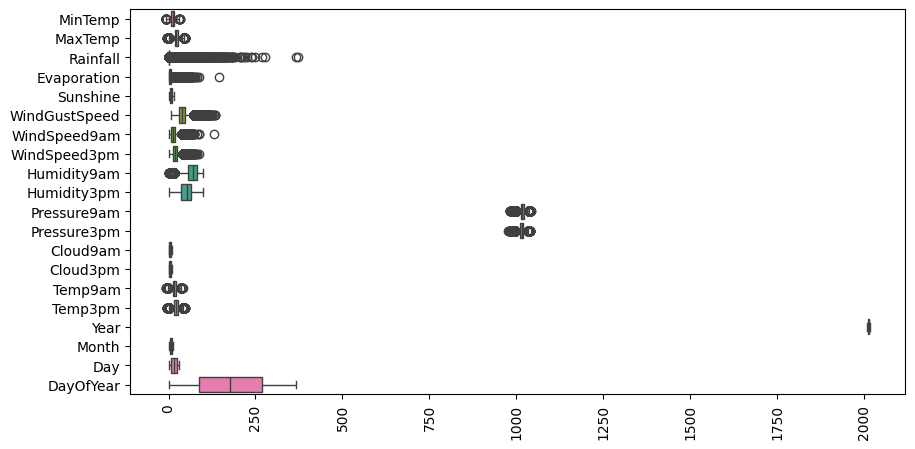

In [268]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, orient='h')
plt.xticks(rotation=90)
plt.show()

Sa ovog boxplot-a vidimo da su sve vrednosti potpuno različite i teško uporedive na istoj skali, jer su izražene u različitim jedinicama. Pressure9am i Pressure3pm su u hPa i kreću se oko 980 do 1040, Humidity9am i Humidity3pm su u procentima (0 do 100%), Rainfall je u mm (0 do 371), Sunshine u satima (0 do 14.5), WindGustSpeed, WindSpeed9am i WindSpeed3pm u km/h, temperature u °C, a Cloud9am i Cloud3pm u oktasima (0 do 9). Iz tog razloga ovaj boxplot i nije nešto koristan, pri daljoj analizi je neophodno skalirati podatke.

### 6.3 Opis obeležja

Analizirajmo osobine i raspodelu svakog obelžja pojedinačno, analiza će se razlikovati u zavisnosti od toga da li je promenljiva numerička ili kategorijska.

#### 6.3.1 Numerička obeležja

##### 6.3.1.1 MinTemp

MinTemp predstavlja minimalnu temperaturu tokom svakog dana merenja, izmerenu u Celzijusovim stepenima.

In [269]:
data['MinTemp'].describe()

count    143975.000000
mean         12.194034
std           6.398495
min          -8.500000
25%           7.600000
50%          12.000000
75%          16.900000
max          33.900000
Name: MinTemp, dtype: float64

S obzirom da su medijana i srednja vrednost približni možemo pretpostaviti da je raspodela normalna, ali bi to trebalo proveriti. Takođe, minimalne i maksimalne vrednosti ne mora da znači da su outlier-i (moguće je imati toliku minimalnu temperaturu, za maksimalnu temperaturu poznata je situacija u Adelaidu 29. januara 2009.)

Prema zvaničnim BOM rekordima, najniža ikada izmerena temperatura u Australiji je -23.0°C (Charlotte Pass, 1994), a najviša 50.7°C (Onslow, 2022). Naš minimum od -8.5°C je duboko unutar tog opsega, realna vrednost bez potrebe za dodatnom proverom.

Analizirajmo raspodelu vrednosti ove promenljive.

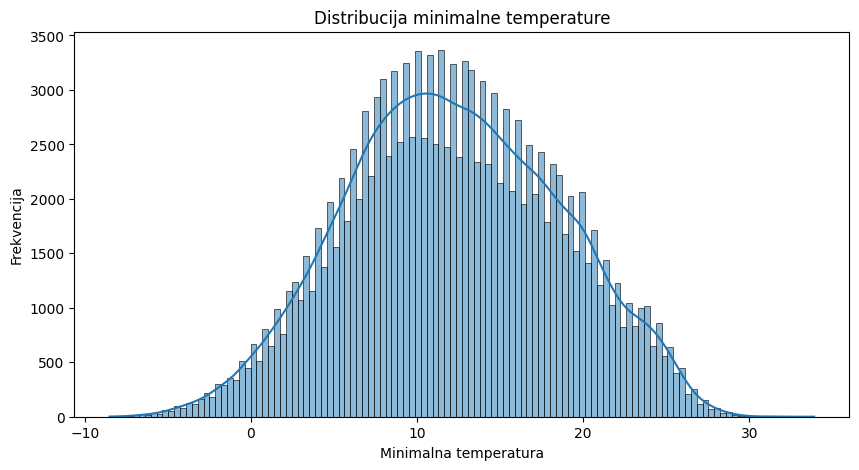

In [270]:
plt.figure(figsize=(10, 5))
sns.histplot(data['MinTemp'], kde=True)
plt.title('Distribucija minimalne temperature')
plt.xlabel('Minimalna temperatura')
plt.ylabel('Frekvencija')
plt.show()

Raspodela jeste približno normalna, ali ovakav grafik dobijamo zato što gledamo temperaturu na osnovu svih lokacija.

##### 6.3.1.2 MaxTemp
MaxTemp predstavlja maksimalnu temperaturu tokom svakog dana merenja, izmerenu u Celzijusovim stepenima.

In [272]:
data['MaxTemp'].describe()

count    144199.000000
mean         23.221348
std           7.119049
min          -4.800000
25%          17.900000
50%          22.600000
75%          28.200000
max          48.100000
Name: MaxTemp, dtype: float64

Mean (23.22°C) i medijana (22.6°C) su blizu, uz blagu desnu asimetriju što je i očekivano, jer češće imamo velike talase vrućine nego što hladni dani mogu da povuku prosek.

Minimum od -4.8°C i maksimum od 48.1°C ne moraju da budu greške, ali potrebno je to proveriti. Prema BOM rekordima, opseg -23.0°C do 50.7°C je granica onoga što je ikada izmereno u Australiji, naša oba ekstrema (-4.8°C i 48.1°C) su unutar tog opsega, dakle realne vrednosti.

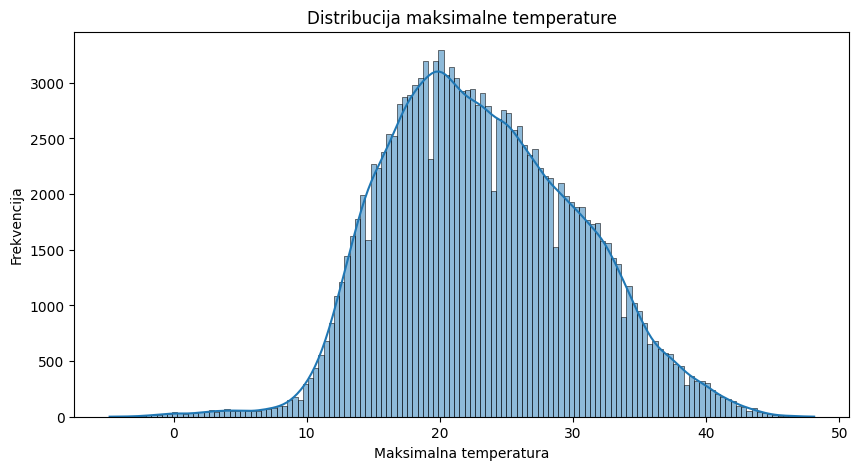

In [273]:
plt.figure(figsize=(10, 5))
sns.histplot(data['MaxTemp'], kde=True)
plt.title('Distribucija maksimalne temperature')
plt.xlabel('Maksimalna temperatura')
plt.ylabel('Frekvencija')
plt.show()

Grafik potvrđuje ono što smo već zaključili iz statistike. Raspodela ima jedan jasan vrh oko 23 stepena sa blagim produženim repom ka višim vrednostima, što odgovara ranije pomenutoj blagoj desnoj asimetriji. Kao i kod MinTemp, ovakav oblik dobijamo zato što posmatramo sve lokacije zajedno, pa se mešaju hladnije južne i toplije severne stanice Australije.

##### 6.3.1.3 Rainfall

Rainfall predstavlja količinu padavina tokom dana, izmerenu u milimetrima (mm).

Pomoću domenskog znanja možemo pretpostaviti da je vrednost ove promenljive tokom većine vremena jednaka nuli (u svim klimama, osim tropske, kiša ne pada toliko često), u situacijama kada je vrednost ove promenljive različita od nule, možemo pretpostaviti da će vrednost biti drastično veća. 

Nacrtajmo grafik raspodele i proverimo naše pretpostavke.

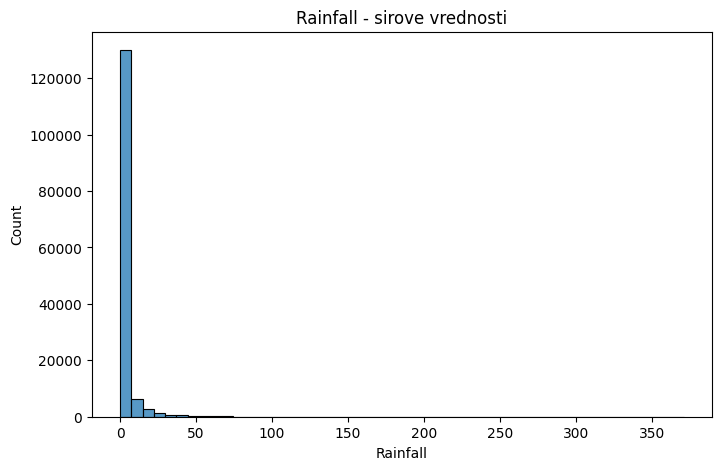

In [275]:
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x="Rainfall", bins=50)
plt.title("Rainfall - sirove vrednosti")
plt.show()

Sa ovog histograma možemo da uočimo da je u najvećem broju merenja bilo bez kiše, a tek u nekim možda ekstremnim situacijama (npr. oluja ili neki ciklon) smo imali ekstremne vrednosti.
Imamo jaku desnu asimteriju, tako da bi možda bilo bolje ovu promenljivu tretirati kao to da li je kiša uopšte padala tog dana ili ne (što već imamo kao RainToday) ili možda logaritmovati kada je kiša padala, ali više o načinu tretiranja ove promenljive u nastavku.

In [276]:
data['Rainfall'].describe()

count    142199.000000
mean          2.360918
std           8.478060
min           0.000000
25%           0.000000
50%           0.000000
75%           0.800000
max         371.000000
Name: Rainfall, dtype: float64

Ovde je razlika između mean (2.36mm) i medijane (0mm) ogromna, čak i 75% percentil je samo 0.8mm. Ovo potvrđuje ono što smo ranije zaključili, većina dana nema kišu, a mali broj ekstremnih dana vuče prosek naviše. Maksimum od 371mm je izmeren u CoffsHarbour, 7. novembra 2009., fizički potpuno moguće, ne greška u merenju.

Zvanični australijski rekord za dnevnu količinu padavina je 907mm (Crohamhurst, Kvinslend, 1893). Naš maksimum od 371mm je dakle ozbiljna, ekstremna oluja, ali daleko od tog rekorda, realna vrednost.

Pogledajmo i šta će se desiti ako na podatke primenimo logaritamsku tranformaciju.

In [ ]:
data['Log_Rainfall'] = np.log1p(data['Rainfall'])

plt.figure(figsize=(8, 5))
sns.histplot(data=data, x="Log_Rainfall", bins=50)
plt.title("Rainfall posle logaritamske transformacije")
plt.xlabel("log(1 + Rainfall)")
plt.show()

Logaritamska transformacija znatno smanjuje asimetriju raspodele. Skewness pada sa 9.84 kod sirovih vrednosti na 2.04 posle transformacije. Veliki deo mase i dalje ostaje na nuli, jer skoro 64 procenta dana nema nijednu kap kiše, ali rep koji predstavlja kišne dane je sada mnogo blaži i čitljiviji.

##### 6.3.1.4 Temp9am

Temp9am predstavlja temperaturu vazduha u 9 časova ujutru, izmerenu u Celzijusovim stepenima.

In [278]:
data['Temp9am'].describe()

count    142871.000000
mean         17.023203
std           6.481328
min          -7.200000
25%          12.300000
50%          16.700000
75%          21.600000
max          40.200000
Name: Temp9am, dtype: float64

Mean (16.99°C) i medijana (16.7°C) su skoro identični, praktično simetrična raspodela, slično kao MinTemp.

Minimum od -7.2°C je izmeren u MountGinini, istog dana (13. jul 2016.) kada smo videli i minimum za MaxTemp, što je odličan znak unutrašnje konzistentnosti podataka (isti hladni talas se odražava na više povezanih kolona istovremeno). Maksimum od 40.2°C je u PearceRAAF (vojna baza kraj Pertha, poznata po vrelim letnjim danima), 12. januara 2014.

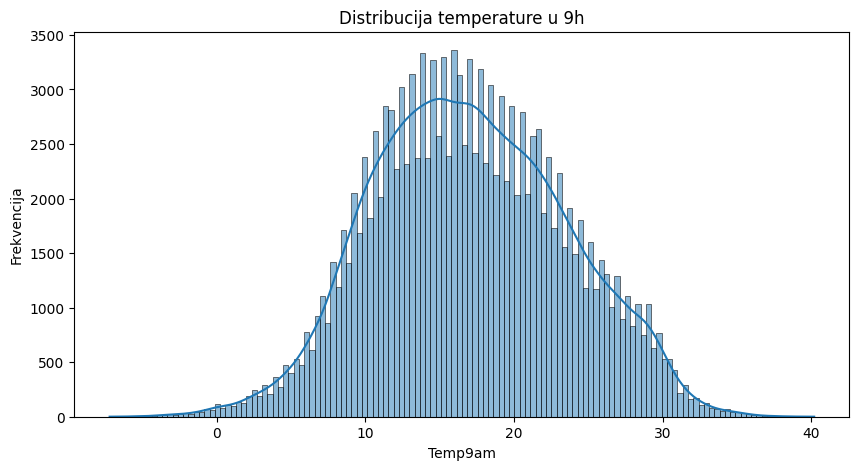

In [279]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Temp9am'], kde=True)
plt.title('Distribucija temperature u 9h')
plt.xlabel('Temp9am')
plt.ylabel('Frekvencija')
plt.show()

I ovde vidimo jedan jasan vrh, ovog puta gotovo simetričan oko 17 stepeni, u skladu sa gotovo identičnim mean i medijanom koje smo izračunali. Oblik je vrlo sličan MinTemp raspodeli, što je i logično jer se obe vrednosti mere u jutarnjim satima.

##### 6.3.1.5 Temp3pm

Temp3pm predstavlja temperaturu vazduha u 15 časova (3 popodne), izmerenu u Celzijusovim stepenima.

In [281]:
data['Temp3pm'].describe()

count    140943.000000
mean         21.724672
std           6.923495
min          -5.400000
25%          16.700000
50%          21.200000
75%          26.500000
max          46.700000
Name: Temp3pm, dtype: float64

Mean (21.68°C) i medijana (21.1°C) su blizu, blaga desna asimetrija, slično kao MaxTemp (što ima smisla, jer je Temp3pm skoro identičan MaxTemp, r = 0.99 iz korelacione matrice).

Minimum od -5.4°C je ponovo MountGinini, 13. jul 2016. isti hladan dan se pojavljuje kao ekstrem u sve četiri temperaturske kolone, što je još jedna potvrda da su podaci međusobno konzistentni. Maksimum od 46.7°C je u Moree (unutrašnjost NSW, poznata po ekstremnim letnjim vrućinama), 12. februara 2017.

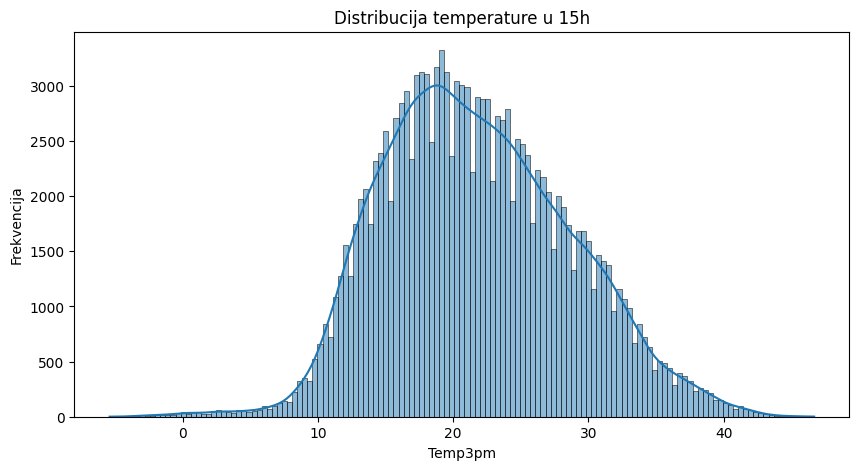

In [282]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Temp3pm'], kde=True)
plt.title('Distribucija temperature u 15h')
plt.xlabel('Temp3pm')
plt.ylabel('Frekvencija')
plt.show()

Raspodela ponovo ima jedan vrh, sada oko 22 stepena, sa blagim produžetkom ka toplijoj strani, što se poklapa sa blagom desnom asimetrijom koju smo videli kod MaxTemp. Ovo je i očekivano jer smo ranije utvrdili da su Temp3pm i MaxTemp gotovo identične kolone.

##### 6.3.1.6 Evaporation

Evaporation predstavlja količinu isparene vode tokom dana (merenu isparnim panjom), izraženu u milimetrima (mm).

In [284]:
data['Evaporation'].describe()

count    82670.000000
mean         5.468232
std          4.193704
min          0.000000
25%          2.600000
50%          4.800000
75%          7.400000
max        145.000000
Name: Evaporation, dtype: float64

Mean (5.47mm) je znatno veći od medijane (4.8mm), desna asimetrija, iako ne toliko ekstremna kao kod Rainfall.

Na osnovu zvaničnih podataka vezanih za Evaporation od strane Biroa za meteorologiju (BOM), najveća moguća vrednost je otprilike 25mm za Evaporation (nevezano za lokaciju). Vrednosti veće od 30mm bi trebalo uzeti sa posebnom rezervom jer su one najverovatnije greška.

In [285]:
len(data[data['Evaporation'] > 30])

220

220 merenja prelazi granicu od 30 milimetara koju smo naveli kao gornju realnu granicu, što je manje od 0.3 procenta celog skupa. Ove vrednosti ćemo kasnije tretirati kao potencijalne anomalije umesto da ih odmah brišemo, jer nekoliko izuzetno toplih i suvih dana zaista može proizvesti toliko isparavanje.

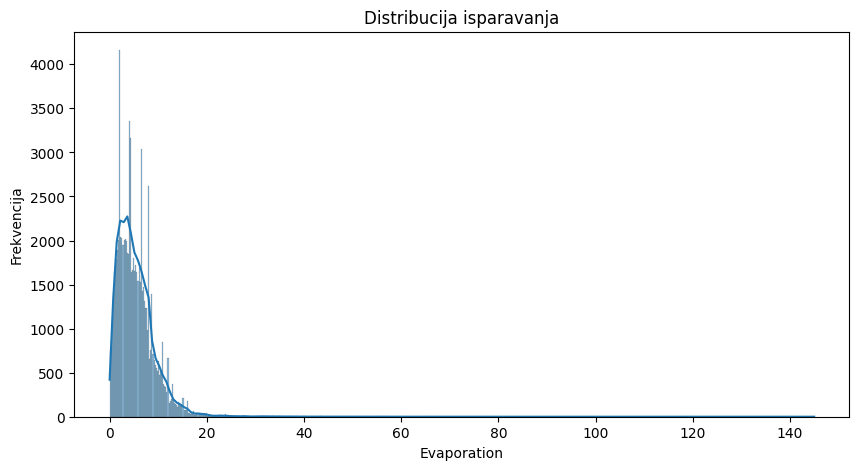

In [286]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Evaporation'], kde=True)
plt.title('Distribucija isparavanja')
plt.xlabel('Evaporation')
plt.ylabel('Frekvencija')
plt.show()

Grafik jasno pokazuje izraženu desnu asimetriju koju smo očekivali iz razlike mean i medijane, sa najvećim brojem dana koncentrisanim ispod 10 milimetara i dugim repom ka retkim ekstremno toplim danima, uključujući i onih 220 merenja iznad 30 milimetara.

##### 6.3.1.7 Sunshine

Sunshine predstavlja broj sati direktne sunčeve svetlosti tokom dana, izmeren heliografom.

In [288]:
data['Sunshine'].describe()

count    75625.000000
mean         7.611178
std          3.785483
min          0.000000
25%          4.800000
50%          8.400000
75%         10.600000
max         14.500000
Name: Sunshine, dtype: float64

Mean (7.61h) i medijana (8.4h) su blizu, skewness približno -0.5, blaga leva asimetrija (malo više oblačnih ili kratkih dana nego ekstremno sunčanih).

I minimum i maksimum su potpuno fizički logični, minimum od 0h (potpuno oblačan dan, Cobar, 7. januar 2009.) i maksimum od 14.5h (Mildura, 28. decembar 2015.). 14.5h je blizu teorijskog maksimuma broja sati dnevne svetlosti u Australiji tokom leta (oko 14 do 15h), što znači da je taj dan bio potpuno vedar, bez oblaka, od izlaska do zalaska sunca.

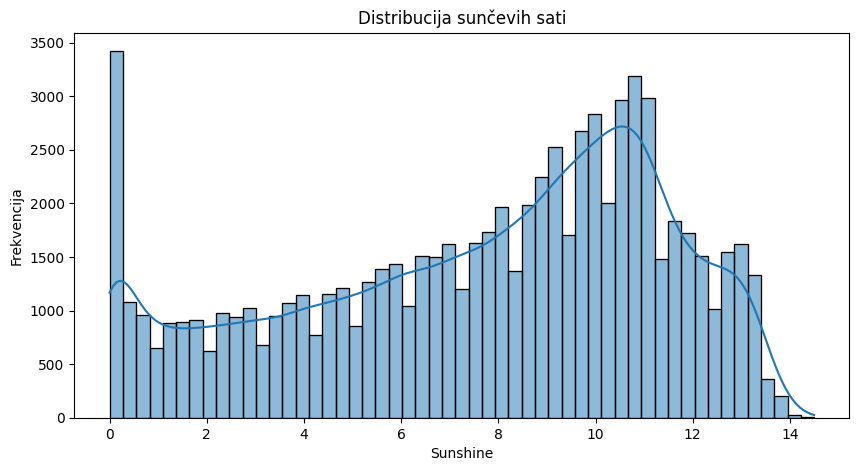

In [289]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Sunshine'], kde=True)
plt.title('Distribucija sunčevih sati')
plt.xlabel('Sunshine')
plt.ylabel('Frekvencija')
plt.show()

Raspodela pokazuje blagu levu asimetriju koju smo već pomenuli, sa dosta dana bliže maksimumu od četrnaest i po sati i nešto dužim repom ka potpuno oblačnim danima. Ovakav oblik ima smisla jer je u većem delu Australije sunčano vreme uobičajenije od potpuno oblačnog.

##### 6.3.1.8 Numeričko obeležje WindGustSpeed

WindGustSpeed predstavlja brzinu najjačeg udara vetra tokom dana, izraženu u km/h.

In [291]:
data['WindGustSpeed'].describe()

count    135192.000000
mean         40.035860
std          13.606884
min           6.000000
25%          31.000000
50%          39.000000
75%          48.000000
max         135.000000
Name: WindGustSpeed, dtype: float64

Mean (40.04 km/h) i medijana (39 km/h) su blizu, skewness približno 0.87, umerena desna asimetrija (retki, ali jako izraženi udari vetra vuku prosek naviše).

Minimum od 6 km/h (Launceston, 11. jul 2013.) je sasvim miran dan bez vetra što je fizički potpuno normalno. Maksimum od 135 km/h (NorahHead, 21. april 2015.) je ekstreman, ali je vrlo moguć jer je NorahHead izložen obalski rt u NSW, poznat po jakim olujama, a 135 km/h odgovara sili jake oluje ili blage tropske ciklonske aktivnosti.

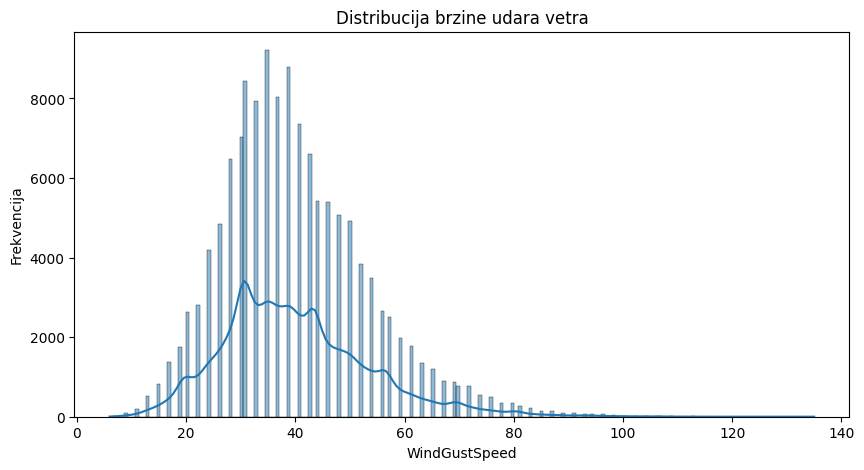

In [292]:
plt.figure(figsize=(10, 5))
sns.histplot(data['WindGustSpeed'], kde=True)
plt.title('Distribucija brzine udara vetra')
plt.xlabel('WindGustSpeed')
plt.ylabel('Frekvencija')
plt.show()

Grafik potvrđuje umerenu desnu asimetriju iz statistike, sa najvećim brojem dana oko 40 kilometara na sat i repom koji se proteže ka retkim jakim olujnim danima poput onog u NorahHead.

##### 6.3.1.9 WindSpeed9am

WindSpeed9am predstavlja brzinu vetra u 9 časova ujutru, izraženu u km/h.

In [294]:
data['WindSpeed9am'].describe()

count    143693.000000
mean         14.043426
std           8.915375
min           0.000000
25%           7.000000
50%          13.000000
75%          19.000000
max         130.000000
Name: WindSpeed9am, dtype: float64

Mean (14.04 km/h) i medijana (13 km/h) su blizu, skewness približno 0.78, umerena desna asimetrija, slično kao WindGustSpeed (očekivano).

Minimum od 0 km/h (Albury, 27. decembar 2008.) je potpuno miran jutarnji vazduh. Maksimum od 130 km/h (Newcastle, 18. januar 2017.) je izuzetno visok za brzinu vetra. Taj dan je MaxTemp u Newcastle-u bio čak 41°C što dodatno potkrepljuje da je ovo bio realan ekstreman dan, a ne greška u merenju.

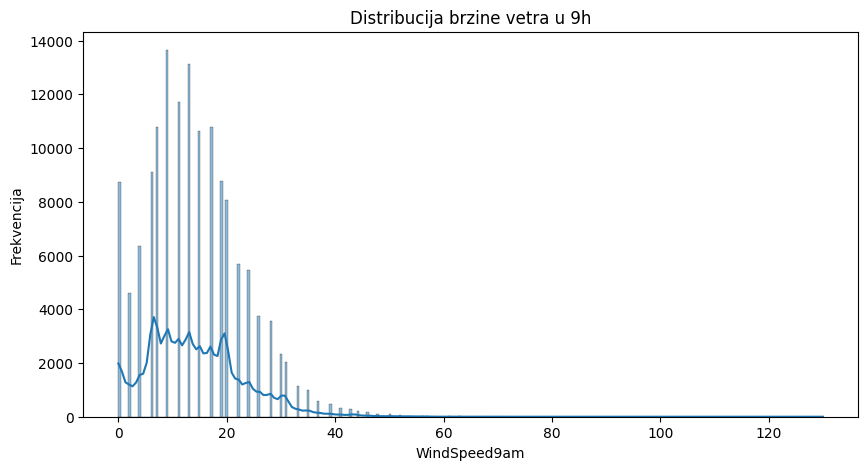

In [295]:
plt.figure(figsize=(10, 5))
sns.histplot(data['WindSpeed9am'], kde=True)
plt.title('Distribucija brzine vetra u 9h')
plt.xlabel('WindSpeed9am')
plt.ylabel('Frekvencija')
plt.show()

Oblik raspodele je vrlo sličan kao kod WindGustSpeed, samo pomeren ka nižim vrednostima, što je logično jer je jutarnji vetar u proseku slabiji od najjačeg udara tokom dana.

##### 6.3.1.10 WindSpeed3pm

WindSpeed3pm predstavlja brzinu vetra u 15 časova, izraženu u km/h.

In [297]:
data['WindSpeed3pm'].describe()

count    142398.000000
mean         18.662657
std           8.809800
min           0.000000
25%          13.000000
50%          19.000000
75%          24.000000
max          87.000000
Name: WindSpeed3pm, dtype: float64

Mean (18.66 km/h) i medijana (19 km/h) su skoro identični, skewness približno 0.63, blaga desna asimetrija, nešto blaža nego kod WindSpeed9am, što ima smisla jer popodnevni vetar obično duva ravnomernije, sa manje ekstremnih tišina, nego jutarnji.

Minimum od 0 km/h (Albury, 14. februar 2009.) je opet miran dan. Maksimum od 87 km/h (GoldCoast, 20. maj 2009.) je znatno umereniji u odnosu na WindGustSpeed (135) i WindSpeed9am (130).

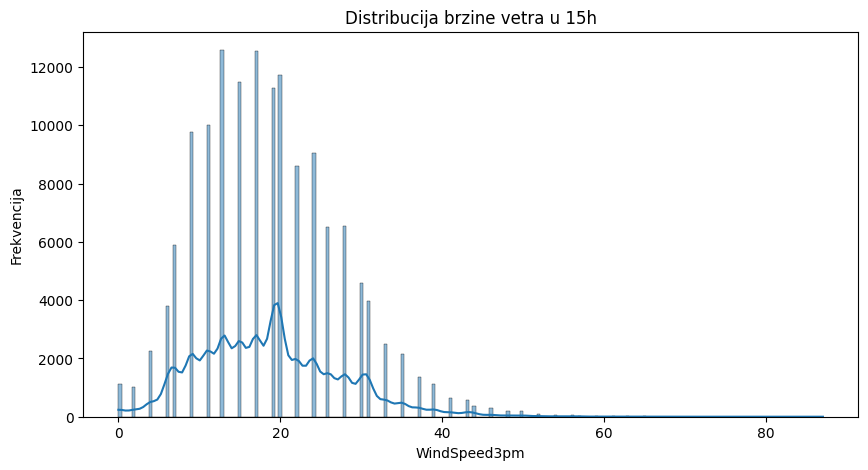

In [298]:
plt.figure(figsize=(10, 5))
sns.histplot(data['WindSpeed3pm'], kde=True)
plt.title('Distribucija brzine vetra u 15h')
plt.xlabel('WindSpeed3pm')
plt.ylabel('Frekvencija')
plt.show()

Raspodela je blago pomerena udesno u odnosu na WindSpeed9am i nešto manje asimetrična, u skladu sa ranije pomenutim ravnomernijim popodnevnim vetrom.

##### 6.3.1.11 Humidity9am

Humidity9am predstavlja relativnu vlažnost vazduha u 9 časova ujutru, izraženu u procentima (%).

In [300]:
data['Humidity9am'].describe()

count    142806.000000
mean         68.880831
std          19.029164
min           0.000000
25%          57.000000
50%          70.000000
75%          83.000000
max         100.000000
Name: Humidity9am, dtype: float64

Mean (68.88%) i medijana (70%) su blizu, skewness približno -0.48, blaga leva asimetrija (vlažnost je ograničena odozgo sa 100%, pa rep ka niskim vrednostima može da bude duži).

Minimum od 0% (Woomera, 20. oktobar 2013.) je ekstremno suv vazduh, ali prihvatljivo za pustinjsku lokaciju. Maksimum od 100% (Albury, 31. jul 2010., sred zime) predstavlja potpuno zasićen vazduh (magla ili kiša), takođe potpuno normalno. Relativna vlažnost je po definiciji ograničena na opseg 0 do 100%, pa ovde nema potrebe za poređenjem sa spoljašnjim rekordima, bilo koja vrednost unutar tog opsega je validna.

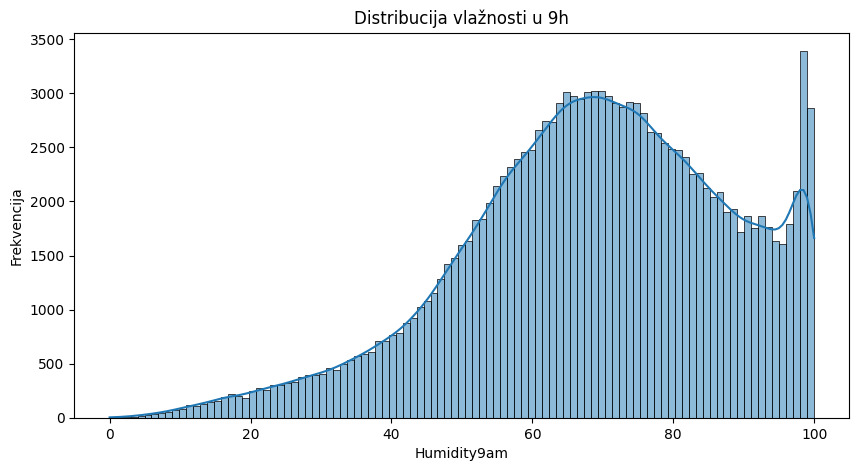

In [301]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Humidity9am'], kde=True)
plt.title('Distribucija vlažnosti u 9h')
plt.xlabel('Humidity9am')
plt.ylabel('Frekvencija')
plt.show()

Grafik pokazuje blagu levu asimetriju koju smo očekivali, sa najviše dana u opsegu od 60 do 80 procenata i kraćim repom ka veoma suvim jutrima.

##### 6.3.1.12 Humidity3pm

Humidity3pm predstavlja relativnu vlažnost vazduha u 15 časova, izraženu u procentima (%).

In [303]:
data['Humidity3pm'].describe()

count    140953.000000
mean         51.539116
std          20.795902
min           0.000000
25%          37.000000
50%          52.000000
75%          66.000000
max         100.000000
Name: Humidity3pm, dtype: float64

Mean (51.54%) i medijana (52%) su skoro identični, skewness približno 0.03, praktično simetrična raspodela.

Odgovor na pitanje sa kraja prošlog dela je da, Humidity9am (mean 68.88%) je u proseku znatno veći od Humidity3pm (mean 51.54%), razlika od skoro 17 procentnih poena. Ovo je meteorološki potpuno očekivano, ujutru je vazduh hladniji i bliži tački rošenja, pa je relativna vlažnost veća, dok popodne, kad temperatura poraste, ista količina vodene pare u vazduhu odgovara nižoj relativnoj vlažnosti.

Minimum od 0% je opet u Woomera, istog dana (20. oktobar 2013.) kada je izmeren i minimum za Humidity9am, odličan znak konzistentnosti, taj dan je bio ekstremno suv i ujutru i popodne. Maksimum od 100% je u Albury, 26. februar 2012. Kao i kod Humidity9am, opseg 0 do 100% je definicioni, pa nema potrebe za poređenjem sa spoljašnjim rekordima.

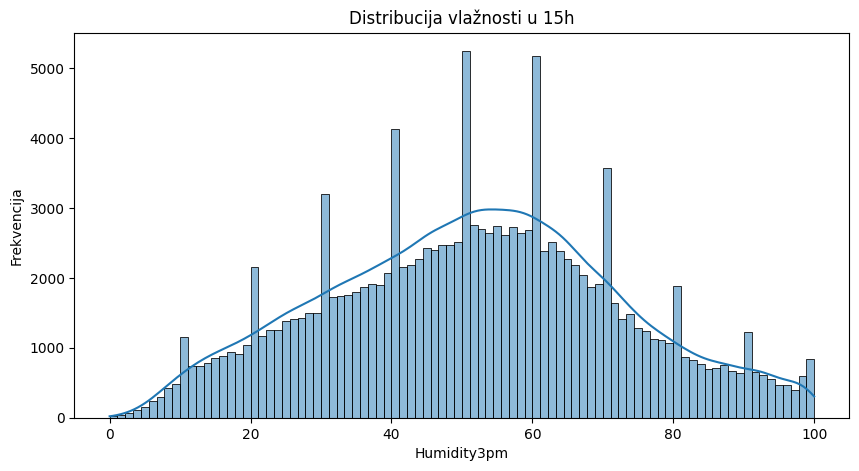

In [304]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Humidity3pm'], kde=True)
plt.title('Distribucija vlažnosti u 15h')
plt.xlabel('Humidity3pm')
plt.ylabel('Frekvencija')
plt.show()

Za razliku od jutarnje vlažnosti, ovde je raspodela gotovo savršeno simetrična oko pedeset procenata, u skladu sa skoro nultom asimetrijom koju smo izračunali.

##### 6.3.1.13 Pressure9am

Pressure9am predstavlja atmosferski pritisak u 9 časova ujutru, sveden na nivo mora, izražen u hPa.

In [306]:
data['Pressure9am'].describe()

count    130385.000000
mean       1017.650756
std           7.106132
min         980.500000
25%        1012.900000
50%        1017.600000
75%        1022.400000
max        1041.000000
Name: Pressure9am, dtype: float64

Mean (1017.65 hPa) i medijana (1017.6 hPa) su praktično identični, skewness približno -0.1, gotovo savršeno simetrična raspodela, što je uobičajeno za atmosferski pritisak.

Minimum od 980.5 hPa (NorfolkIsland, 11. jul 2009.) odgovara veoma dubokom ciklonu ili oluji niskog pritiska, fizički potpuno moguće, čak i za relativno blag ekstrem (duboki cikloni idu i znatno ispod 950 hPa, zvanični rekord za najniži pritisak u australijskom regionu je oko 900 hPa, Ciklon Inigo 2003). Maksimum od 1041 hPa (Witchcliffe, 9. septembar 2011.) odgovara jakom anticiklonu, visokom pritisku, tipičnom za mirno, vedro vreme, takođe potpuno realno (tipičan gornji opseg u Australiji je do oko 1040 do 1050 hPa).

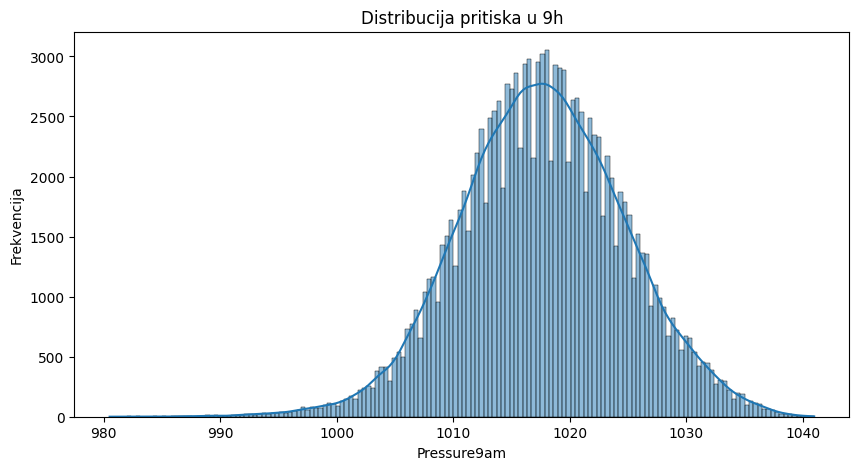

In [307]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Pressure9am'], kde=True)
plt.title('Distribucija pritiska u 9h')
plt.xlabel('Pressure9am')
plt.ylabel('Frekvencija')
plt.show()

Grafik potvrđuje gotovo savršeno simetričnu, zvonastu raspodelu oko 1017 hektopaskala, tipičnu za atmosferski pritisak kada se posmatra na velikom broju merenja.

##### 6.3.1.14 Pressure3pm

Pressure3pm predstavlja atmosferski pritisak u 15 časova, sveden na nivo mora, izražen u hPa.

In [309]:
data['Pressure3pm'].describe()

count    130422.000000
mean       1015.257585
std           7.034928
min         977.100000
25%        1010.400000
50%        1015.200000
75%        1020.000000
max        1039.600000
Name: Pressure3pm, dtype: float64

Mean (1015.26 hPa) i medijana (1015.2 hPa) su praktično identični, skewness približno -0.05, opet gotovo savršeno simetrično, u skladu sa Pressure9am.

Minimum od 977.1 hPa (Hobart, 12. jul 2016.) je izuzetno nizak pritisak. Tasmanija je krajem juna i početkom jula 2016. pogođena ozbiljnim nevremenom i poplavama, pa je ovo u skladu sa poznatim vremenskim događajem, ne greškom, i i dalje daleko od rekordnih oko 900 hPa (ciklonski pritisak). Maksimum od 1039.6 hPa (Launceston, 22. jun 2010.) je jak zimski anticiklon.

Prosek Pressure3pm (1015.26) je nešto niži od Pressure9am (1017.65), blaga, ali dosledna razlika, u skladu sa tim da pritisak ima dnevni ciklus (obično malo opada tokom popodneva usled zagrevanja vazduha).

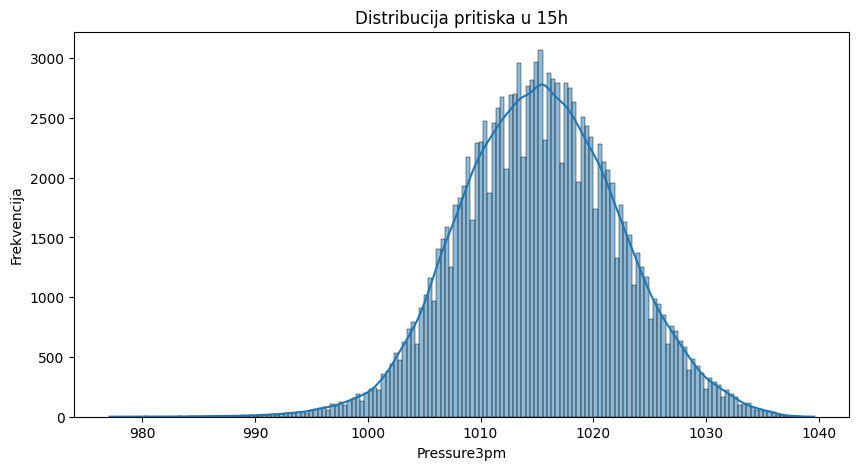

In [310]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Pressure3pm'], kde=True)
plt.title('Distribucija pritiska u 15h')
plt.xlabel('Pressure3pm')
plt.ylabel('Frekvencija')
plt.show()

Oblik je praktično identičan kao kod Pressure9am, samo blago pomeren ka nižim vrednostima pritiska, u skladu sa razlikom prosečnih vrednosti koju smo već primetili.

##### 6.3.1.15 Cloud9am

Cloud9am predstavlja oblačnost neba u 9 časova ujutru, izraženu u oktasima (skala 0-9, gde 0 znači vedro nebo, a 9 potpuno naoblačeno).

In [312]:
data['Cloud9am'].describe()

count    89572.000000
mean         4.447461
std          2.887159
min          0.000000
25%          1.000000
50%          5.000000
75%          7.000000
max          9.000000
Name: Cloud9am, dtype: float64

Ovo je, zajedno sa Cloud3pm, jedina numerička kolona koja je zapravo diskretna ordinalna skala (celi brojevi od 0 do 9), a ne kontinualna veličina, pa describe() treba tumačiti s tom napomenom, mean (4.45) i skewness ovde nisu toliko informativni kao kod pravih kontinualnih veličina.

Minimum od 0 (potpuno vedro nebo, Albury, 16. decembar 2008.) i maksimum od 9 (potpuno oblačno, Sydney, 23. septembar 2009.) su prosto krajnje vrednosti skale, ne outlieri, očekivano je da se pojavljuju često, jer je nebo ili sasvim vedro ili sasvim oblačno prilično čest slučaj. Oktas skala je po definiciji ograničena na opseg od 0 do 9, pa ovde takođe nema potrebe za poređenjem sa spoljašnjim rekordima, jedino bi vrednost van tog opsega (na primer 10 ili -1) bila znak greške.

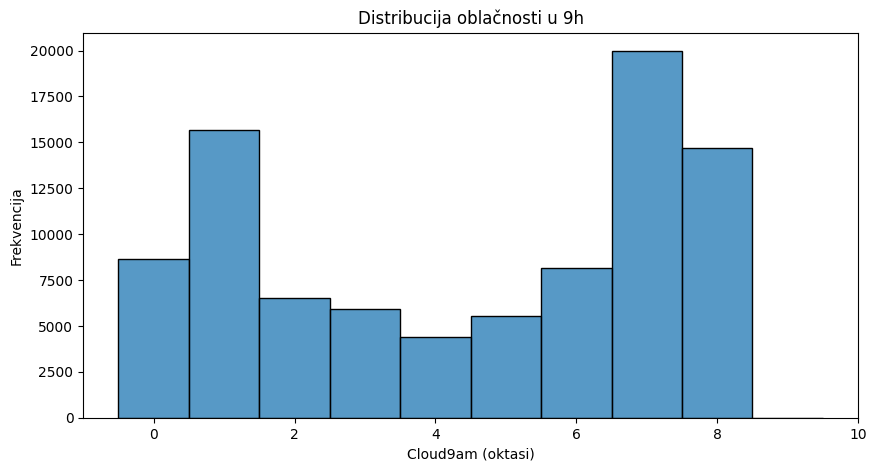

In [313]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Cloud9am'], bins=10, discrete=True)
plt.title('Distribucija oblačnosti u 9h')
plt.xlabel('Cloud9am (oktasi)')
plt.ylabel('Frekvencija')
plt.show()

Kako smo i napomenuli, ovo nije prava kontinualna raspodela nego diskretna skala od nula do devet, pa grafik pokazuje dva izražena vrha na krajevima, potpuno vedro i potpuno oblačno nebo, dok su srednje vrednosti nešto ređe zastupljene.

##### 6.3.1.16 Cloud3pm

Cloud3pm predstavlja oblačnost neba u 15 časova, izraženu u oktasima (skala 0-9).

In [315]:
data['Cloud3pm'].describe()

count    86102.000000
mean         4.509930
std          2.720357
min          0.000000
25%          2.000000
50%          5.000000
75%          7.000000
max          9.000000
Name: Cloud3pm, dtype: float64

Mean (4.51) i medijana (5) su vrlo blizu vrednostima kod Cloud9am (4.45 i 5), u proseku slična oblačnost ujutru i popodne, za razliku od temperature ili vlažnosti gde je razlika između 9h i 15h bila izraženija.

Minimum od 0 (Cobar, 16. januar 2009.) i maksimum od 9 (Woomera, 2. novembar 2012.) su opet samo krajnje vrednosti skale od 0 do 9, ne greške.

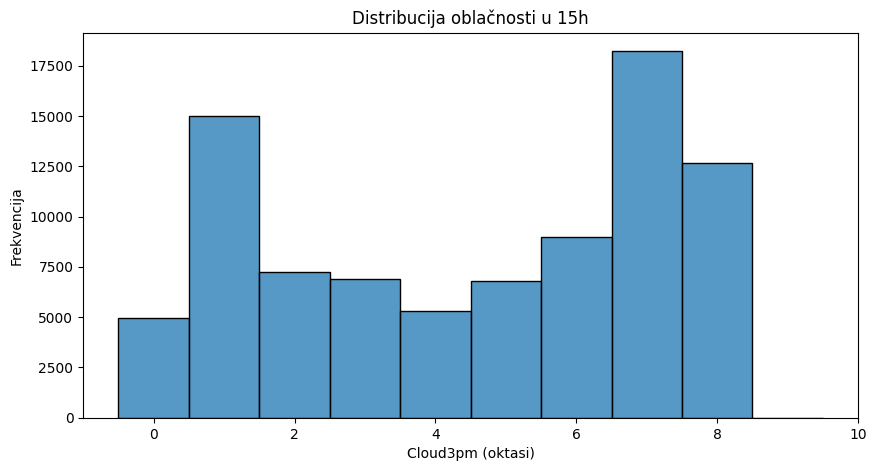

In [316]:
plt.figure(figsize=(10, 5))
sns.histplot(data['Cloud3pm'], bins=10, discrete=True)
plt.title('Distribucija oblačnosti u 15h')
plt.xlabel('Cloud3pm (oktasi)')
plt.ylabel('Frekvencija')
plt.show()

Oblik je vrlo sličan kao kod Cloud9am, sa dva vrha na krajnjim vrednostima skale, što potvrđuje da su jutarnja i popodnevna oblačnost slično raspoređene na oba doba dana.

##### 6.3.1.17 Numerička obeležja u odnosu na RainTomorrow

Do sada smo svaku numeričku promenljivu posmatrali samo pojedinačno, bez poređenja sa ciljnom promenljivom. Pogledajmo sada kako se raspodela svake numeričke promenljive razlikuje u zavisnosti od toga da li sledećeg dana pada kiša.

In [1]:
numericke_promenljive = ['MinTemp', 'MaxTemp', 'Rainfall', 'Temp9am', 'Temp3pm', 'Evaporation',
                          'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
                          'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                          'Cloud9am', 'Cloud3pm']

podaci_sa_ciljem = data.dropna(subset=['RainTomorrow'])

cols = 4
rows = -(-len(numericke_promenljive) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes = axes.flatten()

for ax, kolona in zip(axes, numericke_promenljive):
    sns.boxplot(data=podaci_sa_ciljem, x='RainTomorrow', y=kolona, hue='RainTomorrow',
                palette='Set1', legend=False, ax=ax)
    ax.set_title(kolona, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

for ax in axes[len(numericke_promenljive):]:
    ax.axis('off')

fig.suptitle('Numerička obeležja u odnosu na RainTomorrow', fontsize=14)
plt.tight_layout()
plt.show()

NameError: name 'data' is not defined

Najupadljiviji obrazac vidimo kod promenljivih vezanih za vlažnost vazduha i oblačnost. Humidity3pm pokazuje najjasnije razdvajanje od svih numeričkih promenljivih. Kada sutra neće padati kiša tipična vrednost je oko 47 procenata, a kada hoće tipična vrednost skače na oko 70 procenata, pa se kutije na grafiku jedva dodiruju. Humidity9am prati isti obrazac, samo nešto slabije izražen. Sunshine pokazuje skoro ogledalsku sliku ovoga, dani posle kojih sledi kiša imaju primetno manje sunčanih sati u proseku. Cloud9am i Cloud3pm prate istu logiku, veća naoblačenost tog dana prirodno prethodi kiši sledećeg dana. Pressure9am i Pressure3pm su takođe primetno niži pred kišne dane, što se poklapa sa osnovnim meteorološkim znanjem, sistemi niskog pritiska donose kišu. MaxTemp i Temp3pm pokazuju umereno, ali jasno vidljivo razdvajanje, dok WindGustSpeed i obe kolone brzine vetra pokazuju blaže, ali i dalje primetno više vrednosti pred kišne dane. Rainfall sama po sebi već pokazuje veće vrednosti pred kišno sutra, mada je to teško videti golim okom na ovom grafiku jer nekoliko ekstremnih dana potpuno razvlači skalu, obe grupe uglavnom imaju vrednosti blizu nule.

MinTemp i Temp9am jedva pokazuju ikakvu vidljivu razliku između dve grupe. Evaporation takođe pokazuje samo blagu razliku. Gledajući samo ove grafike moglo bi se zaključiti da jutarnja temperatura i minimalna dnevna temperatura nose skoro nikakvu informaciju o tome da li će sutra padati kiša.

Taj zaključak bio bi pogrešan ili bar nepotpun, i tu pomaže pogled koji uključuje još jednu promenljivu. Kada MinTemp podelimo ne samo po RainTomorrow nego i po mesecu, pojavljuje se sasvim drugačija slika. U svakom pojedinačnom mesecu medijana MinTemp na dan posle kog pada kiša je viša nego na dan koji ostaje suv, a ta razlika ume da bude tri stepena ili više u letnjim mesecima kao što su decembar, januar i februar, dok pada na manje od jednog stepena u septembru i oktobru. Razlog zašto ovaj prvi grafik to sakriva je taj što se meseci međusobno ogromno razlikuju po tipičnoj temperaturi, pa topao zimski dan i hladan letnji dan mogu da završe sa sličnom sirovom vrednošću MinTemp iako za rizik od kiše znače potpuno suprotne stvari. Kada se sezona uzme u obzir, ista promenljiva ponovo postaje informativna.

In [ ]:
mesecna_analiza = data.dropna(subset=['RainTomorrow']).copy()
mesecna_analiza['Month'] = pd.to_datetime(mesecna_analiza['Date']).dt.month

medijane_po_mesecu = mesecna_analiza.groupby(['Month', 'RainTomorrow'])['MinTemp'].median().unstack()
medijane_po_mesecu['Razlika'] = medijane_po_mesecu['Yes'] - medijane_po_mesecu['No']
medijane_po_mesecu.round(2)

Opšta pouka iz ovog dela je da promenljiva koja pokazuje slabo razdvajanje sama za sebe ne znači automatski da je beskorisna za model. Možda samo treba da se posmatra zajedno sa nekom drugom promenljivom, ovde mesec odnosno sezona, da bi njena veza sa kišom postala vidljiva.

#### 6.3.2 Kategorijska obeležja

In [318]:
data.select_dtypes(include=['object', 'category'])

,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
96320,Adelaide,NW,SW,W,Yes,No
96321,Adelaide,SW,SSW,SW,No,No
96322,Adelaide,W,NNE,SW,No,No
96323,Adelaide,NNE,NNE,NE,No,No
96324,Adelaide,N,NNE,NE,No,NaN
...,...,...,...,...,...,...
108566,Woomera,ENE,ESE,ESE,No,No
108567,Woomera,NNE,ENE,NNW,No,No
108568,Woomera,NNW,N,NW,No,No
108569,Woomera,W,WSW,WSW,No,No


Pored kolone Date koja je već pretvorena u pravi datumski tip, imamo šest kolona sa tekstualnim vrednostima, Location, WindGustDir, WindDir9am, WindDir3pm, RainToday i RainTomorrow, koje ćemo sada analizirati pojedinačno.

##### 6.3.2.1 Date

Kategorijsko obeležje Date predstavlja datum zabeleženog merenja različitih faktora uticajnosti na kišu na određenoj lokaciji. Više o samim jedinstvenim vrednostima ovog obeležja, njegove uticajnosti na našu ciljanu promenljivu RainTomorrow ćemo obraditi u nastavku.

In [319]:
data['Date'].value_counts()

Date
2017-06-17    49
2017-06-18    49
2017-06-19    49
2017-06-20    49
2017-06-21    49
              ..
2007-11-15     1
2007-11-16     1
2007-11-17     1
2007-11-18     1
2007-11-19     1
Name: count, Length: 3436, dtype: int64

In [320]:
counts = data['Date'].value_counts()
maxDates = counts[counts == 49].index
result = data[data['Date'].isin(maxDates)]
print(f'Najraniji datum kada je pocelo merenje na nekoj lokaciji: ', data['Date'].min())
print(f'Najraniji datum od kada imamo podatke na svim lokacijama: ', result['Date'].min())
print(f'Najkasniji datum kada se zavrsilo merenje na nekoj lokaciji: ', result['Date'].max())
print(f'Najkasniji datum kada se zavrsilo merenje na svim lokacijama: ', data['Date'].max())



Najraniji datum kada je pocelo merenje na nekoj lokaciji:  2007-11-01 00:00:00
Najraniji datum od kada imamo podatke na svim lokacijama:  2013-03-01 00:00:00
Najkasniji datum kada se zavrsilo merenje na nekoj lokaciji:  2017-06-24 00:00:00
Najkasniji datum kada se zavrsilo merenje na svim lokacijama:  2017-06-25 00:00:00


Ono što je zanimljivo jeste da za različite datume imamo različite jedinstvene vrednosti. To je rezultat toga što nam od lokacije do lokacije zavisi kada je počelo merenje. Možemo primetiti da prve rezultate imamo od 1.11.2007. a da tek od 1.3.2013. imamo svakodnevne podatke za sve naše lokacije. Kraj se relativno podudara, razlika je samo jedan dan. Sam po sebi datum i nema nešto preterano mnogo značajnosti, međutim, može da nam bude dobra podloga za pretvaranje u godinu i mesec npr. gde bismo znali koje je godišnje doba u tom periodu i šta bismo mogli da očekujemo. Takva promenljiva bi više uticala na naš model nego sam datum.
Takođe, valjalo bi proveriti da li postoji neki dani gde bismo imali preskakanja(nemamo podatke za određeni dan) za određenu lokaciju, ako je merenje već počelo.

In [321]:
def pronadji_nedostajuce_dane(df, location_col="Location", date_col="Date"):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col]).dt.normalize()
    df = df.drop_duplicates(subset=[location_col, date_col])

    records = []
    for location, group in df.groupby(location_col, sort=True):
        dates = group[date_col].sort_values()
        start, end = dates.min(), dates.max()

        full_range = pd.date_range(start, end, freq="D")
        present = pd.Index(dates.unique())
        missing = full_range.difference(present)

        for missing_date in missing:
            records.append({
                "Location": location,
                "MissingDate": missing_date,
                "PeriodStart": start,
                "PeriodEnd": end,
            })

    result = pd.DataFrame(records)
    if not result.empty:
        result = result.sort_values(["Location", "MissingDate"]).reset_index(drop=True)

    return result



nedostajuci_dani = pronadji_nedostajuce_dane(data)
nedostajuci_dani

,Location,MissingDate,PeriodStart,PeriodEnd
0,Adelaide,2011-04-01,2008-07-01,2017-06-25
1,Adelaide,2011-04-02,2008-07-01,2017-06-25
2,Adelaide,2011-04-03,2008-07-01,2017-06-25
3,Adelaide,2011-04-04,2008-07-01,2017-06-25
4,Adelaide,2011-04-05,2008-07-01,2017-06-25
...,...,...,...,...
4107,Woomera,2013-02-24,2009-01-01,2017-06-25
4108,Woomera,2013-02-25,2009-01-01,2017-06-25
4109,Woomera,2013-02-26,2009-01-01,2017-06-25
4110,Woomera,2013-02-27,2009-01-01,2017-06-25


Vidimo da imamo 4112 redova sa nedostajućim vrednostima za neki dan otkako je započelo njihovo merenje. Sada ćemo napraviti kratak rezime po brojkama za koju lokaciju koliko dana fali.

In [322]:
def rezime_nedostajucih_dana(missing_df):
    if missing_df.empty:
        return pd.DataFrame(columns=["Location", "PeriodStart", "PeriodEnd", "BrojFalecihDana", "FaleciDani"])

    summary = (
        missing_df
        .groupby("Location", as_index=False)
        .agg(
            PeriodStart=("PeriodStart", "first"),
            PeriodEnd=("PeriodEnd", "first"),
            BrojFalecihDana=("MissingDate", "count"),
            FaleciDani=("MissingDate", lambda x: sorted(x.dt.strftime("%Y-%m-%d").tolist())),
        )
        .sort_values("BrojFalecihDana", ascending=False)
    )
    return summary

rezime = rezime_nedostajucih_dana(nedostajuci_dani)
rezime

,Location,PeriodStart,PeriodEnd,BrojFalecihDana,FaleciDani
34,SalmonGums,2009-01-01,2017-06-25,97,"[2010-05-24, 2010-05-25, 2010-05-26, 2010-05-2..."
24,NorahHead,2009-01-01,2017-06-25,94,"[2011-04-01, 2011-04-02, 2011-04-03, 2011-04-0..."
40,Walpole,2009-01-01,2017-06-25,92,"[2011-04-01, 2011-04-02, 2011-04-03, 2011-04-0..."
28,Penrith,2008-12-01,2017-06-25,90,"[2009-11-30, 2011-04-01, 2011-04-02, 2011-04-0..."
38,Tuggeranong,2008-12-01,2017-06-25,90,"[2011-04-01, 2011-04-02, 2011-04-03, 2011-04-0..."
0,Adelaide,2008-07-01,2017-06-25,89,"[2011-04-01, 2011-04-02, 2011-04-03, 2011-04-0..."
6,Bendigo,2008-12-01,2017-06-25,89,"[2011-04-01, 2011-04-02, 2011-04-03, 2011-04-0..."
7,Brisbane,2008-07-01,2017-06-25,89,"[2011-04-01, 2011-04-02, 2011-04-03, 2011-04-0..."
8,Cairns,2008-12-01,2017-06-25,89,"[2011-04-01, 2011-04-02, 2011-04-03, 2011-04-0..."
1,Albany,2008-12-01,2017-06-25,89,"[2011-04-01, 2011-04-02, 2011-04-03, 2011-04-0..."


Vidimo da nedostajući dani nisu ravnomerno raspoređeni po lokacijama, SalmonGums ima najviše sa 97 propuštenih dana, zatim NorahHead sa 94, dok Penrith i Tuggeranong imaju po 90. Ovakve praznine ćemo morati da uzmemo u obzir kasnije prilikom računanja lag i pokretnih proseka po lokaciji.

##### 6.3.2.2 Location

Kategorijsko obeležje Location predstavlja centralno obeležje u našem skupu podataka od kojih nam zavisi tretiranje svih ostalih promenljivih. Za svaku lokaciju imamo merenje za po jedan dan, a u zavisnosti od same lokacije i opremljenosti njene stanice, imamo dosta veliki broj nedostajućih vrednosti.

In [323]:
data['Location'].value_counts()

Location
Canberra            3436
Sydney              3344
Adelaide            3193
Darwin              3193
Brisbane            3193
Melbourne           3193
Perth               3193
Hobart              3193
Bendigo             3040
Ballarat            3040
Cairns              3040
GoldCoast           3040
MountGambier        3040
MountGinini         3040
Albany              3040
AliceSprings        3040
Albury              3040
Townsville          3040
Wollongong          3040
Launceston          3040
Tuggeranong         3039
Penrith             3039
Newcastle           3039
BadgerysCreek       3009
Dartmoor            3009
Witchcliffe         3009
Cobar               3009
CoffsHarbour        3009
NorfolkIsland       3009
Moree               3009
Mildura             3009
Nuriootpa           3009
MelbourneAirport    3009
Woomera             3009
WaggaWagga          3009
PerthAirport        3009
PearceRAAF          3009
Richmond            3009
Sale                3009
SydneyAirport   

Primećujemo da imamo od 1578 observacija do 3436, u zavisnosti od lokacije. Sada ćemo to predstaviti grafički.

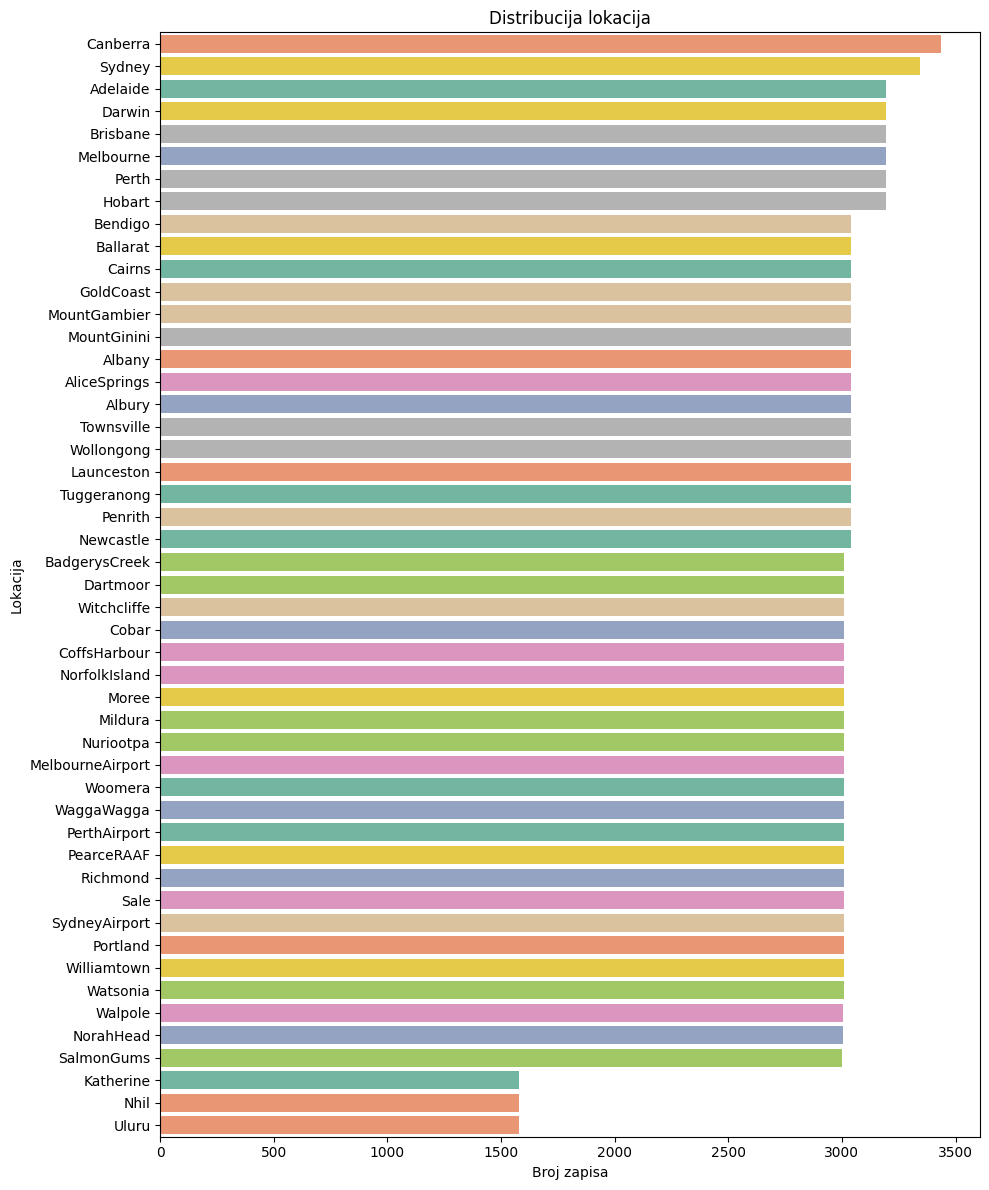

In [324]:
plt.figure(figsize=(10, 12))

order = data['Location'].value_counts().index

ax = sns.countplot(
    y='Location',
    data=data,
    order=order,
    palette='Set2',
    hue='Location',
    legend=False
)

plt.title('Distribucija lokacija')
plt.xlabel('Broj zapisa')
plt.ylabel('Lokacija')

plt.tight_layout()
plt.show()

Na osnovu ovog grafika zaključujemo da se radi o nominalnom kategorijskom obeležju. Sada je neophodno proveriti kako ove lokacije utiču na našu ciljnu promenljivu RainTomorrow.

In [325]:
pd.crosstab(
    index=data['Location'],
    columns=data['RainTomorrow'],
    normalize='index'
) * 100

RainTomorrow,No,Yes
Location,,
Adelaide,77.457405,22.542595
Albany,69.609164,30.390836
Albury,79.226891,20.773109
AliceSprings,91.917854,8.082146
BadgerysCreek,79.868785,20.131215
Ballarat,73.632681,26.367319
Bendigo,81.279147,18.720853
Brisbane,77.333760,22.666240
Cairns,67.741935,32.258065


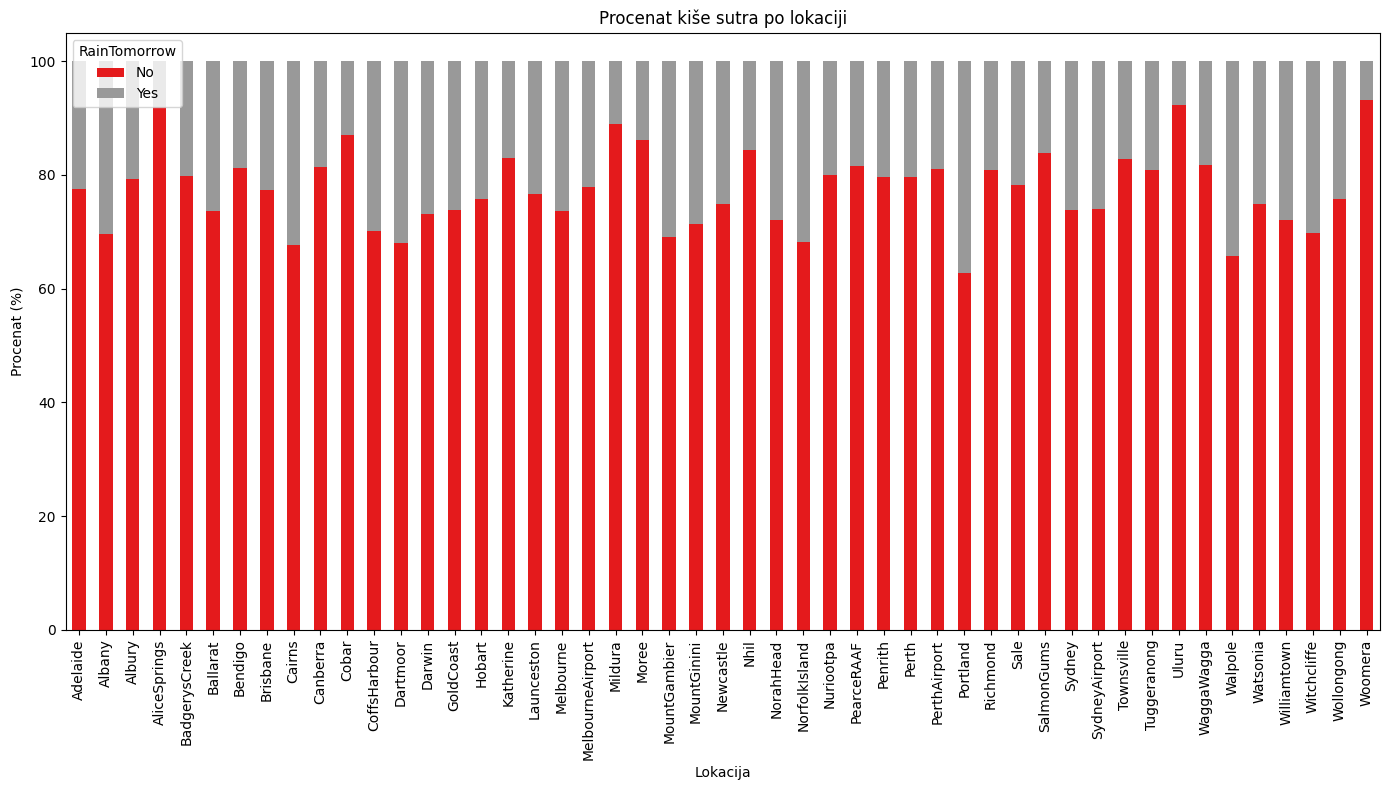

In [326]:
ct = pd.crosstab(
    data['Location'],
    data['RainTomorrow'],
    normalize='index'
) * 100

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(14,8),
    colormap='Set1'
)

plt.ylabel('Procenat (%)')
plt.xlabel('Lokacija')
plt.title('Procenat kiše sutra po lokaciji')
plt.xticks(rotation=90)
plt.legend(title='RainTomorrow')
plt.tight_layout()
plt.show()

Sa slike i sa grafika vidimo da imamo neke grupe jako sličnih procenata kada je kiša padala i kada nije. To nam može pomoći u kasnijoj analizi da možda nekako možemo da ih grupišemo(napravimo klastere).

##### 6.3.2.3 WindGustDir

WindGustDir predstavlja smer najjačeg udara vetra u 24 sata do ponoći.

In [327]:
data['WindGustDir'] = data['WindGustDir'].astype('category')

In [328]:
data['WindGustDir'].value_counts()

WindGustDir
W      9915
SE     9418
N      9313
SSE    9216
E      9181
S      9168
WSW    9069
SW     8967
SSW    8736
WNW    8252
NW     8122
ENE    8104
ESE    7372
NE     7133
NNW    6620
NNE    6548
Name: count, dtype: int64

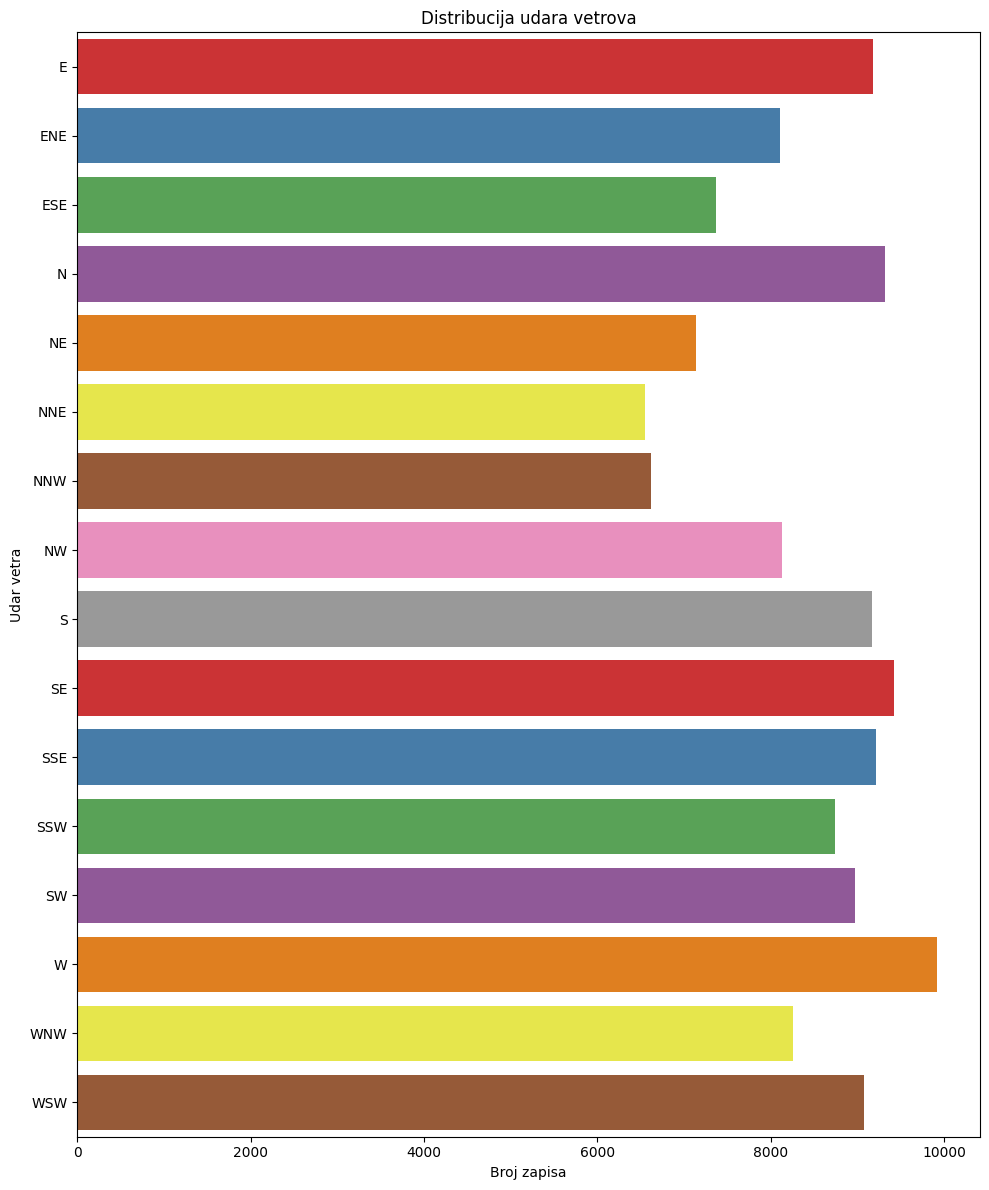

In [329]:
plt.figure(figsize=(10, 12))

ax = sns.countplot(
    y='WindGustDir',
    data=data,
    palette='Set1',
    hue='WindGustDir',
    legend=False
)

plt.title('Distribucija udara vetrova')
plt.xlabel('Broj zapisa')
plt.ylabel('Udar vetra')

plt.tight_layout()
plt.show()

Na osnovu ovoga, vidimo da WindGustDir predstavlja nominalnu kategorijsku promenljivu. Najčešći pravac najjačih udara vetra je zapad (W). Ovakav rezultat je očekivan, jer se veliki deo Australije nalazi pod uticajem preovlađujućih zapadnih vetrova (westerlies) i hladnih frontova koji dolaze sa Južnog okeana. Ovi sistemi često izazivaju najjače udare vetra upravo iz zapadnog pravca, naročito u južnim i jugoistočnim delovima zemlje.

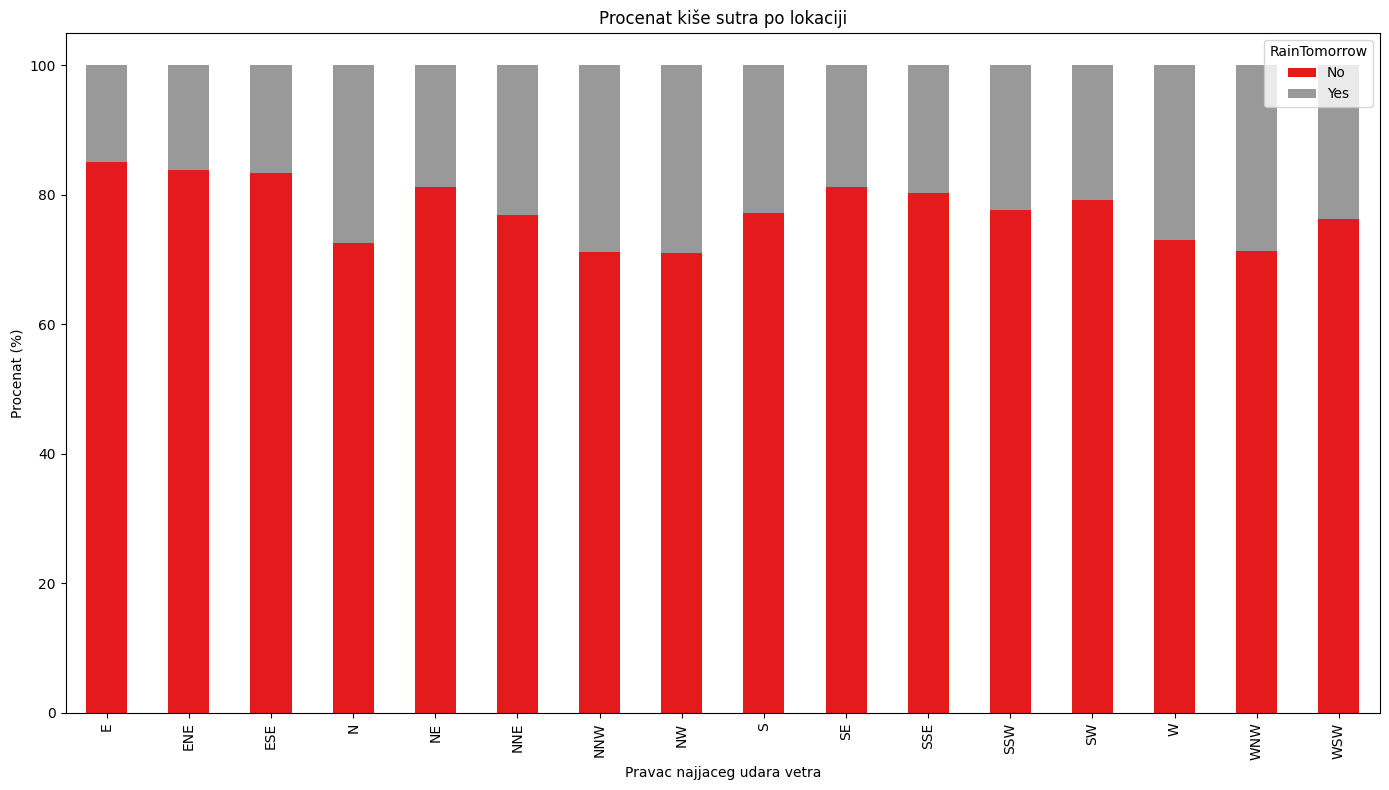

In [330]:
ct = pd.crosstab(
    data['WindGustDir'],
    data['RainTomorrow'],
    normalize='index'
) * 100

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(14,8),
    colormap='Set1'
)

plt.ylabel('Procenat (%)')
plt.xlabel('Pravac najjaceg udara vetra')
plt.title('Procenat kiše sutra po lokaciji')
plt.xticks(rotation=90)
plt.legend(title='RainTomorrow')
plt.tight_layout()
plt.show()

Sa ovog grafika ne možemo mnogo toga zaključiti sem da je odgovor RainTomorrow pretežno No u odnosu na WindGustDir u svim pravcima. Međutim, možda bismo nešto jasnije mogli da vidimo šta se dešava ukoliko bismo umesto 16 pravaca imali 8 glavnih(N, S, W, E, NE, NW, SE, SW).

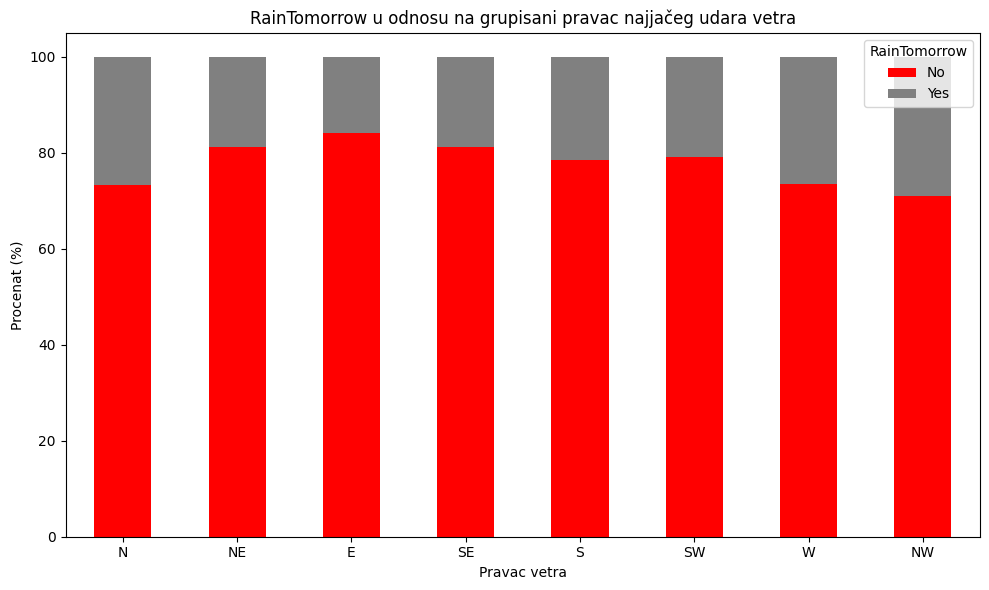

In [331]:
direction_map = {
    'N': 'N',
    'NNE': 'N',
    'NNW': 'N',

    'NE': 'NE',

    'E': 'E',
    'ENE': 'E',
    'ESE': 'E',

    'SE': 'SE',
    'SSE': 'S',

    'S': 'S',
    'SSW': 'S',

    'SW': 'SW',

    'W': 'W',
    'WNW': 'W',
    'WSW': 'W',

    'NW': 'NW'
}

data['WindGustDir_Group'] = data['WindGustDir'].map(direction_map)

ct = pd.crosstab(
    data['WindGustDir_Group'],
    data['RainTomorrow'],
    normalize='index'
) * 100

order = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
ct = ct.reindex(order)

ax = ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['red', 'gray']
)

plt.title('RainTomorrow u odnosu na grupisani pravac najjačeg udara vetra')
plt.xlabel('Pravac vetra')
plt.ylabel('Procenat (%)')
plt.legend(title='RainTomorrow')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

I dalje nemamo neka prevelika odstupanja, s obzirom na to da vidimo da vrednosti na graficima idu od nekih ~75% do ~85%, gde se blago izdvaja E.

##### 6.3.2.4 WindDir9am

WindDir9am predstavlja smer vetra određen u 9 časova ujutru.

In [332]:
data['WindDir9am'].value_counts()

WindDir9am
N      11758
SE      9287
E       9176
SSE     9112
NW      8749
S       8659
W       8459
SW      8423
NNE     8129
NNW     7980
ENE     7836
NE      7671
ESE     7630
SSW     7587
WNW     7414
WSW     7024
Name: count, dtype: int64

Na ovakav raspored bi mogli uticati lokacije koje su obuhvaćene ovim skupom podataka (u kom delu zemlje se nalaze), kao i samo godišnje doba u kome su merenja odrađena.

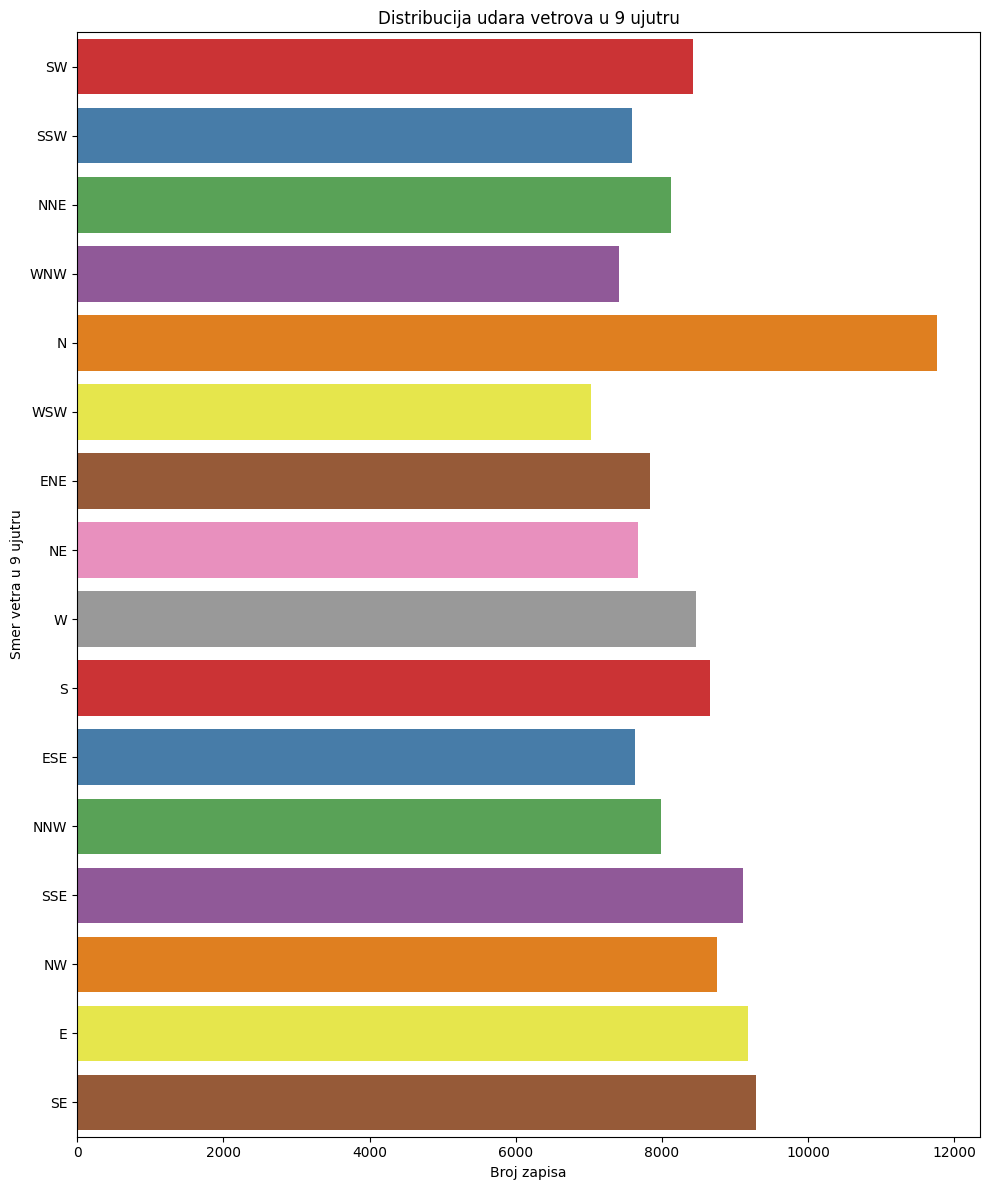

In [333]:
plt.figure(figsize=(10, 12))

ax = sns.countplot(
    y='WindDir9am',
    data=data,
    palette='Set1',
    hue='WindDir9am',
    legend=False
)

plt.title('Distribucija udara vetrova u 9 ujutru')
plt.xlabel('Broj zapisa')
plt.ylabel('Smer vetra u 9 ujutru')

plt.tight_layout()
plt.show()

Iz ovoga možemo zaključiti da imamo nominalnu kategorijsku promenljivu. Sada ćemo proveriti kako ona utiče na našu ciljnu promenljivu.

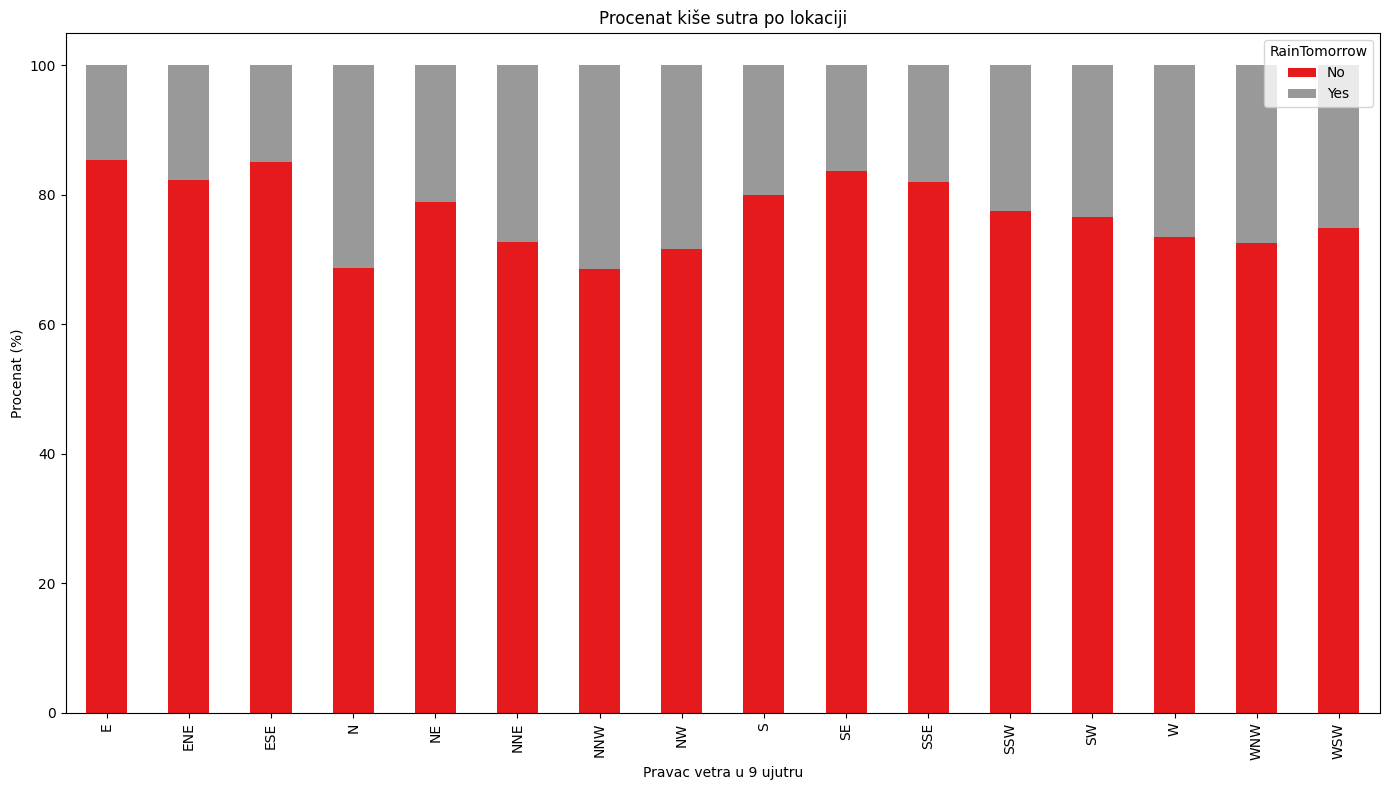

In [334]:
ct = pd.crosstab(
    data['WindDir9am'],
    data['RainTomorrow'],
    normalize='index'
) * 100

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(14,8),
    colormap='Set1'
)

plt.ylabel('Procenat (%)')
plt.xlabel('Pravac vetra u 9 ujutru')
plt.title('Procenat kiše sutra po lokaciji')
plt.xticks(rotation=90)
plt.legend(title='RainTomorrow')
plt.tight_layout()
plt.show()

Opet vidimo da i ovde ne možemo nešto mnogo zaključaka da donesemo, sem da na svim pravcima vetra u 9 ujutru pretežno nije bilo više kiše nego što jeste. Trebalo bi ispitati šta još dodatno utiče na našu ciljnu promenljivu pored pravca vetra u 9 ujutru da bismo mogli doneti više zaključaka.

##### 6.3.2.5 Kategorijsko obeležje WindDir3pm

WindDir3pm predstavlja smer vetra određen u 15 časova (3 popodne).

In [335]:
data['WindDir3pm'].value_counts()

WindDir3pm
SE     10838
W      10110
S       9926
WSW     9518
SSE     9399
SW      9354
N       8890
WNW     8874
NW      8610
ESE     8505
E       8472
NE      8263
SSW     8156
NNW     7870
ENE     7857
NNE     6590
Name: count, dtype: int64

Najčešći smer vetra u 15h je jugoistok (SE), a najređi sever-severoistok (NNE). Na ovakav raspored, kao i kod prethodna dva obeležja pravca vetra, utiču lokacije obuhvaćene skupom podataka i godišnje doba merenja.

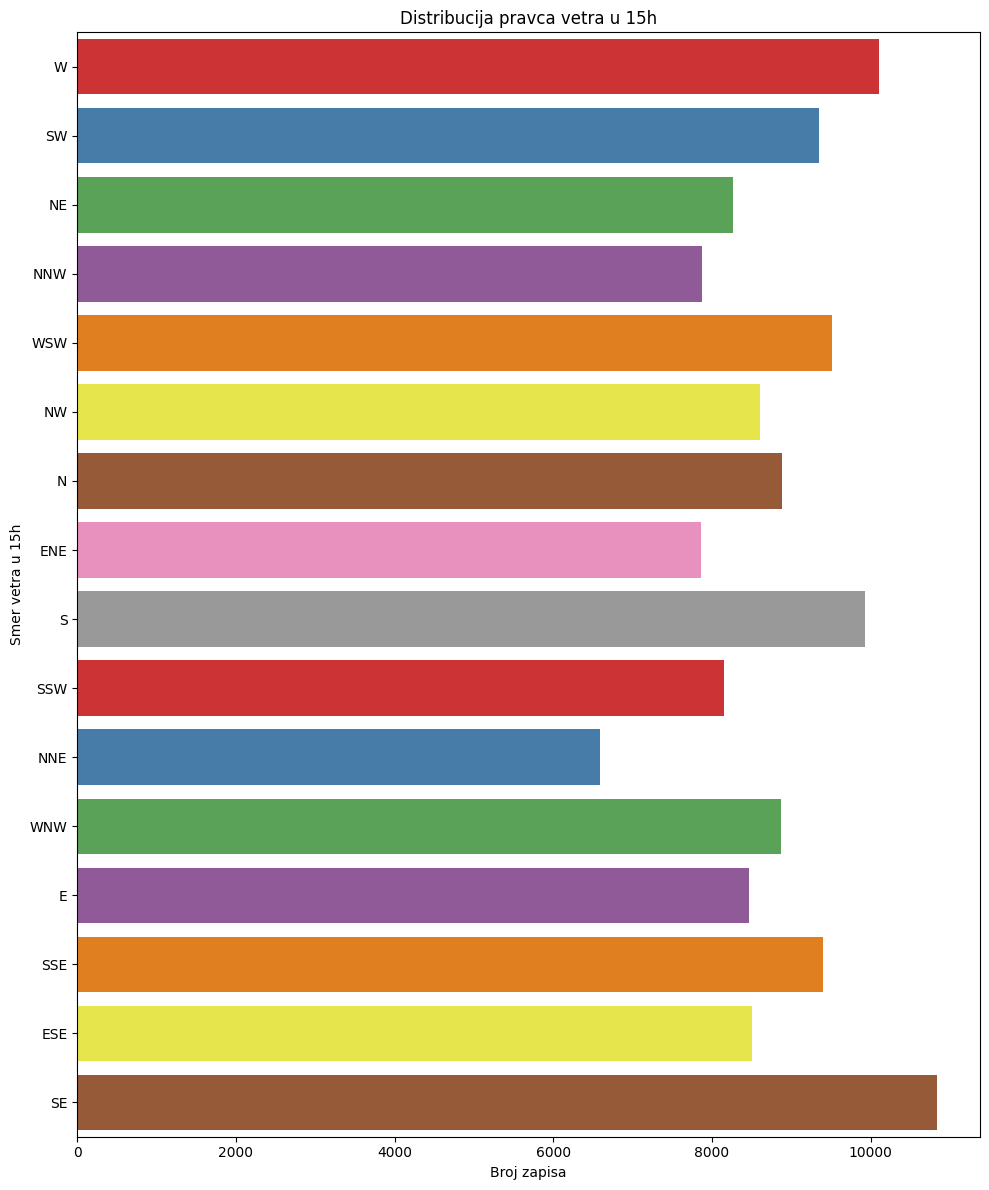

In [336]:
plt.figure(figsize=(10, 12))

ax = sns.countplot(
    y='WindDir3pm',
    data=data,
    palette='Set1',
    hue='WindDir3pm',
    legend=False
)

plt.title('Distribucija pravca vetra u 15h')
plt.xlabel('Broj zapisa')
plt.ylabel('Smer vetra u 15h')

plt.tight_layout()
plt.show()

Iz ovoga možemo zaključiti da imamo nominalnu kategorijsku promenljivu. Sada ćemo proveriti kako ona utiče na našu ciljnu promenljivu.

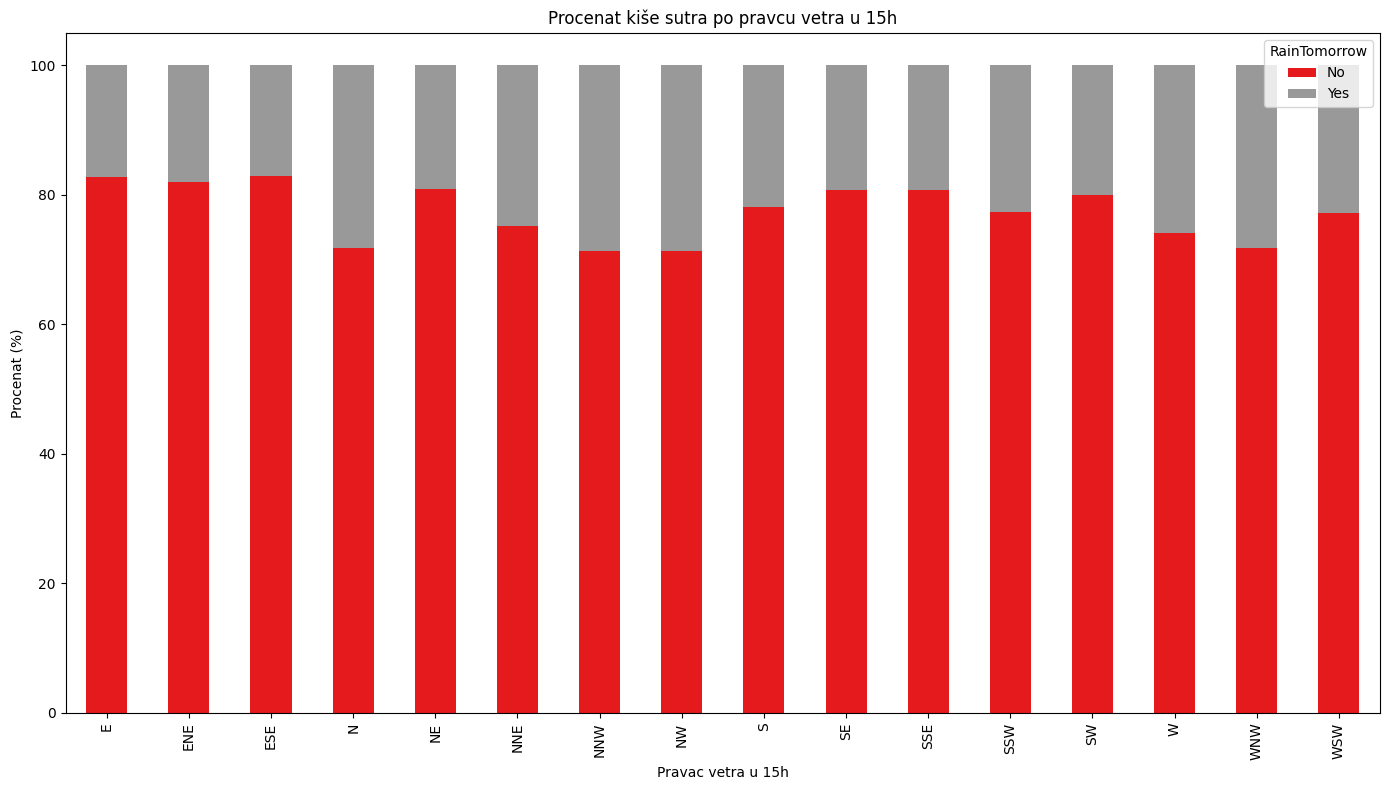

In [337]:
ct = pd.crosstab(
    data['WindDir3pm'],
    data['RainTomorrow'],
    normalize='index'
) * 100

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(14,8),
    colormap='Set1'
)

plt.ylabel('Procenat (%)')
plt.xlabel('Pravac vetra u 15h')
plt.title('Procenat kiše sutra po pravcu vetra u 15h')
plt.xticks(rotation=90)
plt.legend(title='RainTomorrow')
plt.tight_layout()
plt.show()

Za razliku od WindGustDir i WindDir9am, ovde se ipak vidi jasniji obrazac. Severni i severozapadni pravci popodnevnog vetra imaju oko 28% šanse za kišu sutradan, dok istočni pravci imaju oko 17% (skoro duplo manje). Ovo ima smisla jer u južnoj Australiji, severni i severozapadni vetar popodne često najavljuje dolazak hladnog fronta sa zapada ili jugozapada, što je klasičan predznak kiše u narednim danima. WindDir3pm je zato verovatno korisnije obeležje za predviđanje od druga dva pomenuta.

##### 6.3.2.6 RainToday

RainToday predstavlja da li je na dan merenja bilo kiše (vrednost Yes ako je tog dana palo bar 1mm padavina, inače No), u suštini binarna verzija kolone Rainfall.

In [338]:
data['RainToday'].value_counts()

RainToday
No     108560
Yes     31880
Name: count, dtype: int64

Klase su neuravnotežene. Oko 77% dana je bez kiše (No, 110319), a oko 22% sa kišom (Yes, 31880), u skladu sa onim što smo već utvrdili kod Rainfall (preko 64% dana sa tačno 0mm).

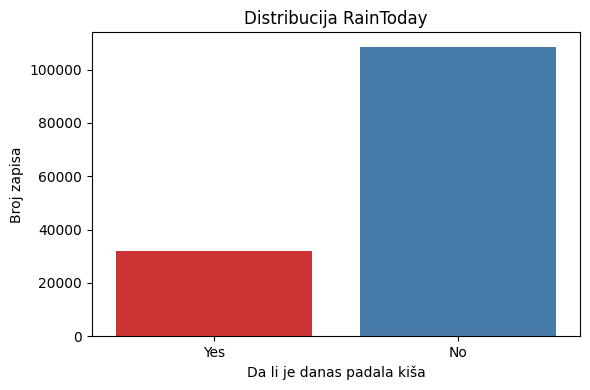

In [339]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x='RainToday',
    data=data,
    palette='Set1',
    hue='RainToday',
    legend=False
)

plt.title('Distribucija RainToday')
plt.xlabel('Da li je danas padala kiša')
plt.ylabel('Broj zapisa')

plt.tight_layout()
plt.show()

Ovo je binarna kategorijska promenljiva. Sada ćemo proveriti kako utiče na ciljnu promenljivu.

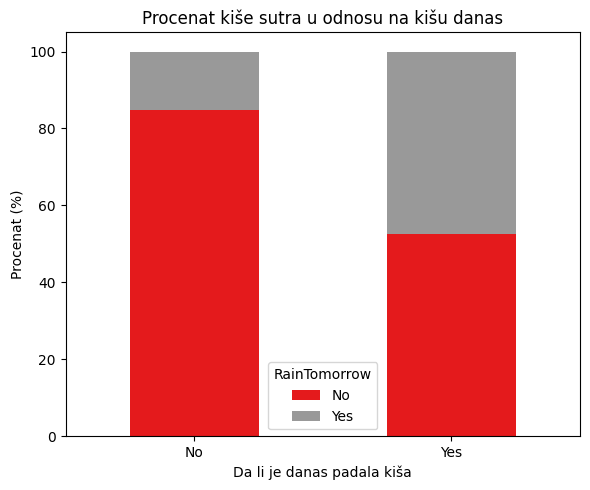

In [340]:
ct = pd.crosstab(
    data['RainToday'],
    data['RainTomorrow'],
    normalize='index'
) * 100

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(6,5),
    colormap='Set1'
)

plt.ylabel('Procenat (%)')
plt.xlabel('Da li je danas padala kiša')
plt.title('Procenat kiše sutra u odnosu na kišu danas')
plt.xticks(rotation=0)
plt.legend(title='RainTomorrow')
plt.tight_layout()
plt.show()

Za razliku od svih dosadašnjih kategorijskih obeležja gde je razlika u procentu kiše sutra između kategorija bila relativno mala, ovde je razlika ogromna. Ako danas nije padala kiša, šansa da sutra padne je samo 15.2%, a ako je danas padala kiša, ta šansa skače na 46.4% (skoro tri puta veća).

##### 6.3.2.7 RainTomorrow (ciljna promenljiva)

RainTomorrow je ciljna promenljiva koju predviđamo, da li će sledećeg dana padati kiša. Za razliku od ostalih kategorijskih obeležja, ovde nas prvenstveno zanima balans klasa, jer on direktno utiče na izbor metrika i strategiju treniranja modela (odeljak 12).

In [ ]:
data['RainTomorrow'].value_counts()

Klase su znatno neuravnotežene, oko 76% dana je bez kiše sutradan (No) naspram oko 22% sa kišom (Yes). Odnos je identičan skoro kao kod RainToday (razlika je samo pomeranje serije za jedan dan).

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x='RainTomorrow',
    data=data,
    palette='Set1',
    hue='RainTomorrow',
    legend=False
)

plt.title('Distribucija RainTomorrow')
plt.xlabel('Da li će sutra padati kiša')
plt.ylabel('Broj zapisa')

plt.tight_layout()
plt.show()

Grafik potvrđuje istu neuravnoteženost koju smo videli u brojkama, sa znatno višim stubom za kategoriju bez kiše.

### 6.4 Korelacije promenljivih

#### 6.4.1 Pirsonov koeficijent

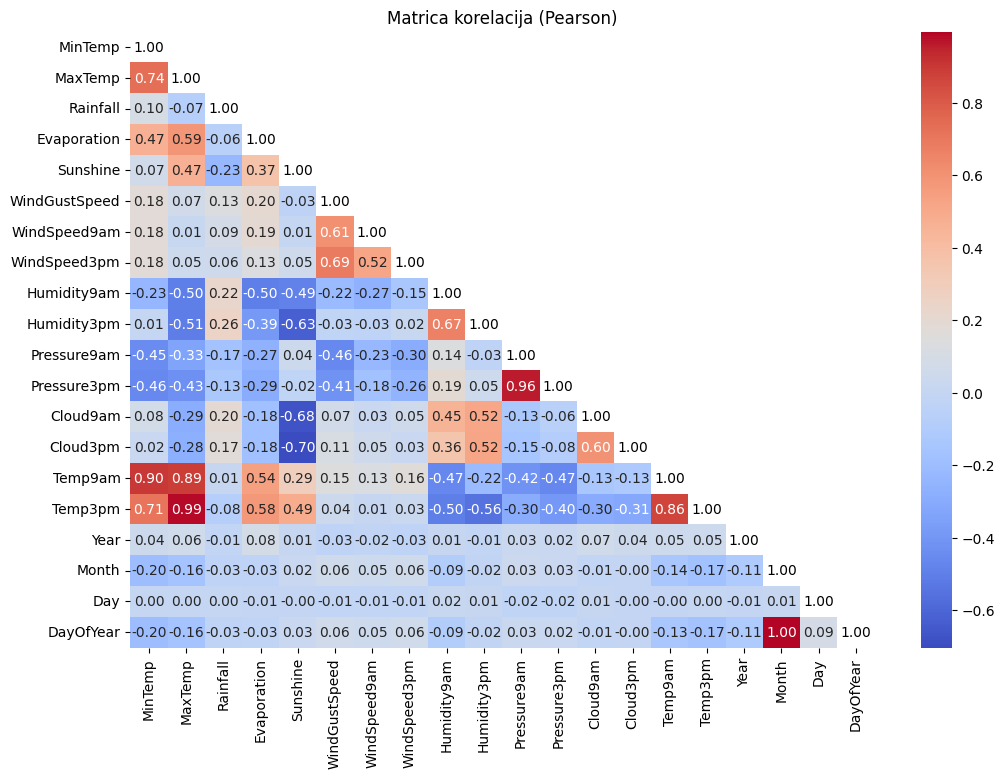

In [341]:
plt.figure(figsize=(12, 8))
corr_matrix = data.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=mask)
for i in range(len(corr_matrix)):
    plt.text(i + 0.5, i + 0.5, "1.00", ha="center", va="center", color="black")
plt.title("Matrica korelacija (Pearson)")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

Iz prikazane Pearson matrice uočavamo sledeće.

MaxTemp i Temp3pm pokazuju veoma jaku pozitivnu korelaciju (r = 0.99), što je očekivano jer je Temp3pm skoro uvek najtopliji deo dana, blizu dnevnog maksimuma. Pressure9am i Pressure3pm su takođe skoro identični (r = 0.96), atmosferski pritisak se retko menja drastično u toku jednog dana. MinTemp i Temp9am (r = 0.90), MaxTemp i Temp9am (r = 0.89) i Temp9am i Temp3pm (r = 0.86) pokazuju da su sve četiri temperaturske kolone međusobno jako povezane, što ima smisla jer sve mere istu fizičku veličinu u različitim trenucima dana. Sunshine pokazuje umerenu do jaku negativnu korelaciju sa Cloud3pm (r = -0.70) i Cloud9am (r = -0.68), logično, više oblaka znači manje sunčevih sati. WindGustSpeed ima samo umerenu korelaciju sa WindSpeed9am i WindSpeed3pm (r otprilike 0.60 do 0.69), jak udar vetra ne znači nužno i konstantno jak vetar tokom dana.

Kombinacije MaxTemp i Temp3pm, Pressure9am i Pressure3pm, MinTemp i Temp9am, MaxTemp i Temp9am i Temp9am i Temp3pm sa jakom korelacijom mogu potencijalno da predstavljaju problem multikolinearnosti.

#### 6.4.2 Spirmanov koeficijent

S obzirom da smo ranije utvrdili da je Rainfall ima jaku desnu asimetriju, bilo bi dobro proveriti Spirmanov koeficijent korelacije.

In [342]:
corr_spearman = data.corr(method='spearman', numeric_only=True)
razlika = (corr_spearman - corr_matrix)

mask_r = np.triu(np.ones_like(razlika, dtype=bool))
razlika_masked = razlika.mask(mask_r)

top_razlike = razlika_masked.unstack().dropna().sort_values(key=lambda x: x.abs(), ascending=False)
top_razlike.head(10)

Rainfall     Evaporation   -0.244965
             Temp3pm       -0.225681
MaxTemp      Rainfall      -0.223389
Rainfall     Humidity9am    0.220011
             Humidity3pm    0.187881
             Cloud9am       0.175497
             Sunshine      -0.173758
             Temp9am       -0.164992
             Cloud3pm       0.149508
Evaporation  Temp9am        0.126786
dtype: float64

Poređenje Pearson i Spirman korelacije potvrđuje pretpostavku, najveća odstupanja se dešavaju baš oko kolone Rainfall.

Kod para Rainfall i Evaporation, Pearson r iznosi -0.06 a Spirman r iznosi -0.31, razlika -0.24. Kod para Rainfall i Temp3pm, Pearson r iznosi -0.08 a Spirman r iznosi -0.31. Kod para Rainfall i MaxTemp, Pearson r iznosi -0.08 a Spirman r iznosi -0.30. Kod para Rainfall i Humidity9am, Pearson r iznosi 0.22 a Spirman r iznosi 0.44, razlika +0.22. Kod para Rainfall i Sunshine, Pearson r iznosi -0.23 a Spirman r iznosi -0.40.

Postoje nelinearne, ali monotone, zavisnosti u skupu podataka, prvenstveno vezane za Rainfall, i za tu kolonu je Spirman korelacija pouzdaniji pokazatelj nego Pearson. Za ostale, približno normalno raspodeljene kolone (temperature, pritisak), Pearson i Spirman se gotovo poklapaju, pa tu razlika nije bitna. Međutim, čak i sa Spirmanovim koeficijentom, vidimo da nije dovoljna korelacija Rainfall-a sa ostalim promenljivama.

#### 6.4.3 VIF faktor

In [343]:

num = data.select_dtypes("number").dropna()
num_const = sm.add_constant(num)

vif = pd.DataFrame()
vif["kolona"] = num_const.columns
vif["VIF"] = [variance_inflation_factor(num_const.values, i) for i in range(num_const.shape[1])]
vif = vif[vif["kolona"] != "const"].sort_values("VIF", ascending=False)
vif

,kolona,VIF
20,DayOfYear,23679.445318
18,Month,23496.388285
19,Day,167.264841
16,Temp3pm,59.786090
2,MaxTemp,49.452556
15,Temp9am,25.467899
12,Pressure3pm,20.693365
11,Pressure9am,20.659258
1,MinTemp,11.196140
10,Humidity3pm,6.791959


Rezultati potvrđuju ono što smo već videli kroz Pearson korelaciju. Temp3pm (56.4), MaxTemp (47.2), Temp9am (24.6), Pressure9am (20.1), Pressure3pm (20.1) i MinTemp (11.0) prelaze granicu od 10, problem multikolinearnosti. Ostale kolone (Humidity, Sunshine, WindGustSpeed, Cloud, Evaporation, WindSpeed, Rainfall) imaju VIF ispod 7, što je prihvatljivo.

Multikolinearnost nam predstavlja problem posebno za linearne modele, gde bismo, ukoliko njih koristimo, trebalo da izbacimo jedan po jedan ili da kombinujemo više njih u jedan.

### 6.5 Vremenska (temporalna) analiza

Kolone Year, Month i DayOfYear već smo izdvojili iz Date u sekciji 4. Pogledajmo da li postoji sezonski obrazac u učestalosti kiše, i da li postoji trend kroz godine od 2007. do 2017., ovo je relevantno i za odabir tačke podele na trening i test skup u odeljku 7.

In [ ]:
mesec_nazivi = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Maj', 6:'Jun',
                7:'Jul', 8:'Avg', 9:'Sep', 10:'Okt', 11:'Nov', 12:'Dec'}

rain_rate_month = data.groupby('Month')['RainTomorrow'].apply(lambda s: (s == 'Yes').mean() * 100)

plt.figure(figsize=(9, 4))
sns.barplot(
    x=rain_rate_month.index.map(mesec_nazivi),
    y=rain_rate_month.values,
    color=sns.color_palette('Set1')[0]
)
plt.title('Procenat dana sa kišom sutradan, po mesecu')
plt.xlabel('Mesec')
plt.ylabel('Procenat kiše sutra (%)')
plt.tight_layout()
plt.show()

Postoji jasan sezonski obrazac. Šansa za kišu sutradan raste sa oko 19% u januaru do oko 26% u julu, to jest tokom južnohemisferske zime od juna do avgusta, i ponovo opada ka proleću i letu, razlika od skoro 7 procentnih poena između najsušnijeg i najvlažnijeg meseca. Ovo potvrđuje da je sezonalnost stvaran signal.

In [ ]:
rain_rate_year = data.groupby('Year')['RainTomorrow'].apply(lambda s: (s == 'Yes').mean() * 100)
broj_redova_godina = data.groupby('Year').size()

fig, ax1 = plt.subplots(figsize=(9, 4))
sns.lineplot(x=rain_rate_year.index, y=rain_rate_year.values, marker='o', ax=ax1, color=sns.color_palette('Set1')[0])
ax1.set_xlabel('Godina')
ax1.set_ylabel('Procenat kiše sutra (%)')
ax1.set_title('Procenat dana sa kišom sutradan, po godini')

for x, y, n in zip(rain_rate_year.index, rain_rate_year.values, broj_redova_godina.values):
    ax1.annotate(f'n={n}', (x, y), textcoords='offset points', xytext=(0, 8), fontsize=7, ha='center')

plt.tight_layout()
plt.show()

Skup podataka počinje 1.11.2007. i završava se 25.6.2017, pa su 2007. (svega 61 red, samo novembar-decembar) i 2017. (do juna, 8623 reda) parcijalne godine i njihov procenat kiše nije pouzdano uporediv sa punim godinama. Za pune godine (2008-2016) procenat kiše sutradan varira između otprilike 20% i 24%, bez jasnog dugoročnog uzlaznog ili silaznog trenda.

## 7. Podela na trening i test skup

Od ovog trenutka nadalje, sve statistike i modeli koji se uče iz podataka (detekcija anomalija, feature importance analiza, imputacija nedostajucih vrednosti) moraju biti fit-ovani iskljucivo na trening delu, kako bi se izbeglo curenje informacija (data leakage) iz test skupa u proces pripreme podataka.

Granica je fiksni datum, izracunat kao 80. percentil datuma na sirovom, neobradjenom skupu (145460 redova, u opsegu od 2007-11-01 do 2017-06-25), tako da ostane stabilna kroz ceo dalji tok, bez obzira na to koliko se redova kasnije obrise ili doda u pojedinim koracima. Isti datum se koristi i za finalnu podelu pred treniranje klasifikatora.

In [10]:
SPLIT_DATE = pd.Timestamp("2015-11-10")  # 80. percentil datuma na sirovom skupu

is_train = data['Date'] < SPLIT_DATE
print(f"Train redova: {is_train.sum()}, Test redova: {(~is_train).sum()}")

Train redova: 116355, Test redova: 29105


Trening skup ima 116355 redova a test 29105, što je otprilike 80 naspram 20 procenata, u skladu sa granicom postavljenom na osamdesetom percentilu datuma.

## 8. Detekcija i uklanjanje anomalija

### 8.1 Univarijantna analiza anomalija

U priloženom kodu primenjen je robusni neparametarski pristup za univarijatnu detekciju anomalija, potpuno usklađen sa izrazito asimetričnom prirodom meteoroloških podataka. Pošto je prethodna statistička analiza jasno pokazala odsustvo normalne raspodele, metodologija se oslanja na dve stabilne neparametarske metrike.
1. Modifikovani Z skor zasnovan na MAD-u (Median absolute diviation, medijana apsolutnih razlika određene vrednosti i medijane grupe). Nakon izračunavanja MAD-a, za svaku tačku se računa z score po standardnoj formuli uz izmenu da se umesto srednje vrednosti koristi MAD. Tako dobijena vrednost množi se odgovarajućim koeficijentom kako bi se mogla porediti sa vrednostima normalne raspodele.
2. Kontinualni IQR skor, ovaj score nam govori koliko interkvartilnih raspona je određena vrednost udaljena od medijane. Idealna vrednost je 0 a sve vrednosti van intervala (-1,1) se mogu smatrati anomalijom.

Sve statističke vrednosti izračunavaju se lokalno, grupisanjem podataka prema geografskoj lokaciji i kalendarskom mesecu, čime se čuvaju sezonske i prostorne karakteristike klimatskih obrazaca.

U kod je dodat i mehanizam zaštite od deljenja nulom, koji se aktivira u slučajevima kada su vrednosti u posmatranoj grupi uniformne, što je česta pojava kod određenih meteoroloških atributa. Zadržavanje kontinualnih skorova (umesto binarne klasifikacije anomalija) nam omogućava daju analizu dobijenih rezultata. Nakon izvršavanja svih preostalih testova, rezultati će biti sačuvani u zaseban csv fajl.

In [351]:
data = loadData("backups/weatherAUSAfter5_2.csv")
identifiers = data[['Location', 'Date']].copy()
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Month', 'Year', "Day"]]

final_results = identifiers.copy()

for target_col in numeric_cols:
    data2 = data[['Location', 'Month', target_col]]
    train_data = data2[is_train].dropna()

    if train_data.empty: continue

    grouped = train_data.groupby(['Location', 'Month'])[target_col]

    median_lookup = grouped.median()
    mad_lookup = grouped.apply(lambda x: np.median(np.abs(x - np.median(x))))
    q25_lookup = grouped.quantile(0.25)
    q75_lookup = grouped.quantile(0.75)

    global_median = train_data[target_col].median()
    global_mad = np.median(np.abs(train_data[target_col] - global_median))
    global_q25 = train_data[target_col].quantile(0.25)
    global_q75 = train_data[target_col].quantile(0.75)

    key = list(zip(data2['Location'], data2['Month']))
    median = pd.Series([median_lookup.get(k, global_median) for k in key], index=data2.index)
    mad = pd.Series([mad_lookup.get(k, global_mad) for k in key], index=data2.index)
    q25 = pd.Series([q25_lookup.get(k, global_q25) for k in key], index=data2.index)
    q75 = pd.Series([q75_lookup.get(k, global_q75) for k in key], index=data2.index)

    mad_safe = mad.replace(0, 1e-6)
    iqr_safe = (q75 - q25).replace(0, 1e-6)

    mod_z_score = 0.6745 * (data2[target_col] - median) / mad_safe
    iqr_score = (data2[target_col] - median) / iqr_safe

    valid = data2[target_col].notna()
    final_results.loc[valid, f'{target_col}_IQR_Score'] = iqr_score[valid]
    final_results.loc[valid, f'{target_col}_ModZ_Score'] = mod_z_score[valid]

final_results.to_csv('AnomalyDetectionResults/skorovi_univarijatni.csv', index=False)
print("Svi lokalizovani univarijatni skorovi su sačuvani u 'AnomalyDetectionResults/skorovi_univarijatni.csv'.")

C:\Users\lukab\AppData\Local\Temp\ipykernel_15912\605315694.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  train_data = data2[is_train].dropna()
C:\Users\lukab\AppData\Local\Temp\ipykernel_15912\605315694.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  train_data = data2[is_train].dropna()
C:\Users\lukab\AppData\Local\Temp\ipykernel_15912\605315694.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  train_data = data2[is_train].dropna()
C:\Users\lukab\AppData\Local\Temp\ipykernel_15912\605315694.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  train_data = data2[is_train].dropna()
C:\Users\lukab\AppData\Local\Temp\ipykernel_15912\605315694.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  train_data = data2[is_train].dropna()
C:\Users\lukab\AppData\Local\Temp\ipykernel_15912\605315694.py:10: UserWarning: Boole

Svi lokalizovani univarijatni skorovi su sačuvani u 'AnomalyDetectionResults/skorovi_univarijatni.csv'.


Ovaj korak samo čuva lokalizovane skorove za svaku promenljivu, njihovo tumačenje sledi tek u poslednjem koraku kada objedinimo sve metode detekcije anomalija u jedinstven skor.

### 8.2 Multivarijantna analiza anomalija

Ova analiza se bazira na ispitivanju odnosa između promenljivih. Njome ćemo pokušati da zaključimo postoje li vrednosti dva prediktora koje ne prate standardni obrazac raspodele. Na ovaj način utvrdićemo postoje li neobične kombinacije vrednosti prediktora za jedno merenje.

Mahalanobisova udaljenost je algoritam koji meri udaljenost tačke definisane sa $n$ atributa od opšteg srednjeg trenda (centra) raspodele. Za razliku od standardne euklidske razdaljine, Mahalanobisova udaljenost uzima u obzir korelaciju između svih atributa. Ako postoji jaka korelacija između dva atributa, odstupanje oba atributa od generalnog trenda se ne smatra toliko čudnim kao odstupanje u samo jednom atributu. Ovaj efekat usklađivanja dimenzija postiže se primenom inverzne matrice kovarijanse. S obzirom na to da ekstremne anomalije mogu imati nesrazmerno veliki uticaj na izračunavanje standardnog proseka i matrice kovarijanse, u ovoj analizi primenjena je robusna procena matrice kovarijanse (metod Minimum Covariance Determinant). Ovako formirana matrica teži da isprati centralnu distribuciju regularnih podataka, efikasno ignorišući uticaj autlajera prilikom definisanja referentnog centra, čime se značajno povećava preciznost i pouzdanost detekcije anomalija u višedimenzionalnom prostoru.

KNN se inače koristi za predikciju neke vrednosti na osnovu k najbližih tačaka, a mi ćemo ovaj algoritam iskoristiti kako bismo izračunali prosečnu udaljenost jedne tačke od njenih k (opredelili smo se za k=5) najbližih suseda. Što je ova distanca veća to je veća verovatnoća i da je neka tačka anomalija. Zbog potrebe za računanjem razdaljine između svih 140.000 tačaka, dodaćemo algorithm='auto' kako bi algoritam automatski zaključio kako je računanje tih distanci optimalno.

Isolation forest je algoritam zasnovan na nenadgledanom masinskom učenju i predstavlja specifičnu varijantu algoritma Random forest za namene detekcija anomalija. Osnovna ideja algoritam je da kreira veći broj stabala odlučivanja i u svakom stablu pokušava da izoluje podatke u zasebne grane. Oni podaci koji su anomalije biće izolovani mnogo ranije od normalnih podataka. Izlaz ovog algoritma je realan broj (najčešće između -1 i 1 ali može i da varira). Što je broj niži to znači da je podatak bilo lakše izolovati i da je veća verovatnoća da je u pitanju anomalija. Zbog konzistentnosi sa rezultatima drugih modela koji vrćaju visoke vrednosti za anomalije, rezultat izolation forest-a ćemo pomnožiti sa (-1).

S obzirom na to da će većina ovih algoritama prijaviti grešku za nedostajuće vrednosti, privremeno ćemo sve takve pojave popuniti medijanom za datu lokaciju. Takođe izvšićemo skaliranje podataka (svođenje na N(0,1) raspodelu) kako bi algoritam dao bolje rezultate.

Kao i kod univarijantne analize podataka, rezulate ćemo smestiti u zaseban csv fajl radi dalje analize.

In [352]:
existing_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindSpeed9am']

results = data[['Location', 'Date']].copy()

data_imputed_df = data.copy()


for col in existing_cols:
    loc_month_median = data_imputed_df.loc[is_train].groupby(['Location', 'Month'])[col].median()
    loc_median = data_imputed_df.loc[is_train].groupby('Location')[col].median()
    global_median = data_imputed_df.loc[is_train, col].median()

    key = list(zip(data_imputed_df['Location'], data_imputed_df['Month']))
    fill_lm = pd.Series([loc_month_median.get(k, np.nan) for k in key], index=data_imputed_df.index)
    fill_l = data_imputed_df['Location'].map(loc_median)
    data_imputed_df[col] = data_imputed_df[col].fillna(fill_lm).fillna(fill_l).fillna(global_median)

scaler = StandardScaler()
train_mat = scaler.fit_transform(data_imputed_df.loc[is_train, existing_cols])
data_mat = scaler.transform(data_imputed_df[existing_cols])

# --- Mahalanobisova udaljenost (fit na train, score na svima) ---
robust_cov = MinCovDet(support_fraction=0.75, random_state=42).fit(train_mat)
mahalanobis_distances = np.sqrt(robust_cov.mahalanobis(data_mat))
results['Mahalanobis_Score'] = mahalanobis_distances


k = 5
nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='auto').fit(train_mat)
distances, _ = nbrs.kneighbors(data_mat)
self_match = np.isclose(distances[:, 0], 0.0)
knn_dist_bez_sebe = np.where(self_match[:, None], distances[:, 1:], distances[:, :-1])
results['KNN_Score'] = knn_dist_bez_sebe.mean(axis=1)

iso_forest = IsolationForest(random_state=42)
iso_forest.fit(train_mat)

results['IForest_Score'] = -iso_forest.decision_function(data_mat)

results.to_csv('AnomalyDetectionResults/skorovi_multi.csv', index=False)
print("Multivarijatni skorovi su sačuvani u 'AnomalyDetectionResults/skorovi_multi.csv'.")

Multivarijatni skorovi su sačuvani u 'AnomalyDetectionResults/skorovi_multi.csv'.


Pored navedenih metoda, upotrebićemo i LOF (Local Outlier Factor). Ovo je algoritam sličan KNN algoritmu uz bitnu promenu, ovaj algoritam poredi lokalnu gustinu posmatrane tačke sa lokalnom gustinom njenih suseda. Ukoliko je gustina tačke znatno manja od gustine njenih suseda, tačka se klasifikuje kao lokalni izolovani podatak (outlier).
Prednost ovog algoritma je sto je u mogucnosti da detektuje grupu tacaka koje su izolovane od opšteg trenda podataka ali zajedno grupišu klaster koji potencijalno može biti i novitet.
Kako ovaj algoritam računa gustine svih suseda, on je znatno memorijski i vremenski zahtevniji od već računski kompleksnog KNN algoritma. Zbog toga, izršićemo uzorkovanje na 40.000 elemenata na kojima ćemo trenirati naš model.

In [353]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = data[['Location', 'Date'] + numeric_cols].copy()

df_valid = df_numeric.dropna().copy()
is_train_valid = is_train.reindex(df_valid.index)

scaler = StandardScaler()
train_scaled = scaler.fit_transform(df_valid.loc[is_train_valid, numeric_cols])
scaled_data = scaler.transform(df_valid[numeric_cols])

print("Treniranje LOF modela na uzorku (samo iz train dela)...")

np.random.seed(42)
sample_indices = np.random.choice(len(train_scaled), min(40000, len(train_scaled)), replace=False)
sample_data = train_scaled[sample_indices]

lof = LocalOutlierFactor(n_neighbors=35, novelty=True)
lof.fit(sample_data)

lof_scores = -lof.score_samples(scaled_data)

results = df_valid[['Location', 'Date']].copy()

results['LOF_Score'] = lof_scores

results.to_csv('AnomalyDetectionResults/skorovi_lof.csv', index=False)
print("Kontinualni LOF skorovi su izvezeni u 'AnomalyDetectionResults/skorovi_lof.csv'.")

Treniranje LOF modela na uzorku (samo iz train dela)...
Kontinualni LOF skorovi su izvezeni u 'AnomalyDetectionResults/skorovi_lof.csv'.


LOF skorovi su izračunati na osnovu obučenog modela i sačuvani za dalju upotrebu, isto kao i prethodne dve metode, njihov zajednički uticaj ćemo proceniti u sledećem koraku.

### 8.3 Finalna detekcija i brisanje anomalije

Sada kada smo izvršili sve analize koje smo hteli učitaćemo sva tri izveštaja i spojiti ih u jedan dataframe, tako da u jednoj vrsti imamo sve informacije za dati datum i lokaciju.
Prethodno primenjene testove možemo podeliti na tri kategorije na osnovu njihove pouzdanosti.
1. Robusni statistički modeli otporni na uticaj anomalija koje možemo smatrati najpouzdanijim
2. Z score modeli koji iako su statistiki egzaktni mogu da budu veoma pristrasni prema anomalijama
3. Modeli mašinskog učenja koji su skloni lažnim signalima po pitanju anomalija

Zbog toga, ovim grupama testova dodelićemo različite vrednosti pondera da bismo naglasili njihovu pouzdanost.
Za svaku vrstu u dataframe-u računamo zbir svih skorova pomnoženih odgovarajućim ponderom, zatim vršimo dve transformacije.
Prva je računanje magnitude za svaku vrednost (percentila vrednosti ukupnog rezultata), ova tranformacija će nam dati broj u opsegu od 0 do 1, što je veća vrednost, veća je verovatnoća da je podatak anomalija.
Druga je logaritamska transformacija, logaritam ima takvu osobinu da će veće vrednosti pojačati, ovim naglašavamo anomalije.

Na kraju, uzimamo jedan procenat najekstremnijih vrednosti i brišemo ih uz pretpostavku da su u pitanju anomalije.

Pošto ovim završavamo deo vazan za detekciju anomalija, novodobijeni dataset ćemo izvesti u csv kako bi dalji rad učinili jednostavnijim.

In [355]:
df_uni = pd.read_csv('AnomalyDetectionResults/skorovi_univarijatni.csv')
df_lof = pd.read_csv('AnomalyDetectionResults/skorovi_lof.csv')
df_multi = pd.read_csv('AnomalyDetectionResults/skorovi_multi.csv')

for d in [df_uni, df_lof, df_multi]:
    d['Date'] = pd.to_datetime(d['Date'], errors='coerce')

merged = df_uni.merge(df_multi, on=['Location', 'Date'], how='left')
merged = merged.merge(df_lof, on=['Location', 'Date'], how='left')

score_cols = [c for c in merged.columns if c not in ['Location', 'Date']]

def dobij_tezinu(ime_kolone):
    if 'ModZ' in ime_kolone or 'Mahalanobis' in ime_kolone or 'IQR' in ime_kolone:
        return 1.5
    if 'Z_Score' in ime_kolone:
        return 1.2
    if 'IForest' in ime_kolone or 'LOF' in ime_kolone or 'KNN' in ime_kolone:
        return 1.0
    return 1.0


final_scores = pd.Series(0.0, index=merged.index)
total_weights = pd.Series(0.0, index=merged.index)

for col in score_cols:
    w = dobij_tezinu(col)
    rank = merged[col].rank(pct=True)
    boosted = -np.log1p(-rank.clip(upper=0.9999))
    valid_mask = merged[col].notna()
    final_scores[valid_mask] += boosted[valid_mask] * w
    total_weights[valid_mask] += w

merged['Anomalijski_Skor'] = final_scores / total_weights.replace(0, np.nan)

merged_is_train = merged['Date'] < SPLIT_DATE
prag = merged.loc[merged_is_train, 'Anomalijski_Skor'].quantile(0.999)
merged['JE_ANOMALIJA'] = merged['Anomalijski_Skor'] > prag
obrisi = merged['JE_ANOMALIJA'] & merged_is_train

final_report = merged[merged['JE_ANOMALIJA']].sort_values(by='Anomalijski_Skor', ascending=False)
final_report.to_csv('AnomalyDetectionResults/konacni_izveštaj_anomalija.csv', index=False)
broj_anomalija = len(final_report)
broj_obrisanih = int(obrisi.sum())
print(f"\nGotovo! Prag detekcije je postavljen na: {prag:.4f} (racunat samo na train delu)")
print(f"Pronađeno je ukupno {broj_anomalija} anomalija (u celom skupu), od cega ce biti obrisano {broj_obrisanih} (samo iz train dela).")
print("Detaljan spisak pravih anomalija izvezen je u 'AnomalyDetectionResults/konacni_izveštaj_anomalija.csv'.")

mergedInfo = merged[['Location', 'Date']].copy()
mergedInfo['OBRISI'] = obrisi.values
cd_join = data.merge(mergedInfo, on=['Location', 'Date'], how='left')

cleaned_without_anoms = cd_join[cd_join['OBRISI'] != True].copy()

cleaned_without_anoms.drop(columns=['OBRISI'], inplace=True)

write_log(cleaned_without_anoms, "Obrisane anomalije (samo iz train dela)", "weatherAusAfter8_3.csv")


Gotovo! Prag detekcije je postavljen na: 2.5293 (racunat samo na train delu)
Pronađeno je ukupno 160 anomalija (u celom skupu), od cega ce biti obrisano 117 (samo iz train dela).
Detaljan spisak pravih anomalija izvezen je u 'AnomalyDetectionResults/konacni_izveštaj_anomalija.csv'.


Prag detekcije je postavljen na 2.5293, izračunat isključivo na trening delu. Od ukupno 160 pronađenih anomalija u celom skupu, 117 je obrisano iz trening dela, dok su preostale, koje pripadaju test skupu, ostavljene netaknute jer test skup ne sme da se menja na osnovu statistike izračunate iz trening podataka.

## 9. Priprema podataka

Kako ćemo u fazi imputacije trenirati modele za popunjavanje nedostajućih vrednosti, već u ovoj fazi potrebno je izvršiti feature engineering kako bismo iz dataseta izvukli maskimalnu količinu informacija.

### 9.1 Transformacija postojicih podataka

U ovom delu izvrsicemo tranformaciju podataka koji vec postoje u nasem dataframe-u na onaj nacin koji ce nasim modelima pruziti maksimalnu kolicinu informacija.

#### 9.1.1 Vremenski podaci

Za uspešnu primenu algoritama mašinskog učenja, neophodno je adekvatno pretprocesirati vremenske komponente. Ukoliko bismo datume tretirali kao klasične kategorijske promenljive i primenili 'One-Hot Encoding', to bi dovelo do eksponencijalnog rasta dimenzionalnosti skupa podataka. Sa druge strane, 'Label Encoding' unosi problem linearne progresije, gde model gubi svest o cikličnosti pri prelasku sa kraja na početak vremenskog ciklusa.

Zbog toga je logičnije primeniti metodu kružnog enkodiranja (Cyclical Encoding), transformacijom dana i meseci u tačke na dvodimenzionalnoj kružnici upotrebom sinusnih i kosinusnih funkcija. Godinu tretiramo kao nezavisnu promenljivu, ali s obzirom na to da su njene apsolutne vrednosti (2007-2017) neuporedivo veće od vrednosti sinusa i kosinusa (-1 do 1), primenićemo skaliranje godina na interval od 0 do 1. Ovo osigurava da disproporcija u magnitudama ne dovede do toga da godina dominira nad ostalim vremenskim faktorima prilikom učenja modela.

In [357]:
data = loadData('backups/weatherAusAfter8_3.csv')
is_train = data['Date'] < SPLIT_DATE  # ponovo racunamo posle reload-a (indeks/broj redova se promenio)

data['Year_Scaled'] = (data['Year'] - data.loc[is_train, 'Year'].min()) / (data.loc[is_train, 'Year'].max() - data.loc[is_train, 'Year'].min())

data['DayOfYear_Sin'] = np.sin(2 * np.pi * data['Date'].dt.dayofyear / 365.25).round(2)
data['DayOfYear_Cos'] = np.cos(2 * np.pi * data['Date'].dt.dayofyear / 365.25).round(2)

data.drop(columns=['Year', "Month", "Day", "DayOfYear"], inplace=True)

write_log(data, "Transformacija vremenskih podataka", "weatherAusAfter9_1_1.csv")

Ovim smo vremenske kolone sveli na oblik pogodniji za model, godinu smo skalirali na opseg od nule do jedan, a dan u godini smo kružno kodirali sinusom i kosinusom.

#### 9.1.2 Podaci o vetru

U datasetu se nalazi veći broj kolona koje naznačavaju smer najjačeg vetra u određenim momentima dana. Ove kolone, kao vremenski podaci, predstavljaju ordinalne kategorijske promenljive sa cikličnim redosledom. 
Ako bismo svaki smer vetra počevši od severa kodirali vrednostima počevši od jedan u smeru kazaljke na satu, dobili bismo rezultat koji će našem modelu govoriti da je severozapadni vetar najveća razlika severnome vetru, što nije tačno.
Kao i kod vremenskih podataka, da bismo rešili ovaj problem izvršićemo kružno kodiranje.

In [358]:
wind_dir_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}
def wind_dir_to_sin_cos(df, col_name):
    df[col_name + '_deg'] = df[col_name].map(wind_dir_map)
    df[col_name + '_sin'] = np.sin(np.radians(df[col_name + '_deg'])).round(2)
    df[col_name + '_cos'] = np.cos(np.radians(df[col_name + '_deg'])).round(2)
    df.drop(columns=[col_name, col_name + '_deg'], inplace=True)
    return df
def convertWinds(df):
    df = wind_dir_to_sin_cos(df, 'WindDir3pm')
    df = wind_dir_to_sin_cos(df, 'WindDir9am')
    df = wind_dir_to_sin_cos(df, 'WindGustDir')
    return df
data = convertWinds(data)
write_log(data, "Transformacija podataka o vetru", "weatherAusAfter9_1_2.csv")


Napomena o rupama u vremenskoj seriji, u odeljku 6.3.2.1 utvrdili smo da postoje periodi kada pojedinim (ili gotovo svim) lokacijama nedostaju čitavi nizovi uzastopnih dana (najizraženije, april 2011, decembar 2012. i februar 201.). Zbog toga uvodimo pomoćnu funkciju koja proverava da li razmak zaista odgovara traženom broju dana, i ako ne odgovara, vraća NaN (umesto lažne vrednosti) i takav NaN se dalje tretira identično svim ostalim nedostajućim vrednostima u odeljku 11.

In [ ]:
def gap_validan(df, broj_koraka):
    if broj_koraka == 0:
        return pd.Series(True, index=df.index)
    razmak = df.groupby('Location')['Date'].diff(broj_koraka).dt.days
    return razmak == broj_koraka

Ova pomoćna funkcija će nam kasnije služiti da izbegnemo lažne vrednosti kad god prozor za pokretni prosek ili lag prelazi preko rupe u vremenskoj seriji.

### 9.2 Dodavanje novih atributa

#### 9.2.1 Diferencijalni atributi

Na osnovu domenskog znanja i logike mozemo pretpostaviti da je u meterologiji mnogo bitnija promena veličine od samih vrednosti. Na primer, ako pritisak izmedju 9 i 15 casova znatno opadne to je mnogo jaci signal da postoji verovatnoca za kisu od samih vrednost, zato uvedimo nove kolone koje ce predstavljati promenu meteroloskih veličina u intervalu od 9 do 15 casova. Takodje, mozemo dodati kolonu koja ce predstavljati dnevni raspone temperature (razliku najvise i najnize).

Imajući u vidu da i dalje imamo nedostajuce podatke i da ćemo nakon imputacije ponovo trebati da preračunamo ove kolone, kreiraćemo funkciju za računanje ovih kolona.

In [359]:
def calculateDiff(df, col1, col2, new_col_name):
    df[new_col_name] = (df[col1] - df[col2]).round(2)
    return df
def calculateDiffs(df):
    df = calculateDiff(df, 'MaxTemp', 'MinTemp', 'Max_Min_Temp_Diff')
    df = calculateDiff(df, 'MaxTemp', 'Temp3pm', 'Max_Temp3pm_diff')
    df = calculateDiff(df, 'MaxTemp', 'Temp3pm', 'Max_Temp3pm_diff')
    df = calculateDiff(df, 'Temp9am', 'MinTemp', 'Temp9am_Min_diff')

    df = calculateDiff(df, 'WindDir3pm_sin', 'WindDir9am_sin', 'Wind_sin_diff_3pm_9am')
    df = calculateDiff(df, 'WindDir3pm_cos', 'WindDir9am_cos', 'Wind_cos_diff_3pm_9am')
    df =calculateDiff(df, 'WindSpeed3pm', 'WindSpeed9am', 'WindSpeed_diff_3pm_9am')
    df =calculateDiff(df, 'Pressure3pm', 'Pressure9am', 'Pressure_diff_3pm_9am')
    df =calculateDiff(df, 'Humidity3pm', 'Humidity9am', 'Humidity_diff_3pm_9am')
 
    validno_juce = gap_validan(df, 1)
    df['Wind_sin_diff_9am_3pm_juce'] = (df['WindDir9am_sin'] - df.groupby('Location')['WindDir3pm_sin'].shift(1)).round(2)
    df['Wind_cos_diff_9am_3pm_juce'] = (df['WindDir9am_cos'] - df.groupby('Location')['WindDir3pm_cos'].shift(1)).round(2)
    df['WindSpeed_diff_9am_3pm_juce'] = (df['WindSpeed9am'] - df.groupby('Location')['WindSpeed3pm'].shift(1)).round(2)
    df.loc[~validno_juce, ['Wind_sin_diff_9am_3pm_juce', 'Wind_cos_diff_9am_3pm_juce', 'WindSpeed_diff_9am_3pm_juce']] = np.nan
    return df
data = calculateDiffs(data)
write_log(data, "Dodavanje diferencijalnih atributa", "weatherAusAfter9_2_1.csv")


Ovim smo dodali kolone koje predstavljaju razlike između povezanih meteoroloških veličina, umesto samo njihovih sirovih vrednosti.

#### 9.2.2 Pokretni proseci

Jedan od bitnih podataka kojima bismo mogli da nadomestimo veliku kolicinu nedostajucih podataka su pokretni proseci, odnosno proseci određene veličine u prethodnih n dana.

In [ ]:
def calculateRollingMean(df, col_name, window_size):
    novo_ime = col_name + f'_rolling_mean_{window_size}'
    df[novo_ime] = (
        df.groupby('Location')[col_name]
          .rolling(window=window_size)
          .mean()
          .reset_index(0, drop=True)
    ).round(2)
    
    df.loc[~gap_validan(df, window_size - 1), novo_ime] = np.nan
    return df
def calculateRollingMeans(df):
    df = calculateRollingMean(df, 'WindSpeed3pm', 3)
    df = calculateRollingMean(df, 'WindSpeed9am', 3)
    df = calculateRollingMean(df, 'Temp3pm', 3)
    return df
data = calculateRollingMeans(data)
write_log(data, "Dodavanje pokretnih proseka", "weatherAusAfter9_2_2.csv")

Pokretni proseci brzine vetra i temperature u poslednja tri dana su sada dodati kao novi prediktori.

#### 9.2.3 Lag podaci

Jos jedan podatak koji će nam značiti u našoj budućoj analizi, pa nam je pogodno da ga imamo u svakoj vrsti, je informacija o  vrednostima odredjenih veličina pre odredjenog broja dana. Kreiraćemo funkciju za računanje ovih vrednosti.

In [361]:
def calculatePreviousValue(df, col_name, brDanaPre):
    novo_ime = col_name + '_pre_'+str(brDanaPre)+"_dana"
    df[novo_ime] = df.groupby('Location')[col_name].shift(brDanaPre)
    df.loc[~gap_validan(df, brDanaPre), novo_ime] = np.nan
    return df
def calculatePreviousValues(df):
    df = calculatePreviousValue(df, 'Pressure9am', 1)
    df = calculatePreviousValue(df, 'Pressure3pm', 1)
    return df
data = calculatePreviousValues(data)
write_log(data,"Dodavanje lag podataka", "weatherAusAfter9_2_3.csv")

Sada imamo i vrednosti pritiska od prethodnog dana kao zaseban prediktor.

#### 9.2.4 Funkcija za sveobuhvatno dodavanje podataka

Trenutni poziv funkcija moze kreirati vrednosti za nove atribute samo tamo gde postoje vrednosti za originalne atribute. Kako cemo u nastavku vršiti imputaciju nedostajućih podataka, javiće se potreba da nakon svake faze imputacije se izvrši ponovno kreiranje izvedenih promenjivih. 
Zbog toga ćemo kreirati jednu metodu koja će kad se pozove ponovno kreirati sve promenjljive.

In [362]:
def createVaribales(df):
    df = calculatePreviousValues(df)
    df = calculateRollingMeans(df)
    df = calculateDiffs(df)
    return df

Ova funkcija će nam kasnije omogućiti da posle svake faze imputacije ponovo izračunamo sve izvedene atribute na osveženim podacima.

#### 9.2.5 Učitavanje podataka o stanicama

Svaka merna stanica ima različite osobine koji proizilaze iz njenih geografskih obeležja (nadmorska visina, pozicija...). Ove osobine će dratično uticati na predikciju za svaku lokaciju. Takođe pomoću podataka o lokaciji i nadmorskoj visini, naš model će moći zaključiti koje lokacije imaju slične osobine.
Prvo ćemo ekstrahovati sve jedinstvene nazive stanica u našem dataset-u, novodobijeni dataframe predstavljaće osnovu dalje analize podataka o stanicama.

In [363]:
unique_stations = data['Location'].unique()

df_stanice = pd.DataFrame(unique_stations, columns=['StationName'])


Dobili smo listu od 49 jedinstvenih stanica koje ćemo u nastavku povezati sa njihovim geografskim podacima.

##### 9.2.5.1 Geografske karakteristike

U ovom radu je realizovano automatsko preuzimanje i integracija podataka o mernim stanicama sa zvanične stranice Australijskog biroa za meteorologiju (BOM Climate Data Stations (https://www.bom.gov.au/climate/data/lists_by_element/stations.txt)). Osnovni cilj bio je da se strukturisani podaci o mernim stanicama sintaksički obrade i povežu sa lokalnim bazama. Primenom regularnih izraza i pozicione analize iz teksta su izdvojeni ključni parametri poput identifikatora, koordinata i nadmorske visine. Nepotpune vrednosti su automatski očišćene i mapirane radi očuvanja integriteta skupa podataka. Na kraju, ekstrahovani podaci su uspešno upareni i sačuvani u ažuriranom izlaznom fajlu stanice_updated.csv.

In [ ]:

colspecs = [(0, 7), (7, 13), (13, 54), (54, 62), (62, 70), (70, 79), (79, 89), (89, 104), (104, 108), (108, 119), (119, 128), (128, 134)]
imena_kolona = ["Site", "Dist", "Site_name", "Start", "End", "Lat", "Lon", "Source", "STA", "Height", "Bar_ht", "WMO"]

df_stations = pd.read_fwf('InputData/stations.txt', skiprows=4, colspecs=colspecs, names=imena_kolona)
df_stations['Site_name'] = df_stations['Site_name'].str.strip().str.upper()


df_stations['Site'] = df_stations['Site'].astype(str).str.zfill(6) 
df_stations = df_stations[df_stations['Height'] != '..']


bom_id_map = {
    'Adelaide': '023090',      # Adelaide (Kent Town)
    'Sydney': '066062',        # Sydney (Observatory Hill)
    'Melbourne': '086071',     # Melbourne (Olympic Park)
    'Brisbane': '040913',      # Brisbane
    'Perth': '009021',         # Perth Metro
    'Hobart': '094029',        # Hobart (Ellerslie Road)
    'Darwin': '014015',        # Darwin Airport
    'Canberra': '070351',      # Canberra Airport
    'SydneyAirport': '066037', # Sydney Airport AMO
    'MelbourneAirport':'086282',# Melbourne Airport
    'PerthAirport': '009014',  # Perth Airport
    'AliceSprings': '015590',  # Alice Springs Airport
    'Newcastle': '061055',     # Nobbys Signal Station
    'Wollongong': '068188',    # Illawarra Regional Airport
    'Uluru': '015643',         # Yulara Aero
    'GoldCoast': '040764',     # Gold Coast Seaway
    'Townsville': '032040',    # Townsville Aero
    'Cairns': '031011'         # Cairns Aero
}

def prilagodi_ime(ime):
    ime_string = str(ime).strip()
    
    
    izuzeci = {
        'Nhil': 'NHILL',
        'PearceRAAF': 'PEARCE RAAF',
        'BadgerysCreek': 'BADGERYS CREEK',
        'CoffsHarbour': 'COFFS HARBOUR',
        'MountGinini': 'MOUNT GININI',
        'MountGambier': 'MOUNT GAMBIER',
        'NorfolkIsland': 'NORFOLK ISLAND',
        'WaggaWagga': 'WAGGA WAGGA'
    }
    
    if ime_string in izuzeci:
        return izuzeci[ime_string]
        
    ime_odvojeno = re.sub('([A-Z][a-z]+)', r' \1', re.sub('([A-Z]+)', r' \1', ime_string)).strip().upper()
    ime_odvojeno = re.sub(r'\s+', ' ', ime_odvojeno)
    return ime_odvojeno

lat_lista = []
lon_lista = []
height_lista = []
ime_kolone = 'StationName'


for idx, row in df_stanice.iterrows():
    kaggle_ime = str(row[ime_kolone]).strip()
    
    
    if kaggle_ime in bom_id_map:
        trazeni_id = bom_id_map[kaggle_ime]
        poklapanja = df_stations[df_stations['Site'] == trazeni_id]
    else:
        trazeno_ime = prilagodi_ime(kaggle_ime)
        
        
        poklapanja = df_stations[
            (df_stations['Site_name'] == trazeno_ime) | 
            (df_stations['Site_name'].str.startswith(trazeno_ime + ' ', na=False))
        ]
        
        if not poklapanja.empty:
            
            aero_stanice = poklapanja[poklapanja['Site_name'].str.contains('AIRPORT|AERO|AWS|AMO|OBSERVATORY|MO', na=False)]
            
            if not aero_stanice.empty:
                poklapanja = aero_stanice
        
    if not poklapanja.empty:
        najbolja_stanica = poklapanja.iloc[0] 
        lat_lista.append(najbolja_stanica['Lat'])
        lon_lista.append(najbolja_stanica['Lon'])
        height_lista.append(najbolja_stanica['Height'])
    else:
        lat_lista.append(None)
        lon_lista.append(None)
        height_lista.append(None)
        print(f"Upozorenje: Nije pronađena adekvatna stanica za '{kaggle_ime}'")


df_stanice['Lat'] = lat_lista 
df_stanice['Lon'] = lon_lista 
df_stanice['Height'] = height_lista

df_stanice['Lat'] = df_stanice['Lat'].astype(float)
df_stanice['Lon'] = df_stanice['Lon'].astype(float)
df_stanice['Height'] = df_stanice['Height'].astype(float)


df_stanice[["StationName", "Lat", "Lon", "Height"]].to_csv("GeoPodaci/stanice.csv", index=False)

Ovim postupkom je svakoj stanici pridružena njena geografska širina, dužina i nadmorska visina na osnovu zvaničnih BOM podataka.

##### 9.2.5.2 Udaljenost od okeana

Poznato je da udaljenost od okeana igra ključnu ulogu u oblikovanju lokalne klime, jer velike vodene mase deluju kao ogromni termički regulatori koji ublažavaju temperaturne ekstreme i diktiraju obrasce padavina i vlažnosti vazduha. Međutim, ovaj uticaj ne slabi ravnomerno i linearno, već najdrastičnije opada u prvim desetinama kilometara od obale, zbog čega je za precizno modelovanje neophodno koristiti inverzne vrednosti udaljenosti. Na taj način matematički mnogo vernije oslikavamo taj brzi i nagli gubitak uticaja okeana kako se zalazi dublje u unutrašnjost kopna. Da bismo ovu zakonitost praktično primenili i kvantifikovali, napisana je Python skripta koja automatizuje ceo proces merenja i transformacije podataka. Skripta najpre učitava koordinate naših meteoroloških stanica, spaja ih sa detaljnom mapom australijske obale i sve prebacuje u metrički sistem kako bi proračuni u metrima i kilometrima bili potpuno tačni. Zatim algoritam, grubo rečeno, iz svake stanice "baca zrake" u četiri osnovna pravca sveta (sever, jug, istok i zapad) i pronalazi tačku u kojoj te zamišljene linije "udaraju" u obalu. Kada se na taj način izračuna fizičko rastojanje, kod automatski invertuje dobijene kilometre i kreira nove indikatore. Kao rezultat, dobijamo novu bazu u kojoj svaka stanica ima jasan, numerički izražen uticaj okeana sa sve četiri strane sveta, spremnu za dalje statističke analize i obradu.

In [ ]:
import ssl
if GEO_LIBS_AVAILABLE:
    ssl._create_default_https_context = ssl._create_unverified_context
    
    geometrija = [Point(xy) for xy in zip(df_stanice['Lon'], df_stanice['Lat'])]
    gdf_stanice = gpd.GeoDataFrame(df_stanice, geometry=geometrija)
    gdf_stanice.set_crs(epsg=4326, inplace=True)

    
    shpfilename = shpreader.natural_earth(resolution='10m',
                                          category='physical',
                                          name='coastline')

    obale_kolekcija = list(shpreader.Reader(shpfilename).geometries())
    
    australija_obale = [geom for geom in obale_kolekcija if geom.bounds[0] > 110 and geom.bounds[2] < 160 and geom.bounds[1] > -50 and geom.bounds[3] < 0]

    if len(australija_obale) > 1:
        kombinovana_obala = linemerge(australija_obale)
    else:
        kombinovana_obala = australija_obale[0]

    
    gdf_stanice = gdf_stanice.to_crs(epsg=3577)

    projekcija_wgs84 = pyproj.CRS('EPSG:4326')
    projekcija_aus = pyproj.CRS('EPSG:3577')
    projektor = pyproj.Transformer.from_crs(projekcija_wgs84, projekcija_aus, always_xy=True).transform

    obala_metricka = transform(projektor, kombinovana_obala)

    
    def izracunaj_usmerenu_udaljenost(tacka, pravac):
        x, y = tacka.x, tacka.y
        duzina_zraka = 5000000  

        if pravac == 'Sever':
            krajnja_tacka = (x, y + duzina_zraka)
        elif pravac == 'Jug':
            krajnja_tacka = (x, y - duzina_zraka)
        elif pravac == 'Istok':
            krajnja_tacka = (x + duzina_zraka, y)
        elif pravac == 'Zapad':
            krajnja_tacka = (x - duzina_zraka, y)

        zrak = LineString([(x, y), krajnja_tacka])
        presek = zrak.intersection(obala_metricka)

        if presek.is_empty:
            return 5000.0
        else:
            return tacka.distance(presek) / 1000

    df_stanice['Dist_Sever_km'] = gdf_stanice['geometry'].apply(lambda pt: izracunaj_usmerenu_udaljenost(pt, 'Sever'))
    df_stanice['Dist_Jug_km'] = gdf_stanice['geometry'].apply(lambda pt: izracunaj_usmerenu_udaljenost(pt, 'Jug'))
    df_stanice['Dist_Istok_km'] = gdf_stanice['geometry'].apply(lambda pt: izracunaj_usmerenu_udaljenost(pt, 'Istok'))
    df_stanice['Dist_Zapad_km'] = gdf_stanice['geometry'].apply(lambda pt: izracunaj_usmerenu_udaljenost(pt, 'Zapad'))

    df_stanice['Inv_Dist_Sever'] = 1 / (df_stanice['Dist_Sever_km'] + 1)
    df_stanice['Inv_Dist_Jug'] = 1 / (df_stanice['Dist_Jug_km'] + 1)
    df_stanice['Inv_Dist_Istok'] = 1 / (df_stanice['Dist_Istok_km'] + 1)
    df_stanice['Inv_Dist_Zapad'] = 1 / (df_stanice['Dist_Zapad_km'] + 1)

    df_rezultat = pd.DataFrame(df_stanice.drop(columns='geometry', errors='ignore'))
else:
    print("[info] Preskacem racunanje udaljenosti od okeana (geopandas/cartopy nedostupni),"
          " ucitavam vec sacuvane vrednosti...")
    _cache = pd.read_csv("backups/weatherAusAfter9_2_5_4.csv")
    _lookup_cols = ['Location', 'Inv_Dist_Sever', 'Inv_Dist_Jug', 'Inv_Dist_Istok', 'Inv_Dist_Zapad']
    _lookup = _cache[_lookup_cols].drop_duplicates(subset=['Location']).rename(columns={'Location': 'StationName'})
    df_rezultat = df_stanice.merge(_lookup, on='StationName', how='left')


Svakoj stanici su sada dodate četiri inverzne udaljenosti od obale, po jedna za svaku stranu sveta, koje će modelu davati informaciju o blizini okeana.

##### 9.2.5.3 Klimatska zona

Radi preciznije analize prostornih i meteoroloških karakteristika terena, mernje stanice iz dataseta klasifikovane su prema zvaničnoj tipologiji Australijskog meteorološkog zavoda (BOM). Ovaj sistem, baziran na modifikovanoj Kepenovoj klasifikaciji, deli teritoriju na osnovu višegodišnjeg režima temperatura i rasporeda padavina.
U cilju integracije ovih podataka u analitički model, definisan je rečnik preslikavanja climate_mapping koji svaku stanicu pridružuje odgovarajućoj klimatskoj grupi.
Uvođenjem ove kategorizacije obezbeđuje se da algoritmi za mašinsko učenje uzmu u obzir regionalne klimatske specifičnosti prilikom obrade podataka o padavinama.

Podaci o klimatskim zonama su izvađeni sa sajta https://www.bom.gov.au/resources/learn-and-explore/climate-knowledge-centre/australian-climate-zones

In [366]:
climate_mapping = {
    'Darwin': 'Tropical', 'Cairns': 'Tropical', 'Katherine': 'Tropical',
    'Brisbane': 'Subtropical', 'GoldCoast': 'Subtropical', 'CoffsHarbour': 'Subtropical',
    'Newcastle': 'Subtropical', 'NorahHead': 'Subtropical', 'Sydney': 'Subtropical',
    'SydneyAirport': 'Subtropical', 'Wollongong': 'Subtropical', 'Williamtown': 'Subtropical',
    'BadgerysCreek': 'Subtropical', 'Penrith': 'Subtropical', 'Richmond': 'Subtropical',
    'Perth': 'Subtropical', 'PerthAirport': 'Subtropical', 'PearceRAAF': 'Subtropical',
    'NorfolkIsland': 'Subtropical',
    'AliceSprings': 'Desert', 'Woomera': 'Desert',
    'Cobar': 'Grassland', 'Moree': 'Grassland', 'Mildura': 'Grassland', 'SalmonGums': 'Grassland',
    'Melbourne': 'Temperate', 'MelbourneAirport': 'Temperate', 'Ballarat': 'Temperate',
    'Bendigo': 'Temperate', 'Watsonia': 'Temperate', 'Adelaide': 'Temperate',
    'MountGambier': 'Temperate', 'Nuriootpa': 'Temperate', 'Canberra': 'Temperate',
    'Tuggeranong': 'Temperate', 'MountGinini': 'Temperate', 'Hobart': 'Temperate',
    'Launceston': 'Temperate', 'Albury': 'Temperate', 'WaggaWagga': 'Temperate',
    'Albany': 'Temperate', 'Witchcliffe': 'Temperate', 'Walpole': 'Temperate',
    'Dartmoor': 'Temperate', 'Portland': 'Temperate', 'Sale': 'Temperate', "Uluru": "Desert", "Townsville": "Tropical", "Nhil": "Temperate"
}

df_rezultat['ClimateGroup'] = df_rezultat['StationName'].map(climate_mapping)

Svaka stanica je sada svrstana u jednu od pet klimatskih grupa, na osnovu zvanične BOM klasifikacije.

##### 9.2.5.4 Dodavanja podataka o stanici u originalni dataframe

Sve relevantne informacije o metereoloskim stanicama nalaze se u novodobijenom dataframe-u, konacno, mozemo povezati originalni dataframe sa dataframe-om o metereoloskim stanicama.

In [367]:
def pripremi_spojen_df(df_main, df_elev):
    df = df_main.copy()
    elev_dict = df_elev.set_index('StationName')['Height'].to_dict()
    lat_dict = df_elev.set_index("StationName")["Lat"].to_dict()
    lon_dict = df_elev.set_index("StationName")["Lon"].to_dict()
    distanca_okean = {}
    for x in ["Inv_Dist_Sever", "Inv_Dist_Jug", "Inv_Dist_Istok","Inv_Dist_Zapad"]:
        df_elev[x] = df_elev[x].round(4)
        distanca_okean[x] = df_elev.set_index('StationName')[x].to_dict()
    klima_dict = df_elev.set_index('StationName')['ClimateGroup'].to_dict()
    
    df['Nadmorska visina (m)'] = df['Location'].map(elev_dict)
    df['Nadmorska visina (m)'] = df['Nadmorska visina (m)'].astype(float)

    for x in ["Inv_Dist_Sever", "Inv_Dist_Jug", "Inv_Dist_Istok","Inv_Dist_Zapad"]:
        df[x] = df['Location'].map(distanca_okean[x])
    df['klima'] = df['Location'].map(klima_dict)
    df["Lat"] = df["Location"].map(lat_dict)
    df["Lon"] = df["Location"].map(lon_dict)

    df['Lat'] = df['Lat'].astype(float)
    df['Lon'] = df['Lon'].astype(float)

    df = pd.get_dummies(df, columns=['klima'], drop_first=True, dtype=int)
    
    return df
data = pripremi_spojen_df(data, df_rezultat)
write_log(data, "Ucitavanje podataka o stanicana", "weatherAusAfter9_2_5_4.csv")

Podaci o nadmorskoj visini, udaljenosti od okeana i klimatskoj grupi su sada spojeni sa originalnim skupom podataka po lokaciji.

#### 9.2.7 Dodavanje podataka o tački rose

Tačka rose predstavlja temperaturu na koju vazduh mora da se ohladi, pri konstantnom pritisku, kako bi postao potpuno zasićen vodenom parom. Kada se temperatura vazduha izjednači sa tačkom rose, vodena para počinje da se kondenzuje, a relativna vlažnost vazduha dostiže 100%.
Potrebne podatke preuzeli smo sa zvanične Iowa Environmental Mesonet ASOS platforme, koja sadrži detaljne arhive meteoroloških merenja. Kako bismo osigurali tačnost, bilo je ključno uskladiti preuzete podatke sa lokalnim vremenskim zonama svih posmatranih lokacija širom Australije. Pomoću Python koda, precizno smo izdvojili vrednosti tačke rose zabeležene tačno u 9 ujutru i 3 popodne i integrisali ih u naš glavni dataset.

U nastavku je prikazan kod koji ilustruje proces izdvajanja, prilagođavanja vremenskih zona i spajanja novih podataka sa glavnim skupom.

In [368]:
def obradi_tacku_rose(ulazni_fajl, izlazni_fajl):
    df = pd.read_csv(ulazni_fajl)

    df = df.rename(columns={
        'station': 'Lokacija',
        'valid': 'Vreme_UTC',
        'lat': 'Lat',
        'lon': 'Lon',
        'dwpc': 'TackaRose'
    })

    df['Vreme_UTC'] = pd.to_datetime(df['Vreme_UTC'], utc=True)

    tf = TimezoneFinder()
    jedinstvene_lok = df[['Lokacija', 'Lat', 'Lon']].drop_duplicates()

    def nadji_zonu(lat, lon):
        zona = tf.timezone_at(lng=lon, lat=lat)
        return zona if zona else 'UTC'

    jedinstvene_lok['Zona'] = jedinstvene_lok.apply(lambda row: nadji_zonu(row['Lat'], row['Lon']), axis=1)

    df = df.merge(jedinstvene_lok[['Lokacija', 'Zona']], on='Lokacija', how='left')

    df['Vreme_Lokalno'] = pd.NaT
    for zona, grupa in df.groupby('Zona'):
        lokalna_zona = pytz.timezone(zona)
        df.loc[grupa.index, 'Vreme_Lokalno'] = grupa['Vreme_UTC'].dt.tz_convert(lokalna_zona).dt.tz_localize(None)

    df['Datum'] = df['Vreme_Lokalno'].dt.date

    df['Idealno_9am'] = pd.to_datetime(df['Datum'].astype(str) + ' 09:00:00')
    df['Idealno_3pm'] = pd.to_datetime(df['Datum'].astype(str) + ' 15:00:00')

    df['Razlika_9am'] = (df['Vreme_Lokalno'] - df['Idealno_9am']).abs()
    df['Razlika_3pm'] = (df['Vreme_Lokalno'] - df['Idealno_3pm']).abs()

    max_tolerancija = pd.Timedelta(hours=2)

    df_9am = df[df['Razlika_9am'] <= max_tolerancija].copy()
    df_9am = df_9am.sort_values('Razlika_9am').drop_duplicates(subset=['Lokacija', 'Datum'])
    df_9am = df_9am.rename(columns={'TackaRose': 'TackaRose9am', 'Vreme_UTC': 'univerzalnoVremeZa9am'})

    df_3pm = df[df['Razlika_3pm'] <= max_tolerancija].copy()
    df_3pm = df_3pm.sort_values('Razlika_3pm').drop_duplicates(subset=['Lokacija', 'Datum'])
    df_3pm = df_3pm.rename(columns={'TackaRose': 'TackaRose3pm', 'Vreme_UTC': 'univerzalnoVremeZa3pm'})

    izlaz_df = pd.merge(
        df_9am[['Lokacija', 'Datum', 'TackaRose9am', 'univerzalnoVremeZa9am']],
        df_3pm[['Lokacija', 'Datum', 'TackaRose3pm', 'univerzalnoVremeZa3pm']],
        on=['Lokacija', 'Datum'],
        how='outer'
    )

    izlaz_df = izlaz_df.sort_values(['Lokacija', 'Datum'])

    izlaz_df.to_csv(izlazni_fajl, index=False)
    print(f"Gotovo! Podaci su sačuvani u: {izlazni_fajl}")

if TIMEZONEFINDER_AVAILABLE and not os.path.exists('reports/tacka_rose.csv'):
    obradi_tacku_rose('InputData/asos.csv', 'reports/tacka_rose.csv')
else:
    print("[info] reports/tacka_rose.csv vec postoji (ili timezonefinder nedostupan) -"
          " preskacem ponovno racunanje tacke rose.")

Gotovo! Podaci su sačuvani u: reports/tacka_rose.csv


Sada cemo povezati novodobijeni dataframe sa originalnim.

In [370]:
df_tacka_rose = pd.read_csv("reports/tacka_rose.csv")

mapiranje_lokacija = {
    'YABA': 'Albany', 'YAYE': 'Uluru', 'YBAS': 'AliceSprings', 
    'YBBN': 'Brisbane', 'YBCS': 'Cairns', 'YBTL': 'Townsville', 
    'YCBA': 'Cobar', 'YCFS': 'CoffsHarbour', 'YMAY': 'Albury', 
    'YMEN': 'Melbourne', 'YMHB': 'Hobart', 'YMIA': 'Mildura', 
    'YMOR': 'Moree', 'YMTG': 'MountGambier', 'YPAD': 'Adelaide', 
    'YPDN': 'Darwin', 'YPJT': 'Perth', 'YPTN': 'Katherine', 
    'YPWR': 'Woomera', 'YSCB': 'Canberra', 'YSNF': 'NorfolkIsland', 
    'YSWG': 'WaggaWagga', 'YWLM': 'Williamtown'
}

df_tacka_rose['StationName'] = df_tacka_rose['Lokacija'].map(mapiranje_lokacija)

data['Date'] = pd.to_datetime(data['Date'])
df_tacka_rose['Datum'] = pd.to_datetime(df_tacka_rose['Datum'])
data = pd.merge(
    data,
    df_tacka_rose,
    left_on=['Location', 'Date'],
    right_on=['StationName', 'Datum'],
    how='left'
)

data = data.drop(columns=['StationName', 'Datum', 'Lokacija', "univerzalnoVremeZa9am", "univerzalnoVremeZa3pm"])
write_log(data, "Dodavanje podataka o tacki rose", "weatherAusAfter9_2_5.csv")


Podaci o tački rose za devet ujutru i tri popodne su sada pridruženi originalnom skupu po lokaciji i datumu.

#### 9.2.8 Dodavanje indikatora o nedostajucim podacima

U okviru pretprocesiranja skupa weatherAUS.csv, sproveden je postupak kreiranja indikatorskih kolona koje eksplicitno beleže izostanak podataka. Za svaku postojeću kolonu napravljena je njena dvojnica u kojoj vrednost 1 označava nedostatak podatka, dok 0 označava njegovo prisustvo. Značaj ove tehnike ogleda se u činjenici da izostanak vrednosti u realnim sistemima često nije slučajan i može nositi važnu prediktivnu informaciju. Ukoliko bismo nedostajuće vrednosti samo veštački popunili, algoritam bi izgubio uvid u to koji podaci su originalno izmereni. Zadržavanjem ovih informacija kroz indikatore, modelima mašinskog učenja omogućavamo da prepoznaju šablone u izostanku merenja, što znatno povećava preciznost i robusnost finalnog modela. Postupak je programski rešen u Python biblioteci pandas korišćenjem funkcija za detekciju praznina, koje logičke vrednosti uspešno transformišu u numerički binarni format. Novonastale kolone su zatim obeležene jasnim sufiksom i spojene sa originalnim datasetom, čime je on proširen bez gubitka početnih informacija.

In [371]:
indikatori = data.isna().astype(int).add_suffix('_missing')
indikatori = indikatori.loc[:, indikatori.any()]
df_prosiren = pd.concat([data, indikatori], axis=1)
write_log(df_prosiren, "Dodavanje indikatora o nedostajucim podacima", "weatherAusAfter9_2_6.csv")

Time je za svaku kolonu koja ima nedostajuće vrednosti dodata i binarna kolona koja beleži da li je ta vrednost originalno bila prisutna ili ne.

## 10. Analiza značaja atributa

U cilju analize kvaliteta ulaznih podataka i njihovog uticaja na predikciju ciljne promenljive RainTomorrow, sprovedena je analiza atributa skupa podataka weatherAUS.csv kroz dve dimenzije, procenat nedostajućih vrednosti i značaj za predikciju. Značaj atributa procenjen je pomoću dva nezavisna pristupa, Random Forest feature importance, koja odražava doprinos atributa smanjenju nečistoće u stablima odlučivanja, i mutual information, koja meri statističku zavisnost atributa od ciljne promenljive bez pretpostavke o obliku te zavisnosti. Za jedinstvenu, robusniju ocenu izračunata je geometrijska sredina normalizovanih vrednosti ova dva merila, čime se ublažava uticaj eventualnog odstupanja jedne od metrika. Rezultati su prikazani kroz objedinjenu tabelu (Excel izveštaj), toplotnu mapu koja istovremeno prikazuje nedostajuće vrednosti i oba merila značaja, i tačkasti dijagram (procenat nedostajućih vrednosti na X osi, geometrijska sredina na Y osi, sa nazivom atributa uz svaku tačku), što olakšava identifikaciju atributa koji su istovremeno korisni za model i teški za prikupljanje.

C:\Users\lukab\AppData\Local\Temp\ipykernel_15912\1734082743.py:2: DtypeWarning: Columns (56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(fileName)



=== Unakrsna matrica: značaj atributa vs. procenat nedostajućih vrednosti ===

                                     Missing_%  RF_importance  MutualInfo  RF_importance_norm  MutualInfo_norm  Geometrijska sredina RFi MI
RainTomorrow_missing                      0.00         0.3033      0.1508              0.3033           0.0900                       0.1652
Humidity3pm                               1.99         0.0486      0.1214              0.0486           0.0725                       0.0593
Max_Min_Temp_Diff                         1.15         0.0259      0.0811              0.0259           0.0484                       0.0354
Sunshine                                 43.04         0.0239      0.0676              0.0239           0.0403                       0.0310
Cloud3pm                                 38.17         0.0168      0.0649              0.0168           0.0387                       0.0255
Rainfall                                  2.24         0.0197      0.0519       

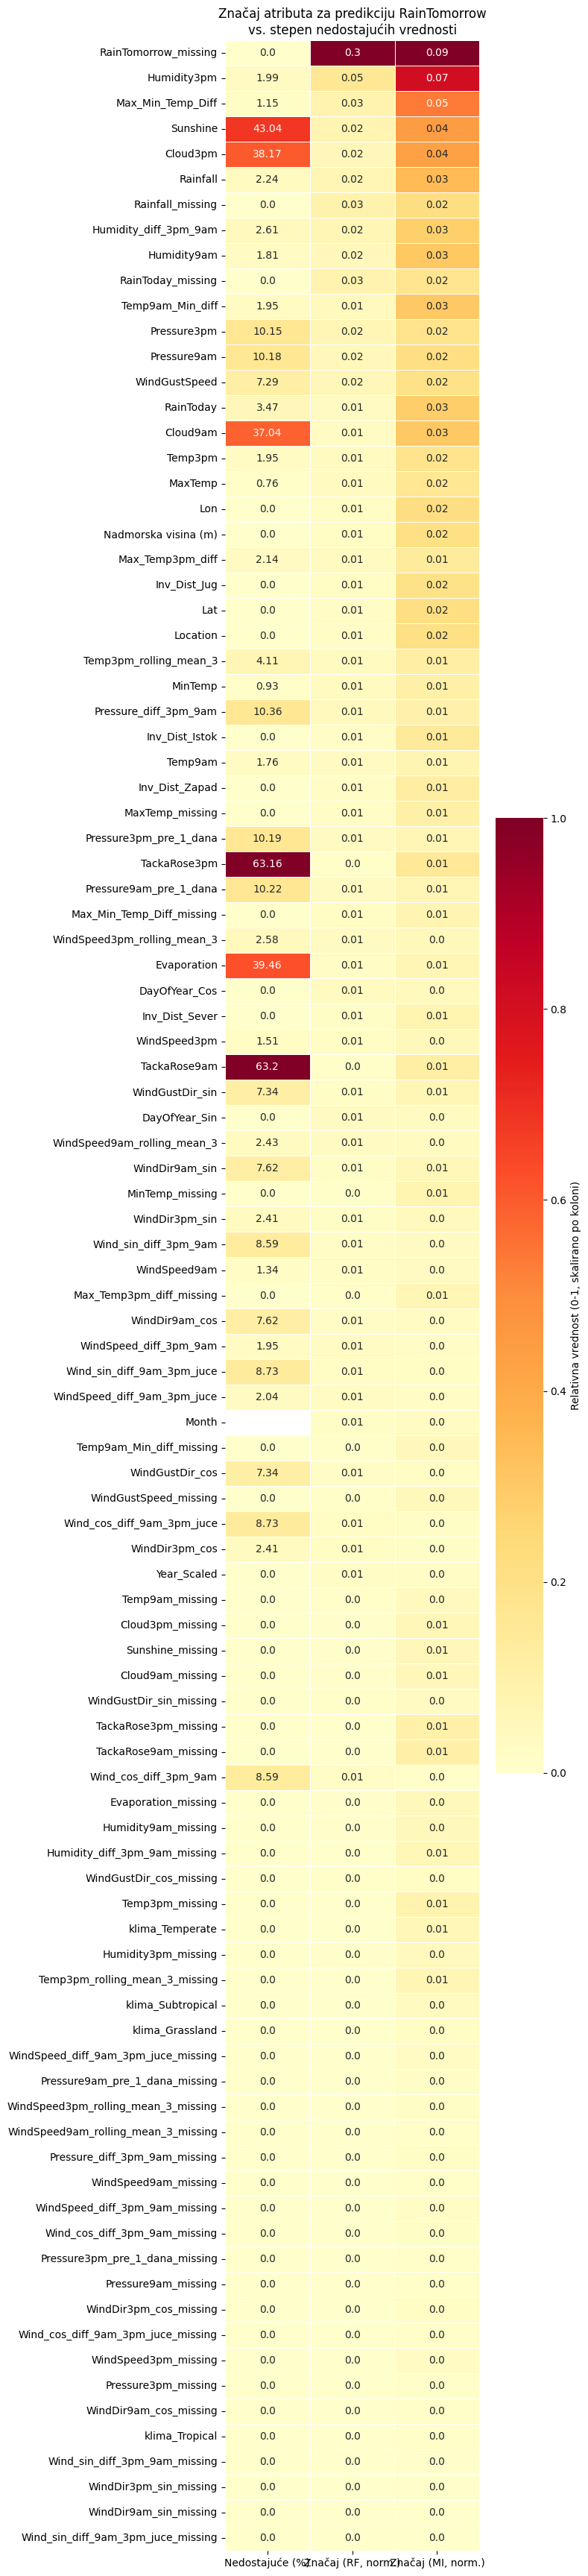

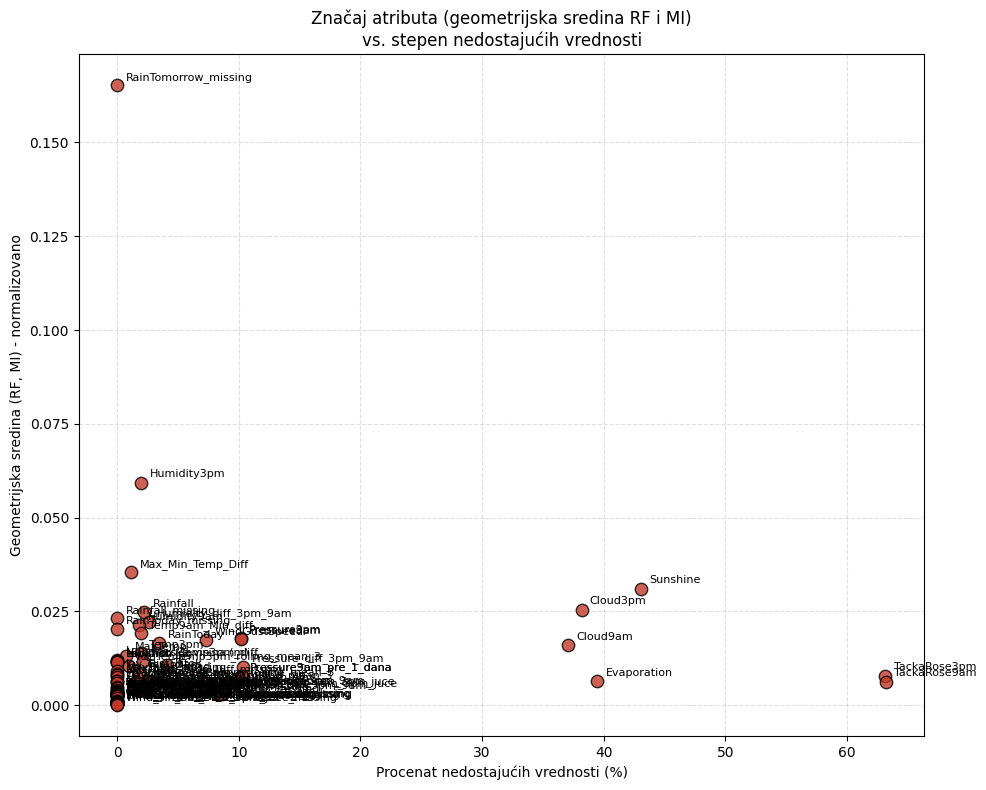

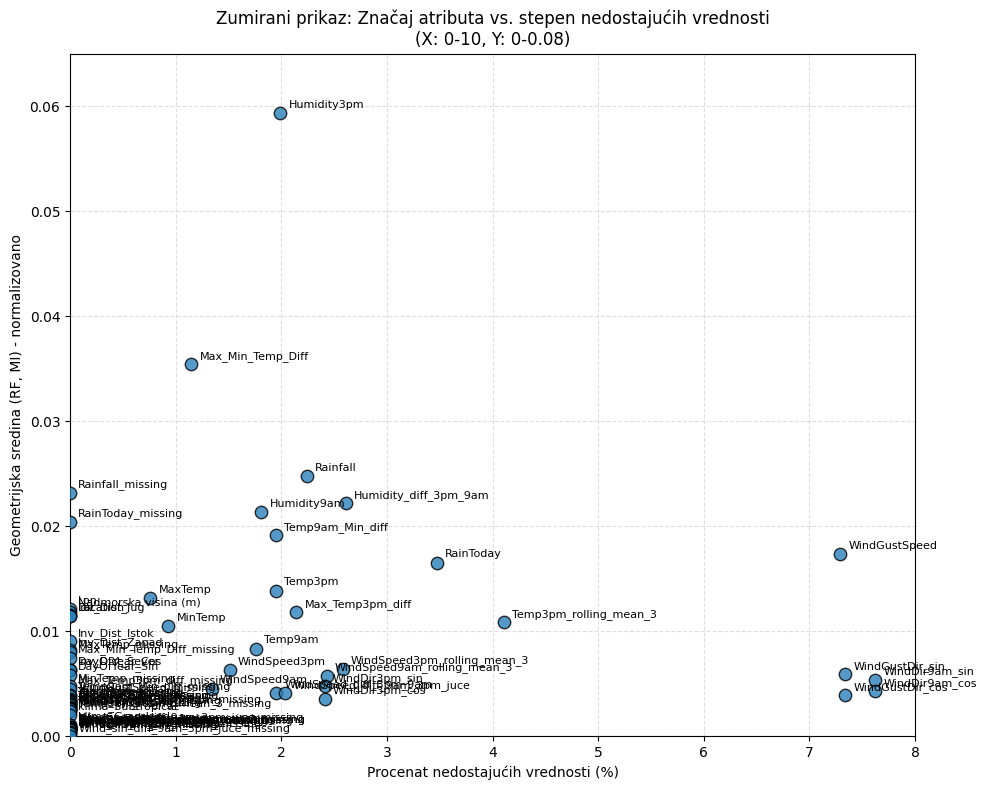

In [373]:
data = loadData('backups/weatherAusAfter9_2_6.csv')

def kreirajAnalizu():
    global data
    TARGET = "RainTomorrow"
    is_train_local = data['Date'] < SPLIT_DATE

    missing_pct = data.loc[is_train_local].isna().mean().mul(100).round(2)
    missing_pct.name = "Missing_%"

    data = data[is_train_local].copy()

    target_encoder = LabelEncoder()
    y = target_encoder.fit_transform(data[TARGET].astype(str))

    X = data.drop(columns=[TARGET])

    if "Date" in X.columns:
        X["Date"] = pd.to_datetime(X["Date"], errors="coerce")
        X["Month"] = X["Date"].dt.month
        X = X.drop(columns=["Date"])

    categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
    numeric_cols = [col for col in X.select_dtypes(include=[np.number]).columns.tolist() if not col.endswith("missing")]

    X_encoded = X.copy()

    if categorical_cols:
        cat_imputer = SimpleImputer(strategy="most_frequent")
        X_encoded[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])
        for col in categorical_cols:
            le = LabelEncoder()
            X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

    if numeric_cols:
        num_imputer = SimpleImputer(strategy="median")
        X_encoded[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])

    feature_names = X_encoded.columns.tolist()

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    )
    rf.fit(X_encoded, y)

    rf_importance = pd.Series(rf.feature_importances_, index=feature_names, name="RF_importance")

    discrete_mask = [col in categorical_cols for col in feature_names]

    mi_scores = mutual_info_classif(
        X_encoded, y, discrete_features=discrete_mask, random_state=42
    )
    mi_importance = pd.Series(mi_scores, index=feature_names, name="MutualInfo")

    summary = pd.concat(
        [missing_pct.reindex(feature_names), rf_importance, mi_importance],
        axis=1,
    )

    summary["RF_importance_norm"] = summary["RF_importance"] / summary["RF_importance"].sum()
    summary["MutualInfo_norm"] = summary["MutualInfo"] / summary["MutualInfo"].sum()

    rf_vals = summary["RF_importance_norm"].clip(lower=0)
    mi_vals = summary["MutualInfo_norm"].clip(lower=0)
    summary["Geometrijska sredina RFi MI"] = np.sqrt(rf_vals * mi_vals)

    summary = summary.sort_values("Geometrijska sredina RFi MI", ascending=False)

    print("\n=== Unakrsna matrica: značaj atributa vs. procenat nedostajućih vrednosti ===\n")
    print(summary.round(4).to_string())

    excel_path = "reports/znacaj_i_nedostajuce_vrednosti.xlsx"

    export_df = summary.reset_index().rename(columns={"index": "Atribut"})
    export_df = export_df.round(4)

    export_df.to_excel(excel_path, index=False, sheet_name="Znacaj_atributa")

    wb = load_workbook(excel_path)
    ws = wb["Znacaj_atributa"]

    header_font = Font(name="Arial", bold=True, color="FFFFFF")
    header_fill = PatternFill(start_color="4472C4", end_color="4472C4", fill_type="solid")
    body_font = Font(name="Arial")

    for col_idx, col_name in enumerate(export_df.columns, start=1):
        cell = ws.cell(row=1, column=col_idx)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = Alignment(horizontal="center")

    for row in ws.iter_rows(min_row=2, max_row=ws.max_row, min_col=1, max_col=ws.max_column):
        for cell in row:
            cell.font = body_font

    for col_idx, col_name in enumerate(export_df.columns, start=1):
        max_len = max(export_df[col_name].astype(str).map(len).max(), len(col_name)) + 3
        ws.column_dimensions[get_column_letter(col_idx)].width = max_len

    ws.freeze_panes = "A2"
    wb.save(excel_path)

    print(f"\nExcel izveštaj sačuvan u: {excel_path}")

    plot_data = summary[["Missing_%", "RF_importance_norm", "MutualInfo_norm"]].copy()
    plot_data.columns = ["Nedostajuće (%)", "Značaj (RF, norm.)", "Značaj (MI, norm.)"]

    plot_data_scaled = (plot_data - plot_data.min()) / (plot_data.max() - plot_data.min())

    plt.figure(figsize=(8, max(6, 0.35 * len(plot_data_scaled))))
    sns.heatmap(
        plot_data_scaled,
        annot=plot_data.round(2),
        fmt="",
        cmap="YlOrRd",
        linewidths=0.5,
        cbar_kws={"label": "Relativna vrednost (0-1, skalirano po koloni)"},
    )
    plt.title("Značaj atributa za predikciju RainTomorrow\nvs. stepen nedostajućih vrednosti")
    plt.tight_layout()
    plt.savefig("graphs/matrica_znacaja_i_nedostajucih.png", dpi=200)
    plt.show()


    plt.figure(figsize=(10, 8))

    x_vals = summary["Missing_%"]
    y_vals = summary["Geometrijska sredina RFi MI"]

    plt.scatter(x_vals, y_vals, s=80, color="#C0392B", edgecolor="black", alpha=0.8, zorder=3)

    for atribut in summary.index:
        plt.annotate(
            atribut,
            xy=(x_vals[atribut], y_vals[atribut]),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=8,
        )

    plt.xlabel("Procenat nedostajućih vrednosti (%)")
    plt.ylabel("Geometrijska sredina (RF, MI) - normalizovano")
    plt.title("Značaj atributa (geometrijska sredina RF i MI)\nvs. stepen nedostajućih vrednosti")
    plt.grid(True, linestyle="--", alpha=0.4, zorder=0)
    plt.tight_layout()
    plt.savefig("graphs/scatter_znacaj_vs_nedostajuci.png", dpi=200)
    plt.show()

    plt.figure(figsize=(10, 8))

    plt.scatter(x_vals, y_vals, s=80, color="#2980B9", edgecolor="black", alpha=0.8, zorder=3)

    for atribut in summary.index:
        if 0 <= x_vals[atribut] <= 10 and 0 <= y_vals[atribut] <= 0.08:
            plt.annotate(
                atribut,
                xy=(x_vals[atribut], y_vals[atribut]),
                xytext=(6, 4),
                textcoords="offset points",
                fontsize=8,
            )

    plt.xlim(0, 8)
    plt.ylim(0, 0.065)
    plt.xlabel("Procenat nedostajućih vrednosti (%)")
    plt.ylabel("Geometrijska sredina (RF, MI) - normalizovano")
    plt.title("Zumirani prikaz: Značaj atributa vs. stepen nedostajućih vrednosti\n(X: 0-10, Y: 0-0.08)")
    plt.grid(True, linestyle="--", alpha=0.4, zorder=0)
    plt.tight_layout()
    plt.savefig("graphs/scatter_znacaj_vs_nedostajuci_zumirano.png", dpi=200)
    plt.show()

kreirajAnalizu()

Analiza pokazuje da atributi sa najvećim uticajem na predikciju nisu nužno oni sa najmanje nedostajućih vrednosti, što znači da nam ni jedan atribut ne treba automatski odbaciti samo zbog visokog procenta praznina, već treba proceniti i koliko je koristan za model pre nego što odlučimo da li ga zadržavamo.

## 11. Obrada nedostajucih podataka

### 11.1 Potpuno nedostajuci atributi na lokaciji

U prethodnom delu analize detektovali smo da postoje merne stanice koje nisu bile opremljene adekvatnim senzorima za merenje svih parametara. Zbog toga postoje kolone koje su za određene lokacije u potpunosti prazne. Ova situacija može ugroziti i otežati radi svih modela imputacije i predikcije koje ćemo u budućnosti konstruisati.

Utvrdimo i prikažimo koje to lokacije imaju ovakav tip anomalije i detektujmo o kojim se promenljivima radi.

In [374]:
data = loadData("backups/weatherAusAfter9_2_6.csv")
def ispisiNpostojecePodatke():
    locations = data['Location'].unique()

    lokacije_sa_praznim_kolonama = []
    nedostajuci_atributi = tuple()
    prazniElementiDict = {}
    for loc in locations:
        subset = data[data['Location'] == loc]
        prazne_kolone = [col for col in data.columns if subset[col].isna().all()]
        
        if prazne_kolone:
            nedostajuci_atributi += tuple(prazne_kolone)
            lokacije_sa_praznim_kolonama.append(loc)
            print(f"Lokacija: {loc} ima prazne kolone: {prazne_kolone}")
            prazniElementiDict[loc] = prazne_kolone
    print("\nLista lokacija sa potpuno praznim kolonama za neke atribute:")
    print(lokacije_sa_praznim_kolonama)
    print("\nPotpuno nedostajući atributi u pojedinim meteorološkim stanicama:")
    print(set(nedostajuci_atributi))
    return lokacije_sa_praznim_kolonama, set(nedostajuci_atributi), prazniElementiDict

lokacije_sa_praznim_kolonama, nedostajuci_atributi, prazniElementiDict = ispisiNpostojecePodatke()

print(prazniElementiDict)


C:\Users\lukab\AppData\Local\Temp\ipykernel_15912\1734082743.py:2: DtypeWarning: Columns (56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(fileName)


Lokacija: Adelaide ima prazne kolone: ['Cloud9am', 'Cloud3pm']
Lokacija: Albany ima prazne kolone: ['WindGustSpeed', 'WindGustDir_sin', 'WindGustDir_cos']
Lokacija: Albury ima prazne kolone: ['Evaporation', 'Sunshine']
Lokacija: BadgerysCreek ima prazne kolone: ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm', 'TackaRose9am', 'TackaRose3pm']
Lokacija: Ballarat ima prazne kolone: ['Evaporation', 'Sunshine', 'TackaRose9am', 'TackaRose3pm']
Lokacija: Bendigo ima prazne kolone: ['Sunshine', 'TackaRose9am', 'TackaRose3pm']
Lokacija: Dartmoor ima prazne kolone: ['Cloud9am', 'Cloud3pm', 'TackaRose9am', 'TackaRose3pm']
Lokacija: GoldCoast ima prazne kolone: ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm', 'TackaRose9am', 'TackaRose3pm']
Lokacija: Katherine ima prazne kolone: ['Sunshine']
Lokacija: Launceston ima prazne kolone: ['Sunshine', 'TackaRose9am', 'TackaRose3pm']
Lokacija: MelbourneAirport ima prazne kolone: ['TackaRose9am', 'TackaRose3pm']
Lokacija: MountGinini ima prazne kolone:

Vidimo da nekoliko stanica ima potpuno prazne kolone za pojedine atribute, na primer Adelaide nema nijedno merenje oblačnosti, Albany nema podatke o brzini udara vetra, a Albury i BadgerysCreek nemaju Evaporation ni Sunshine. Ovakve praznine ne možemo popuniti na osnovu same te stanice, već ćemo se osloniti na susedne lokacije.

#### 11.1.1 Grupisanje mernih stanica na osnovu razdaljine

Jedna od mogućnosti kako bi se ovaj problem mogao rešiti je oslanjanje na podatke sa susednih mernih stanica. Takav pristup ima uporište u Toblerovom prvom zakonu geografije koji glasi "Sve je povezano sa svim ostalim, ali su bliske stvari povezanije od udaljenih stvari." 

Za primenu ovakvog pristupa neophodno je nejpre izračunati međusobnu udaljenosti svakog para meteoroloških stanica.

In [375]:
def haversine_razdaljina(lat1, lon1, lat2, lon2):
    """Računa vazdušnu razdaljinu između dve tačke u kilometrima."""
    R = 6371.0 # Poluprečnik Zemlje u km
    
    lat1_rad, lon1_rad = math.radians(lat1), math.radians(lon1)
    lat2_rad, lon2_rad = math.radians(lat2), math.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c

def generisi_razdaljine(ulazni_fajl, izlazni_fajl):
    stanice = []
    
    with open(ulazni_fajl, mode='r', encoding='utf-8') as fajl:
        citac = csv.DictReader(fajl)
        for red in citac:
            stanice.append({
                'ime': red['StationName'],
                'lat': float(red['Lat']),
                'lon': float(red['Lon'])
            })
    print(f"Uspešno učitano {len(stanice)} stanica iz fajla '{ulazni_fajl}'.")
    brojac_parova = 0
    with open(izlazni_fajl, mode='w', encoding='utf-8', newline='') as izlaz:
        polja = ['stanica_1', 'stanica_2', 'razdaljina_km']
        pisac = csv.DictWriter(izlaz, fieldnames=polja)
        pisac.writeheader()
        for stanica1, stanica2 in combinations(stanice, 2):
            razdaljina = haversine_razdaljina(
                stanica1['lat'], stanica1['lon'], 
                stanica2['lat'], stanica2['lon']
            )
            pisac.writerow({
                'stanica_1': stanica1['ime'],
                'stanica_2': stanica2['ime'],
                'razdaljina_km': round(razdaljina, 2)
            })
            brojac_parova += 1
            
    print(f"Završeno! Izračunato i upisano {brojac_parova} razdaljina u fajl '{izlazni_fajl}'.")

ulazni_csv = 'GeoPodaci/stanice.csv'
izlazni_csv = 'GeoPodaci/udaljenost_stanica.csv'

generisi_razdaljine(ulazni_csv, izlazni_csv)

Uspešno učitano 49 stanica iz fajla 'GeoPodaci/stanice.csv'.
Završeno! Izračunato i upisano 1176 razdaljina u fajl 'GeoPodaci/udaljenost_stanica.csv'.


Naredni korak je kreiranje skupova bliskih lokacija, lokacija kod kojih međusobna udaljenost svaka dva člana skupa nije veća od prethodno definisanog praga. Za potrebe dalje analize kreiraćemo više pragova razdaljina.

In [376]:
def pronadji_grupe_lokacija(ime_fajla, pragovi):
    df = pd.read_csv(ime_fajla)
    rezultati = {}
    
    for i in range(1,len(pragovi)):
        pragMin = pragovi[i-1]
        prag = pragovi[i]
        G = nx.Graph()
        for _, red in df.iterrows():
            lok1 = red['stanica_1']
            lok2 = red['stanica_2']
            udaljenost = red['razdaljina_km']
            
            if udaljenost <= prag and udaljenost > pragMin:
                G.add_edge(lok1, lok2)
        
        sve_grupe = list(nx.find_cliques(G))
        
        filtrirane_grupe = [grupa for grupa in sve_grupe if len(grupa) > 1]
        filtrirane_grupe.sort(key=len, reverse=True)
        rezultati[prag] = filtrirane_grupe
        
    return rezultati

trazeni_pragovi = [0,50, 100, 200, 300]
fajl = "GeoPodaci/udaljenost_stanica.csv"
izlazni_fajl = "StationClasters/pronadjene_grupe.csv"

pronadjene_grupe = pronadji_grupe_lokacija(fajl, trazeni_pragovi)

podaci_za_csv = []

if pronadjene_grupe:
    for prag in trazeni_pragovi:
        
        grupe_za_prag = pronadjene_grupe.get(prag, [])
        if grupe_za_prag:
            for i, grupa in enumerate(grupe_za_prag, 1):
                print(f"Grupa {i} ({len(grupa)} članova): {', '.join(grupa)}")
                
                podaci_za_csv.append({
                    'Prag_km': prag,
                    'Grupa_ID': i,
                    'Broj_clanova': len(grupa),
                    'Clanovi': ', '.join(grupa)
                })
        else:
            print("Nema pronađenih grupa za ovaj prag.")

if podaci_za_csv:
    df_izlaz = pd.DataFrame(podaci_za_csv)
    df_izlaz.to_csv(izlazni_fajl, index=False, encoding='utf-8')
    print(f"\nUspesno sačuvano u: {izlazni_fajl}")
else:
    print("\nNema podataka za čuvanje u CSV.")

Nema pronađenih grupa za ovaj prag.
Grupa 1 (3 članova): Melbourne, MelbourneAirport, Watsonia
Grupa 2 (3 članova): MountGinini, Canberra, Tuggeranong
Grupa 3 (3 članova): BadgerysCreek, Sydney, SydneyAirport
Grupa 4 (2 članova): NorahHead, Newcastle
Grupa 5 (2 članova): Perth, PearceRAAF
Grupa 6 (2 članova): Newcastle, Williamtown
Grupa 7 (2 članova): BadgerysCreek, Penrith
Grupa 1 (3 članova): NorahHead, Penrith, Sydney
Grupa 2 (3 članova): NorahHead, Penrith, SydneyAirport
Grupa 3 (3 članova): Wollongong, Penrith, Sydney
Grupa 4 (3 članova): Wollongong, Penrith, SydneyAirport
Grupa 5 (2 članova): Portland, MountGambier
Grupa 6 (2 članova): GoldCoast, Brisbane
Grupa 7 (2 članova): MelbourneAirport, Ballarat
Grupa 8 (2 članova): NorahHead, Williamtown
Grupa 9 (2 članova): Adelaide, Nuriootpa
Grupa 10 (2 članova): Bendigo, Ballarat
Grupa 11 (2 članova): Wollongong, BadgerysCreek
Grupa 12 (2 članova): Walpole, Albany
Grupa 1 (3 članova): Albury, WaggaWagga, MountGinini
Grupa 2 (2 članov

Na najmanjem pragu od pedeset kilometara već dobijamo nekoliko prirodnih grupa susednih stanica, na primer Melbourne, MelbourneAirport i Watsonia, ili MountGinini, Canberra i Tuggeranong, koje ćemo koristiti kao izvor podataka jedne za drugu.

#### 11.1.2 Računanje matrice korelacija za svaku od grupa

Sada ćemo kreirati pomoćnu funkciju koja će za prosledjenu listu lokacija i određeni atribut kreirati matricu korelacije. Posto nam je bitna samo generalna statistika, kreriaćemo još jednu metodu koja će nam vratiti srednju vrednost korelacije.

In [377]:
def izracunaj_korelaciju(lokacije, parametar):
    df_filtrirano = data[data['Location'].isin(lokacije)]
    pivot_tabela = df_filtrirano.pivot(
        index='Date', 
        columns='Location', 
        values=parametar
    )
    korelacija = pivot_tabela.corr()

def summarise_correlation(grupe, atributi):
    rezultati = {}
    
    for atribut in atributi:
        sve_korelacije = []
        
        for grupa in grupe:
            df_filtrirano = data[data['Location'].isin(grupa)]
            pivot = df_filtrirano.pivot(index='Date', columns='Location', values=atribut)
            
            corr_matrix = pivot.corr().abs()
            
            np.fill_diagonal(corr_matrix.values, np.nan)
            
            mean_corr = corr_matrix.stack().mean(skipna=True)
            
            if mean_corr is not None and not np.isnan(mean_corr) and mean_corr >= 0.0:
                sve_korelacije.append(mean_corr)
        
        if sve_korelacije:
            rezultati[atribut] = float(np.mean(sve_korelacije))
        else:
            rezultati[atribut] = None
    
    return rezultati


Ovu funkciju sada možemo iskoristiti i proveriti za koji od problematičnih atributa važi zakonitost. Otpočnimo sa najnižim pragom od 50km. Takodje, trenutno u analizi ćemo koristiti iskljucivo numericke promenljive.

  Nema pronađenih grupa za razdaljinu 0 km. Preskačem...
Matrica uspešno sačuvana kao 'reports/claster_corelations/korelacije_po_grupama_i_atributima_razdljina_50.csv'.



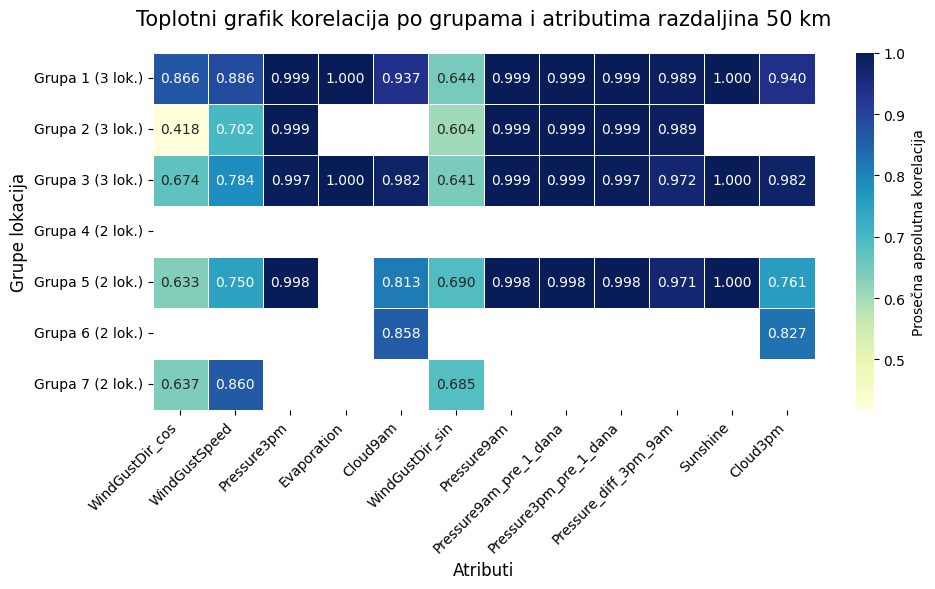

Matrica uspešno sačuvana kao 'reports/claster_corelations/korelacije_po_grupama_i_atributima_razdljina_100.csv'.



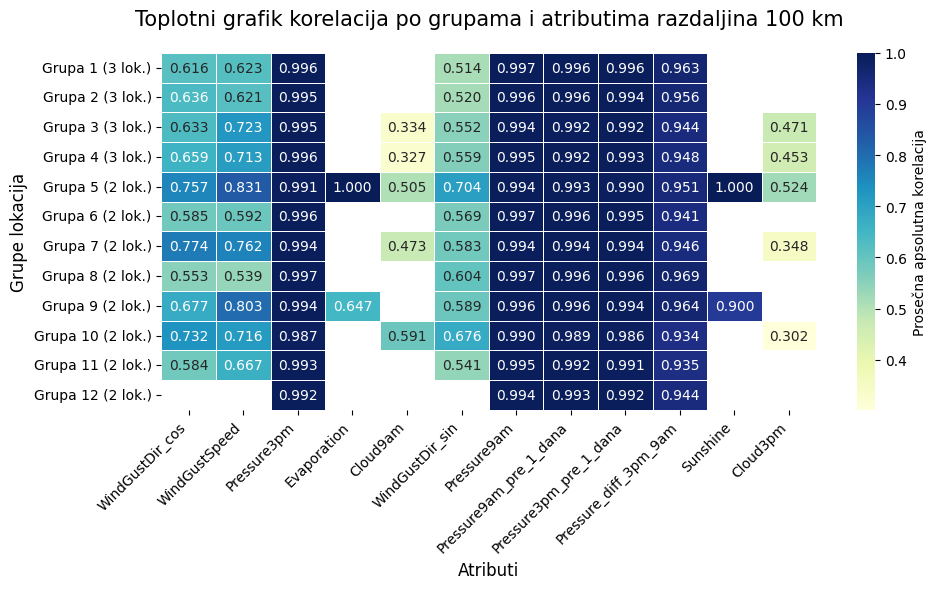

Matrica uspešno sačuvana kao 'reports/claster_corelations/korelacije_po_grupama_i_atributima_razdljina_200.csv'.



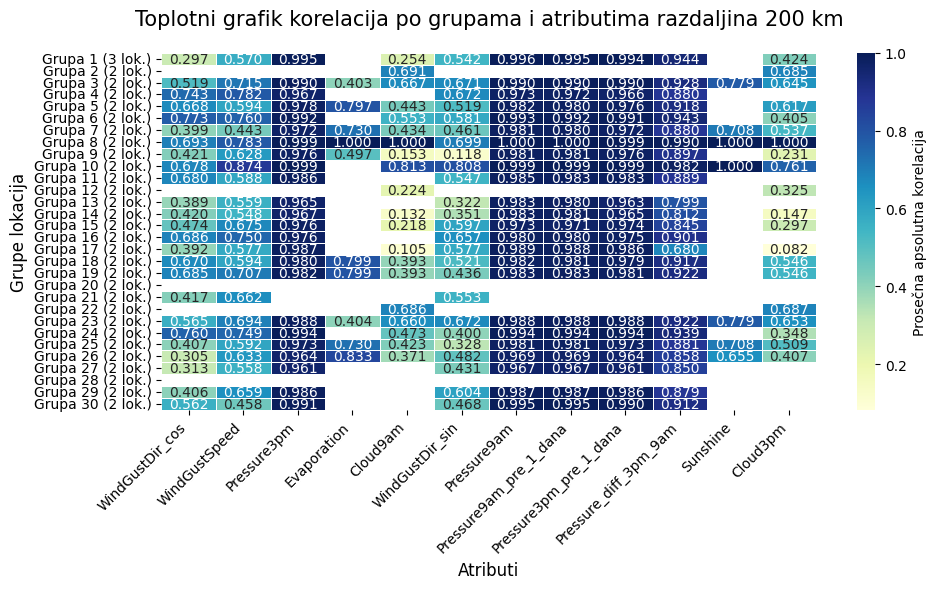

Matrica uspešno sačuvana kao 'reports/claster_corelations/korelacije_po_grupama_i_atributima_razdljina_300.csv'.



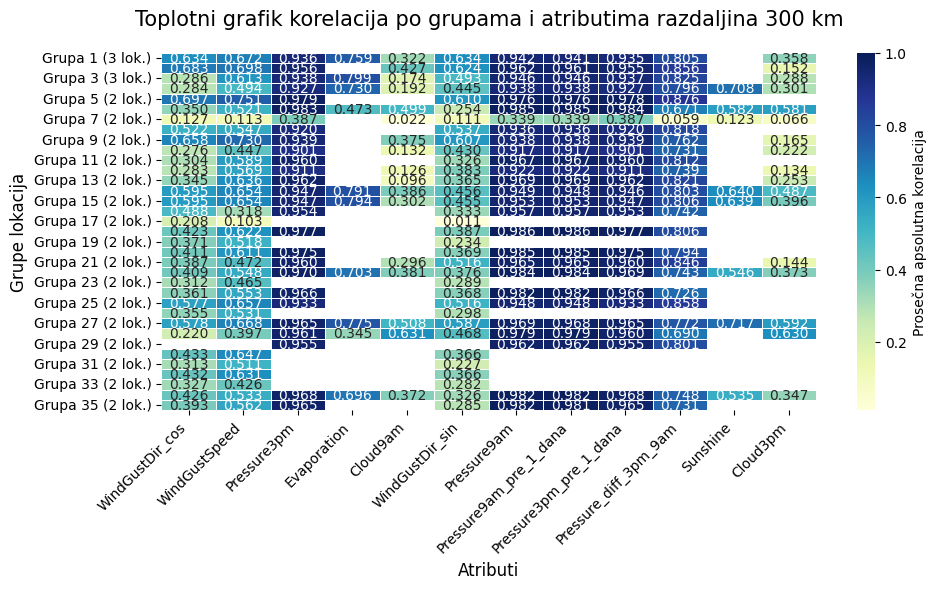

In [379]:
def generisi_matricu_korelacija_po_grupama_i_atributima(data, razdaljina, nedostajuci_atributi, pronadjene_grupe):
    data = data[data['Date'] < SPLIT_DATE]
    numericki_atributi = [x for x in set(nedostajuci_atributi) if x in data.select_dtypes(include=[np.number]).columns.tolist()]
    grupe = pronadjene_grupe.get(razdaljina, [])
    if not grupe:
        print(f"  Nema pronađenih grupa za razdaljinu {razdaljina} km. Preskačem...")
        return {}
    podaci_za_matricu = []


    rezultati = {}
    for i, grupa in enumerate(grupe):
        rezultati[";".join(grupa)] = {}
        ime_grupe = f"Grupa {i+1} ({len(grupa)} lok.)"
        red_podaci = {'Grupa': ime_grupe}
        
        df_grupa = data[data['Location'].isin(grupa)]
        
        # Računamo korelaciju za svaki numerički atribut
        for atribut in numericki_atributi:
            pivot = df_grupa.pivot(index='Date', columns='Location', values=atribut)
            corr_matrix = pivot.corr().abs()
            
            # Postavljamo glavnu dijagonalu na NaN kako ne bi veštački podigla prosek
            np.fill_diagonal(corr_matrix.values, np.nan)
            
            # Prosečna korelacija matrice (sada bez glavne dijagonale)
            mean_corr = corr_matrix.stack().mean(skipna=True)
            
            if pd.notna(mean_corr) and mean_corr >= 0.0:
                red_podaci[atribut] = mean_corr
                rezultati[";".join(grupa)][atribut] = mean_corr
            else:
                red_podaci[atribut] = np.nan
                rezultati[";".join(grupa)][atribut] = np.nan
        podaci_za_matricu.append(red_podaci)

    df_matrica = pd.DataFrame(podaci_za_matricu)
    df_matrica.set_index('Grupa', inplace=True)

    naziv_fajla = f'reports/claster_corelations/korelacije_po_grupama_i_atributima_razdljina_{razdaljina}.csv'
    df_matrica.to_csv(naziv_fajla)
    print(f"Matrica uspešno sačuvana kao '{naziv_fajla}'.\n")

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        df_matrica, 
        annot=True,    
        cmap='YlGnBu', 
        fmt=".3f",     
        linewidths=0.5,
        cbar_kws={'label': 'Prosečna apsolutna korelacija'},
        vmin=df_matrica.min().min(), 
        vmax=1.0,
    )

    plt.title(f'Toplotni grafik korelacija po grupama i atributima razdaljina {razdaljina} km', fontsize=15, pad=20)
    plt.xlabel('Atributi', fontsize=12)
    plt.ylabel('Grupe lokacija', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.show()
    return rezultati
kor = {}
for razdaljina in trazeni_pragovi:
    kor[str(razdaljina)] = generisi_matricu_korelacija_po_grupama_i_atributima(data, razdaljina, nedostajuci_atributi, pronadjene_grupe)


Primećujemo da prosečna korelacija između stanica u grupi dosledno opada sa povećanjem radijusa grupisanja, sa oko 0.89 (medijana 0.98) na 50km, preko 0.82 na 100km i 0.75 na 200km, do svega 0.66 (medijana 0.67) na 300km, očekivano, jer bliže stanice dele isti sinoptički sistem, dok udaljenije sve više odražavaju lokalnu klimu.

Efekat pritom nije isti za sve atribute. Pressure9am, Pressure3pm (i njihove lag i dnevna razlika varijante) i Sunshine ostaju izuzetno korelisani (>0.93) čak i na 300km, jer zavise od sinoptičkih sistema koji se prostiru na stotinama kilometara. Nasuprot tome, Cloud9am i Cloud3pm opadaju mnogo brže, već na najmanjem radijusu od 50km nijedna od 4 dostupne grupe ne dostiže korelaciju iznad 0.99 (maksimum je 0.982), dok kod Pressure9am sve 4 dostupne grupe prelaze taj prag. Ovo objašnjava zašto će u narednom odeljku (11.1.4) prostorna imputacija sa pragom korelacije >0.99 praktično uvek uspevati za Pressure i Sunshine, a retko ili nikad za Cloud atribute, za njih ćemo se osloniti prevashodno na Random Forest imputaciju (odeljak 11.2.2).

#### 11.1.3 Odabir modela za imputaciju

In [380]:
atributi_za_analizu = ['Evaporation', 'Sunshine', "Pressure9am", "Pressure3pm", "Cloud3pm", "Cloud9am"]
prazniElementiDictFiltered = {k:[a for a in v if a in atributi_za_analizu] for k,v in prazniElementiDict.items() if any(attr in v for attr in atributi_za_analizu)}
print(prazniElementiDictFiltered)

{'Adelaide': ['Cloud9am', 'Cloud3pm'], 'Albury': ['Evaporation', 'Sunshine'], 'BadgerysCreek': ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'], 'Ballarat': ['Evaporation', 'Sunshine'], 'Bendigo': ['Sunshine'], 'Dartmoor': ['Cloud9am', 'Cloud3pm'], 'GoldCoast': ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'], 'Katherine': ['Sunshine'], 'Launceston': ['Sunshine'], 'MountGinini': ['Evaporation', 'Sunshine', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm'], 'Newcastle': ['Evaporation', 'Sunshine', 'Pressure9am', 'Pressure3pm'], 'Nhil': ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'], 'NorahHead': ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'], 'PearceRAAF': ['Evaporation'], 'Penrith': ['Evaporation', 'Sunshine', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm'], 'Richmond': ['Sunshine'], 'SalmonGums': ['Evaporation', 'Sunshine', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm'], 'Tuggeranong': ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'], 'Uluru': ['Eva

Vidimo tačno koje lokacije nemaju podatke za koji od šest problematičnih atributa, na primer Adelaide nema oblačnost, a Albury nema ni Evaporation ni Sunshine. Ova lista će nam poslužiti kao ulaz za sledeći korak imputacije.

In [ ]:
FAJL_UDALJENOSTI = 'GeoPodaci/udaljenost_stanica.csv'

df = data.copy()
df_dist = pd.read_csv(FAJL_UDALJENOSTI)

df['Lon'] = pd.to_numeric(df['Lon'], errors='coerce')
df['Lat'] = pd.to_numeric(df['Lat'], errors='coerce')


istorija_rangova = {}


PONDERI = {
    'MAE': 0.40,  # Fokus na prosečnu apsolutnu grešku
    'RMSE': 0.40, # Fokus na kažnjavanje velikih odstupanja (outliera)
    'R2': 0.20    # Manja težina na koeficijent determinacije zbog manjih uzoraka
}

with open("reports/rezultati_analize_imputacionih_modela.txt", "w", encoding="utf-8") as f:
    
    for nedostajuci_atribut in atributi_za_analizu:
        CILJANI_ATRIBUT = nedostajuci_atribut
        lokacijeKojimaFaliAtribut = [lokacija for lokacija, atributi in prazniElementiDictFiltered.items() if CILJANI_ATRIBUT in atributi]

        istorija_rangova[CILJANI_ATRIBUT] = {
            'IDW': [], 'KNN': [], 'LinearRegression': [], 'RandomForest': [], 'XGBoost': []
        }

        for lokacije in pronadjene_grupe.get(50, []):
            if any(lokacija in lokacijeKojimaFaliAtribut for lokacija in lokacije):
                continue    
            
            MASKIRANA_STANICA = None
            for potencijalna_stanica in lokacije:
                if potencijalna_stanica in lokacijeKojimaFaliAtribut:
                    continue
                    
                if df[df['Location'] == potencijalna_stanica][CILJANI_ATRIBUT].count() > 10:
                    MASKIRANA_STANICA = potencijalna_stanica
                    break

            if MASKIRANA_STANICA is None:
                continue

            df_local = df[df['Location'].isin(lokacije)].copy()

            udaljenosti_dict = {}
            for _, row in df_dist.iterrows():
                par = tuple(sorted([row['stanica_1'], row['stanica_2']]))
                udaljenosti_dict[par] = row['razdaljina_km']

            maska_test_stanice = df_local['Location'] == MASKIRANA_STANICA
            df_original = df_local[maska_test_stanice][['Date', CILJANI_ATRIBUT]].copy()
            df_original.rename(columns={CILJANI_ATRIBUT: 'Stvarna_Vrednost'}, inplace=True)

            df_local.loc[maska_test_stanice, CILJANI_ATRIBUT] = np.nan

            donor_stanice = [s for s in lokacije if s != MASKIRANA_STANICA]
            df_donori = df_local[df_local['Location'].isin(donor_stanice)]

            dnevni_prosek = df_donori.groupby('Date')[CILJANI_ATRIBUT].mean().reset_index()
            dnevni_prosek.rename(columns={CILJANI_ATRIBUT: 'Prosek_Donora'}, inplace=True)

            df_local = df_local.merge(dnevni_prosek, on='Date', how='left')

            features = ['Lat', 'Lon', 'Nadmorska visina (m)', 'Prosek_Donora']

            df_train = df_local[df_local['Location'] != MASKIRANA_STANICA].dropna(subset=features + [CILJANI_ATRIBUT])

            X_train = df_train[features]
            y_train = df_train[CILJANI_ATRIBUT]

            df_test = df_local[df_local['Location'] == MASKIRANA_STANICA]
            df_test_clean = df_test.dropna(subset=features).copy() 
                
            X_test = df_test_clean[features]

            rezultati_predikcija = pd.merge(df_test_clean[['Date']], df_original, on='Date', how='left')

            idw_predikcije = []
            for index, row in df_test_clean.iterrows():
                datum = row['Date']
                donori_danas = df_train[df_train['Date'] == datum]
                
                if donori_danas.empty:
                    idw_predikcije.append(np.nan)
                    continue
                    
                tezine = []
                vrednosti = []
                for _, donor_row in donori_danas.iterrows():
                    donor_ime = donor_row['Location']
                    par = tuple(sorted([MASKIRANA_STANICA, donor_ime]))
                    dist = udaljenosti_dict.get(par, np.nan)
                    
                    if pd.notna(dist) and dist > 0:
                        tezine.append(1.0 / dist)
                        vrednosti.append(donor_row[CILJANI_ATRIBUT])
                        
                if np.sum(tezine) > 0:
                    idw_predikcije.append(np.average(vrednosti, weights=tezine))
                else:
                    idw_predikcije.append(np.nan)

            rezultati_predikcija['IDW'] = idw_predikcije

            if len(X_train) > 0:
                broj_komsija = max(1, min(4, len(X_train))) 
                knn = KNeighborsRegressor(n_neighbors=broj_komsija, weights='distance')
                knn.fit(X_train, y_train)
                rezultati_predikcija['KNN'] = knn.predict(X_test)

                lr = LinearRegression()
                lr.fit(X_train, y_train)
                rezultati_predikcija['LinearRegression'] = lr.predict(X_test)
            
                rf = RandomForestRegressor(n_estimators=100, random_state=42)
                rf.fit(X_train, y_train)
                rezultati_predikcija['RandomForest'] = rf.predict(X_test)

                xgboost = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
                xgboost.fit(X_train, y_train)
                rezultati_predikcija['XGBoost'] = xgboost.predict(X_test)
            else:
                print(f"Nema dovoljno podataka za trening ML modela (stanica: {MASKIRANA_STANICA})", file=f)
                continue

            print("\n" + "="*100, file=f)
            print(f"Evaluacija za atribut: {nedostajuci_atribut}", file=f)
            print(f"Evaluacija grupe: {lokacije}", file=f)
            print(f"Maskirana stanica: {MASKIRANA_STANICA}", file=f)
            print("="*100, file=f)
            
            donor_stanice_info = []
            for donor in donor_stanice:
                par = tuple(sorted([MASKIRANA_STANICA, donor]))
                dist = udaljenosti_dict.get(par, None)
                if pd.notna(dist):
                    donor_stanice_info.append(f"{donor} ({dist:.1f} km)")
                else:
                    donor_stanice_info.append(f"{donor} (N/A km)")

            print(f"Donor lokacije u grupi: {', '.join(donor_stanice_info)}", file=f)
            print("Atributi na osnovu kojih se vrši predikcija: " + ", ".join(features), file=f)
            print("-" * 100, file=f)

            modeli = ['IDW', 'KNN', 'LinearRegression', 'RandomForest', 'XGBoost']
            evaluacija = []

            rez_clean = rezultati_predikcija.dropna()
            y_true = rez_clean['Stvarna_Vrednost']

            if rez_clean.empty:
                print(f"Ne može se izračunati evaluacija, premalo preklapanja podataka.", file=f)
                continue

            for model in modeli:
                y_pred = rez_clean[model]
                mae = mean_absolute_error(y_true, y_pred)
                rmse = np.sqrt(mean_squared_error(y_true, y_pred))
                r2 = r2_score(y_true, y_pred)
                
                evaluacija.append({
                    'Model': model,
                    'MAE': mae,
                    'RMSE': rmse,
                    'R^2': r2
                })

            df_eval = pd.DataFrame(evaluacija)

            df_eval['MAE_inv'] = -df_eval['MAE']
            df_eval['RMSE_inv'] = -df_eval['RMSE']
            df_eval['R2_inv'] = df_eval['R^2'] 
            
            def min_max_scale(series):
                min_val = series.min()
                max_val = series.max()
                if max_val == min_val:
                    return pd.Series(1.0, index=series.index)
                return (series - min_val) / (max_val - min_val)
            
            df_eval['MAE_norm'] = min_max_scale(df_eval['MAE_inv'])
            df_eval['RMSE_norm'] = min_max_scale(df_eval['RMSE_inv'])
            df_eval['R2_norm'] = min_max_scale(df_eval['R2_inv'])
            
            df_eval['Score'] = (
                (df_eval['MAE_norm'] * PONDERI['MAE']) + 
                (df_eval['RMSE_norm'] * PONDERI['RMSE']) + 
                (df_eval['R2_norm'] * PONDERI['R2'])
            )
            
            df_eval['Rang'] = df_eval['Score'].rank(ascending=False, method='min').astype(int)

            for _, row in df_eval.iterrows():
                istorija_rangova[nedostajuci_atribut][row['Model']].append(row['Rang'])

            df_eval['MAE'] = df_eval['MAE'].round(4)
            df_eval['RMSE'] = df_eval['RMSE'].round(4)
            df_eval['R^2'] = df_eval['R^2'].round(4)
            df_eval['Score'] = df_eval['Score'].round(4)
            
            kolone_za_brisanje = ['MAE_inv', 'RMSE_inv', 'R2_inv', 'MAE_norm', 'RMSE_norm', 'R2_norm']
            df_eval = df_eval.drop(columns=kolone_za_brisanje)

            print(df_eval.to_string(), file=f)
            print("="*100, file=f)

    print("\n\n" + "#"*100, file=f)
    print("Finalni izveštaj: Prosečan rang modela po predviđanim atributima", file=f)
    print("#"*100, file=f)
    
    for atribut, modeli_dict in istorija_rangova.items():
        print(f"\nAnaliza za atribut: {atribut}", file=f)
        prosecni_rangovi = {}
        
        for model_ime, lista_rangova in modeli_dict.items():
            if len(lista_rangova) > 0:
                prosecni_rangovi[model_ime] = sum(lista_rangova) / len(lista_rangova)
            else:
                prosecni_rangovi[model_ime] = None
                
        prosecni_sortirani = sorted(
            [(m, r) for m, r in prosecni_rangovi.items() if r is not None], 
            key=lambda item: item[1]
        )
        
        if not prosecni_sortirani:
            print("  Nema dovoljno uspešnih predikcija za statistiku.", file=f)
        else:
            for i, (model, prosecan_rang) in enumerate(prosecni_sortirani, 1):
                print(f"  {i}. {model.ljust(18)} - Prosečan rang: {prosecan_rang:.2f}", file=f)
        print("-" * 50, file=f)

Rezultati ovog poređenja modela su sačuvani u izveštaju, a njihov zbirni zaključak sledi u narednom koraku gde biramo konačnu metodu imputacije za svaki atribut.

#### 11.1.4 Imputacija

Naredni kod vrši automatizovanu imputaciju potpuno nedostajućih podataka za pojedinačne lokacije, oslanjajući se na informacije iz njima srodnih meteoroloških stanica. Za svaki atribut čija merenja u potpunosti nedostaju na određenoj stanici, algoritam analizira podatke iz njene grupe i strogo proverava da li postoji visoka međusobna korelacija (iznad 0,99) za taj specifični parametar. Ukoliko je ovaj uslov pouzdanosti ispunjen, izračunava se prosečna dnevna vrednost na nivou cele grupe, koja se zatim ciljano upisuje samo na mesta gde podaci ne postoje.


--- Obrada atributa: Evaporation ---
[50 km] Započinjem popunjavanje...
Lokaciji MountGinini nedostaju svi podaci za atribut Evaporation. Trazim odgovarajuce grupe
Pronadjene su sledece grupe sa navedenim korelacijama:
  Grupa: ['MountGinini', 'Canberra', 'Tuggeranong'] - Prosečna korelacija: nan
Sve dostupne grupe imaju NaN ili None korelacije. Preskačem.

Lokaciji Tuggeranong nedostaju svi podaci za atribut Evaporation. Trazim odgovarajuce grupe
Pronadjene su sledece grupe sa navedenim korelacijama:
  Grupa: ['MountGinini', 'Canberra', 'Tuggeranong'] - Prosečna korelacija: nan
Sve dostupne grupe imaju NaN ili None korelacije. Preskačem.

Lokaciji NorahHead nedostaju svi podaci za atribut Evaporation. Trazim odgovarajuce grupe
Pronadjene su sledece grupe sa navedenim korelacijama:
  Grupa: ['NorahHead', 'Newcastle'] - Prosečna korelacija: nan
Sve dostupne grupe imaju NaN ili None korelacije. Preskačem.

Lokaciji Newcastle nedostaju svi podaci za atribut Evaporation. Trazim odgovaraju

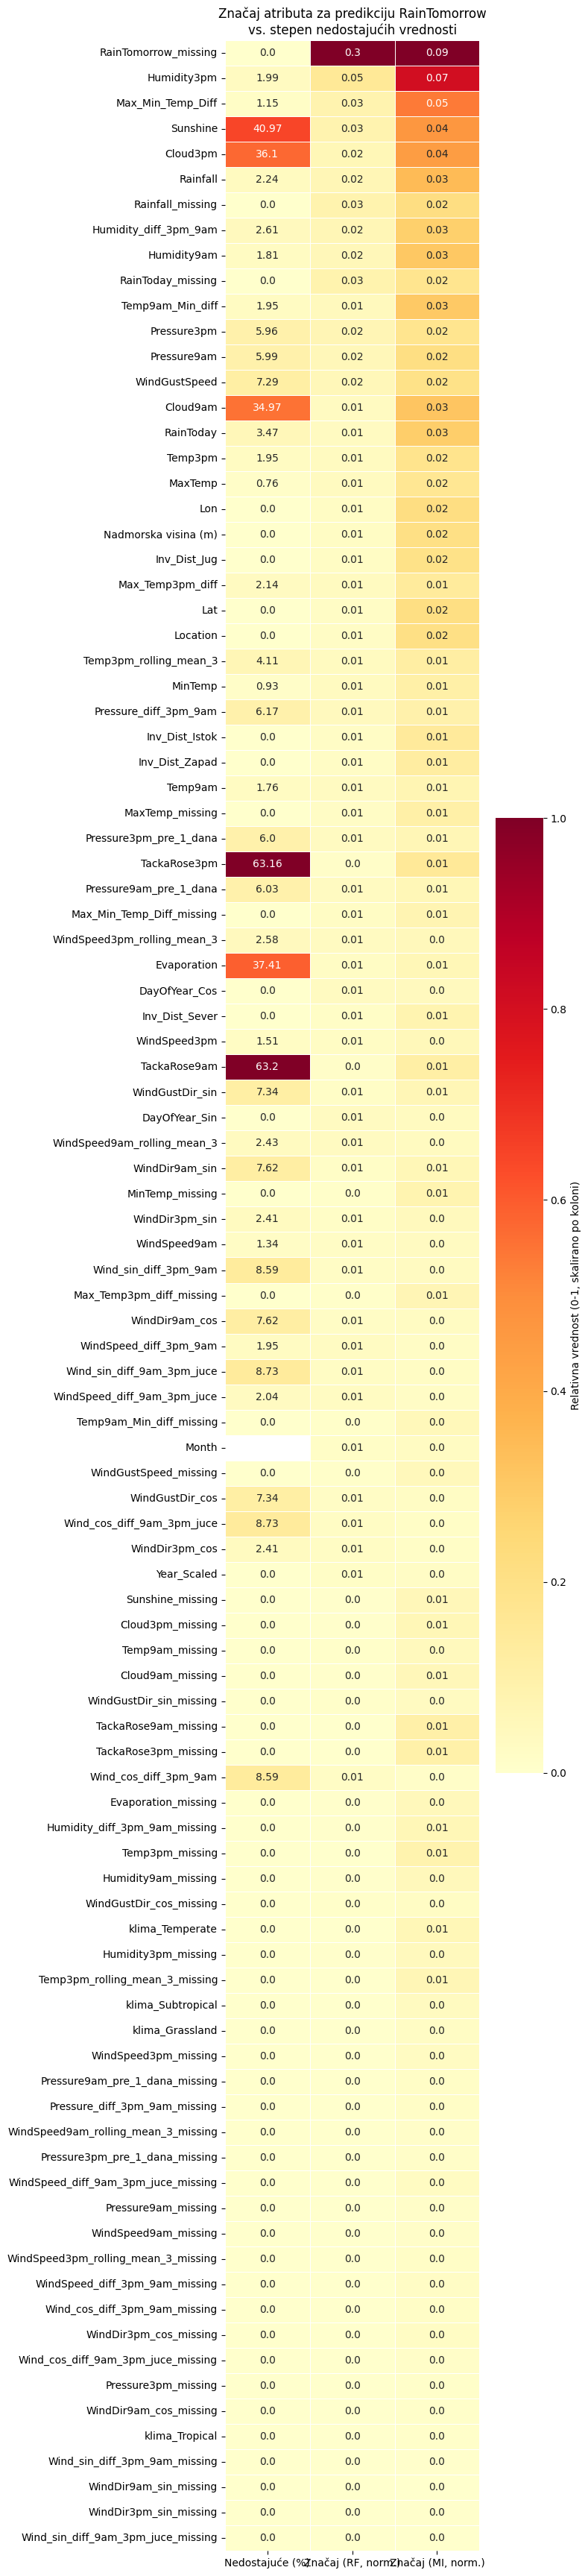

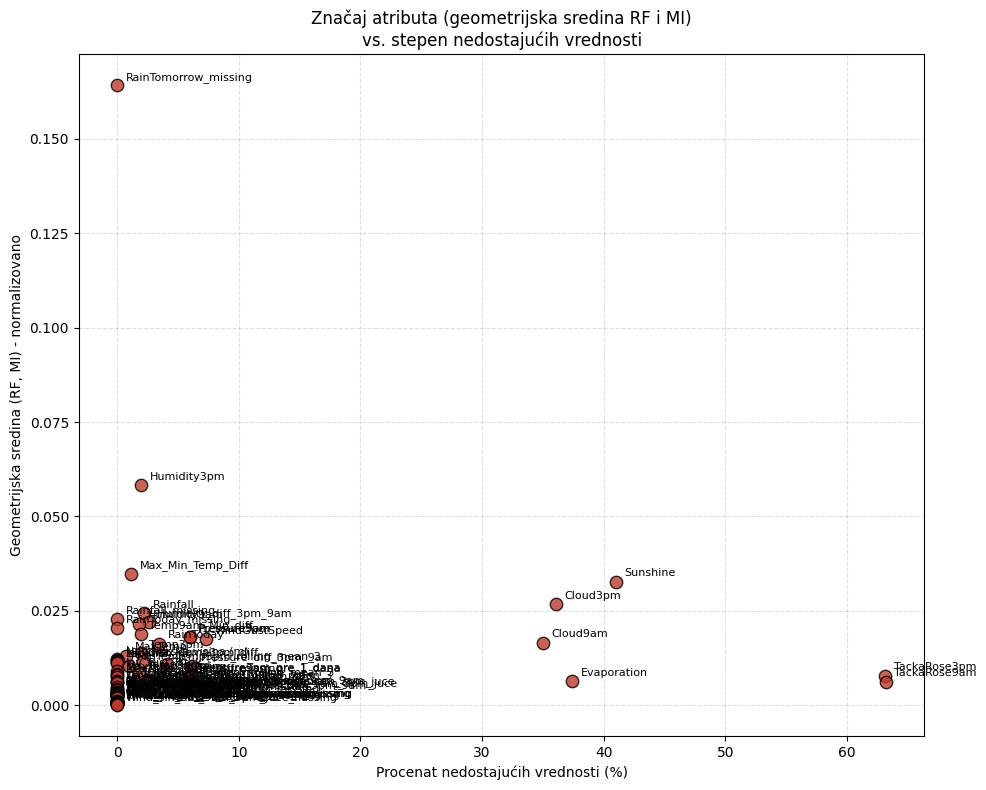

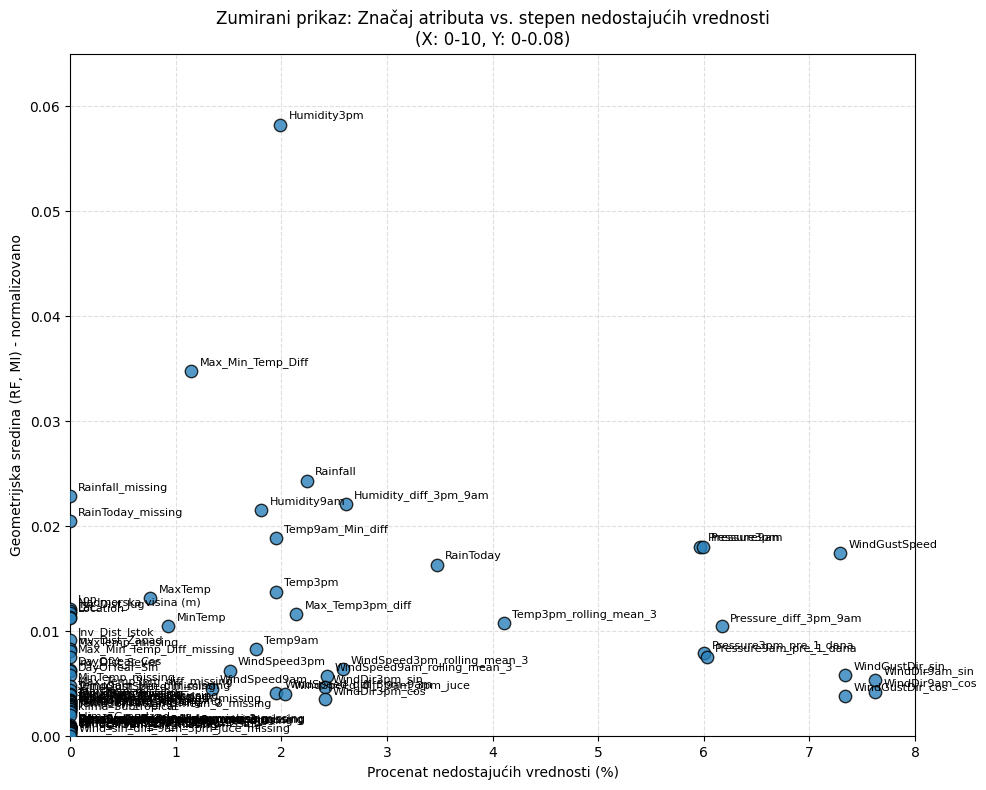

In [391]:
old_df = data.copy()
def popuni_po_grupama(df, grupe, atribut, min_corr, korelacije):
    df_copy = df.copy()
    

    uspesanXGBoost = 0
    neuspesanXGBoost = 0
    kljucevi = korelacije.keys() if korelacije else []
    
    udaljenosti_dict = {}
    if atribut not in ['Cloud3pm', 'Cloud9am']:
        df_dist = pd.read_csv('GeoPodaci/udaljenost_stanica.csv')
            
        for _, row in df_dist.iterrows():
            par = tuple(sorted([row['stanica_1'], row['stanica_2']]))
            udaljenosti_dict[par] = row['razdaljina_km']
    
    for grupa in grupe:
        
        df_local = df_copy[df_copy['Location'].isin(grupa)]
        if df_local.empty:
            continue
            
        for loc in grupa:
            maska_lokacija = (df_copy['Location'] == loc)
            ukupno_merenja = maska_lokacija.sum()
            
            maska_nedostajuci = maska_lokacija & (df_copy[atribut].isna())
            nedostaje_merenja = maska_nedostajuci.sum()
            
            if nedostaje_merenja > 0 and nedostaje_merenja == ukupno_merenja:
                print(f"Lokaciji {loc} nedostaju svi podaci za atribut {atribut}. Trazim odgovarajuce grupe")
                odgovrajacuciKljucevi = [k for k in kljucevi if loc in k.split(';')]
                if not odgovrajacuciKljucevi:
                    print(f"Nema odgovarajućih grupa za lokaciju {loc} i atribut {atribut}. Preskačem.\n")
                    continue
                else:
                    validni_kljucevi = []
                    print("Pronadjene su sledece grupe sa navedenim korelacijama:")
                    for k in odgovrajacuciKljucevi:
                        print(f"  Grupa: {k.split(';')} - Prosečna korelacija: {korelacije[k].get(atribut, 0):.4f}")
                        if korelacije[k].get(atribut, 0) is not None and not np.isnan(korelacije[k].get(atribut, 0)):
                            validni_kljucevi.append(k)
                    if not validni_kljucevi:
                        print("Sve dostupne grupe imaju NaN ili None korelacije. Preskačem.\n")
                        continue
                    najbolja_grupa_kljuc = max(validni_kljucevi, key=lambda k: korelacije[k].get(atribut, 0))
                    if korelacije[najbolja_grupa_kljuc].get(atribut, 0) is None or np.isnan(korelacije[najbolja_grupa_kljuc].get(atribut, 0)):
                        print(f"Prosečna korelacija za grupu {najbolja_grupa_kljuc.split(';')} je NaN. Preskačem.\n")
                        continue
                    grupa = najbolja_grupa_kljuc.split(';')
                    print(f"Odabrao sam grupu: {grupa} sa prosečnom korelacijom {korelacije[najbolja_grupa_kljuc].get(atribut, 0):.4f}")
                    if korelacije[najbolja_grupa_kljuc].get(atribut, 0) < min_corr:
                        print(f"Prosečna korelacija {korelacije[najbolja_grupa_kljuc].get(atribut, 0):.4f} je ispod praga {min_corr}. Preskačem.\n")
                        continue
                
                donori = [d for d in grupa if d != loc]
                if not donori:
                    continue
                
                if atribut in ['Cloud3pm', 'Cloud9am']:
                    df_donori = df_copy[df_copy['Location'].isin(donori)][['Date', atribut]]
                    dnevni_prosek = df_donori.groupby('Date')[atribut].mean().reset_index()
                    dnevni_prosek.rename(columns={atribut: 'Prosek_Donora'}, inplace=True)
                    
                    temp_df = df_local.merge(dnevni_prosek, on='Date', how='left')
                    
                    features = ['Lat', 'Lon', 'Nadmorska visina (m)', 'Prosek_Donora']
                    
                    df_train = temp_df[(temp_df['Location'] != loc) & (temp_df['Date'] < SPLIT_DATE)].dropna(subset=features + [atribut])
                    
                    df_pred = temp_df[(temp_df['Location'] == loc) & (temp_df[atribut].isna())]
                    
                    if len(df_train) > 10 and not df_pred.empty:
                        X_train = df_train[features]
                        y_train = df_train[atribut]
                        X_pred = df_pred[features]
                        
                        model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
                        model.fit(X_train, y_train)
                        preds = model.predict(X_pred)
                        
                        datumi_za_upis = df_pred['Date'].values
                        df_copy.loc[(df_copy['Location'] == loc) & (df_copy['Date'].isin(datumi_za_upis)), atribut] = preds
                        
                        print(f"  -> Primenjen XGBoost za {loc}\n")
                        uspesanXGBoost += 1
                    else:
                        print(f"  -> Nema dovoljno validnih redova za XGBoost obuku (stanica: {loc})\n")
                        neuspesanXGBoost += 1
                        
                else:
                    podaci_idw = df_local[['Date', 'Location', atribut]]
                    pivot = podaci_idw.pivot(index='Date', columns='Location', values=atribut)
                    
                    if loc not in pivot.columns:
                        continue
                        
                    datumi_fale = df_copy[maska_nedostajuci]['Date']
                    
                    for datum in datumi_fale:
                        if datum not in pivot.index:
                            continue
                            
                        row_data = pivot.loc[datum]
                        donori_dostupni = [d for d in donori if d in row_data.index and pd.notna(row_data[d])]
                        
                        if not donori_dostupni:
                            continue
                            
                        tezine = []
                        vrednosti = []
                        for donor in donori_dostupni:
                            par = tuple(sorted([loc, donor]))
                            dist = udaljenosti_dict.get(par, np.nan)
                            
                            if pd.notna(dist) and dist > 0:
                                tezine.append(1.0 / dist)
                                vrednosti.append(row_data[donor])
                                
                        if tezine and np.sum(tezine) > 0:
                            procenjena_vrednost = np.average(vrednosti, weights=tezine)
                            # Upis precizno u red za tu lokaciju i taj datum
                            df_copy.loc[(df_copy['Location'] == loc) & (df_copy['Date'] == datum), atribut] = procenjena_vrednost
                    
                    print(f"  -> Primenjen IDW za {loc}\n")

    print("\nUspesan XGBoost popunjavanja:", uspesanXGBoost)
    print("Neuspesan XGBoost popunjavanja:", neuspesanXGBoost)
    
    return df_copy
for atribut in atributi_za_analizu:
    nedostajuci_count_pocetak = data[atribut].isna().sum()
    print(f"\n{'='*40}")
    print(f"--- Obrada atributa: {atribut} ---")
    print(f"{'='*40}")
    
    # 1. Prvi prolaz - pokušaj popunjavanja sa grupama do 50 km
    print("[50 km] Započinjem popunjavanje...")
    data = popuni_po_grupama(
        data,  
        pronadjene_grupe.get(50, []), 
        atribut, 
        0.95, 
        kor.get("50", {})
    )
    
    preostalo_nedostajucih = data[atribut].isna().sum()
    
    if preostalo_nedostajucih > 0:
        print(f"\n[info] Ostalo je {preostalo_nedostajucih} nedostajućih vrednosti za {atribut}.")
        print("[100 km] Pokrećem prošireno popunjavanje...")
        data = popuni_po_grupama(
            data, 
            pronadjene_grupe.get(100, []), 
            atribut, 
            0.95, 
            kor.get("100", {})
        )
        
        # Opciono: Ispis koliko je ostalo nakon 100 km
        konacno_nedostaje = data[atribut].isna().sum()
        print(f"\nNa pocetku bilo je {nedostajuci_count_pocetak} nedostajućih vrednosti za {atribut}.")
        print(f"Nakon 50km bilo je {preostalo_nedostajucih} nedostajućih vrednosti za {atribut}.")
        if konacno_nedostaje > 0:
            print(f"I nakon 100 km ostalo je {konacno_nedostaje} nedostajućih vrednosti.")
        else:
            print(f"Sve preostale vrednosti su uspešno popunjene sa 100 km.")
            
    else:
        print(f"\nSve vrednosti za {atribut} su uspešno popunjene u krugu od 50 km.")
    write_log(data, "Popunjen atribut " + atribut, None)
print("Imputacija je gotova, kreiramo grafike da proverimo koliko se podataka popunilo")
data = createVaribales(data)
write_log(data, "Imputirani svi potpuno nedostajuci atributi", "weatherAusAfter11_1_4.csv")
kreirajAnalizu()

Vidimo kako algoritam za svaku lokaciju kojoj potpuno nedostaje neki atribut prvo traži najbolju grupu susednih stanica sa dovoljno visokom korelacijom, kao što je urađeno za MountGinini i Evaporation, pre nego što izvrši samu imputaciju.

### 11.2 Nasumicno nedostajuce vrednosti

#### 11.2.1 Analiza raspodele

Analizirani dataset karakteriše značajan broj nedostajućih podataka. Prikazimo broj nedostajucih vrednosti za svaku kolonu.
Sortiranje je izvršeno u rastućem redosledu, polazeći od pretpostavke da će broj nedostajućih podataka po koloni opredeliti redosled kasnije imputacije.

In [394]:
data = loadData("backups/weatherAusAfter11_1_4.csv")
originalDF = loadData("InputData/weatherAUS.csv")

originalCols = [x for x in data.columns if x in originalDF.columns]

print(originalCols)
print(data.isna().sum().sort_values(ascending=True))

C:\Users\lukab\AppData\Local\Temp\ipykernel_15912\1734082743.py:2: DtypeWarning: Columns (56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(fileName)


['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']
Date                 0
Location             0
DayOfYear_Cos        0
DayOfYear_Sin        0
Year_Scaled          0
                 ...  
Cloud3pm         56277
Evaporation      59753
Sunshine         66768
TackaRose3pm     89167
TackaRose9am     89256
Length: 100, dtype: int64


Pored nedostajucih podataka po kolonama, pogledajmo i broj nedostajucih podataka po vrstama.

In [395]:
missing_counts = data[originalCols].isna().sum(axis=1)

counts = missing_counts.value_counts().sort_index()

print(counts)

0     58652
1     15030
2     15572
3     10130
4     32180
5      4690
6      5069
7       978
8       542
9      1038
10      299
11      104
12       91
13      536
14      108
15       59
16      117
17        8
18      140
Name: count, dtype: int64


Primecujemo da postoji odredjeni broj vrsta u kojima fali i do 19 podataka. Ako uzmemo u obzir da dataset ukupno ima 24 kolone i da su od toga barem tri kolone neophodne za rad (bez nedostajucih vrednosti), dolazimo do zaključka da one vrste u kojima nam fali veliki broj podataka treba obrisati.

In [396]:
POTREBAN_BROJ_PODATAKA_U_REDU = 15
data = data.dropna(subset=originalCols,thresh=POTREBAN_BROJ_PODATAKA_U_REDU)
print(data.isna().sum().sort_values(ascending=True))


write_log(data, "Brisanje vrsta sa velikim brojem nedostajucih vrednosti", "WatherAus_After_11_2_1.csv")


Date                 0
Location             0
DayOfYear_Cos        0
DayOfYear_Sin        0
Year_Scaled          0
                 ...  
Cloud3pm         47774
Evaporation      51810
Sunshine         58458
TackaRose3pm     82258
TackaRose9am     82344
Length: 100, dtype: int64


Nakon brisanja redova sa previše nedostajućih vrednosti, preostale kolone i dalje imaju znatan broj praznina, najviše kod TackaRose9am i TackaRose3pm sa preko 82.000, zatim Sunshine i Evaporation, koje ćemo popuniti u narednim koracima.

#### 11.2.2 Metode imputacije

U nastavku se nalaze dve metode za imputaciju nasumično nedostajućih vrednosti (za razliku od odeljka 11.1, gde su vrednosti u potpunosti nedostajale na nivou cele stanice), Random Forest regresija, koja za predviđanje nedostajuće vrednosti koristi meteorološki i geografski povezane prediktore iz istog reda, i ponderisani prosek po inverznoj udaljenosti (IDW), koji se oslanja isključivo na istovremena očitavanja sa obližnjih stanica.

Izbor metode po atributu zavisi od prirode fizičke veličine. IDW je pogodniji za atribute koji se prostorno menjaju postepeno i bez naglih lokalnih oscilacija (na primer atmosferski pritisak, videćemo ga u primeni kod Pressure9am i Pressure3pm), dok se Random Forest koristi kada je zavisnost od ostalih merenja na istoj stanici jača od prostorne zavisnosti, ili kada za dati atribut ne postoji dovoljno gusta mreža obližnjih stanica sa istovremenim očitavanjima.

##### 11.2.2.1 Random forest

In [ ]:

core_features = ["Nadmorska visina (m)","Inv_Dist_Sever","Inv_Dist_Jug","Inv_Dist_Istok","Inv_Dist_Zapad",
"klima_Grassland","klima_Subtropical","klima_Temperate","klima_Tropical"]
def imputeData(target_attr, df, prediktori, stvarnaImputacija = False, backupName=None):
    broj_nedostajucih = df[target_attr].isna().sum()
    if broj_nedostajucih == 0:
        print(f"Kolona '{target_attr}' nema nedostajućih vrednosti. Imputacija nije potrebna.")
        return df
    proc_nedostajucih = (df[target_attr].isna().sum() / len(df)) * 100
    global core_features

    
    prediktori = list(dict.fromkeys(prediktori + core_features))
    poznati_df = df[df[target_attr].notna() & (df['Date'] < SPLIT_DATE)].copy()
    nedostajuci_df = df[df[target_attr].isna()].copy()

   
    imputer = SimpleImputer(strategy='median')
    X_poznati = imputer.fit_transform(poznati_df[prediktori])
    y_poznati = poznati_df[target_attr].values

    metrics = {'mae': [], 'rmse': [], 'r2': [], 'adj_r2': []}

    for i in range(5):
        X_train, X_test, y_train, y_test = train_test_split(
            X_poznati, y_poznati, test_size=0.1, random_state=i
        )
        
        rf = RandomForestRegressor(n_estimators=100, random_state=i, n_jobs=-1)
        rf.fit(X_train, y_train)
        
        y_pred = rf.predict(X_test)
        
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
        n = len(y_test)
        p = X_test.shape[1]
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
        
        metrics['mae'].append(mae)
        metrics['rmse'].append(rmse)
        metrics['r2'].append(r2)
        metrics['adj_r2'].append(adj_r2)

    avg_mae = np.mean(metrics['mae'])
    avg_rmse = np.mean(metrics['rmse'])
    avg_r2 = np.mean(metrics['r2'])
    avg_adj_r2 = np.mean(metrics['adj_r2'])

    spisak_ocena = f"MAE={avg_mae:.4f}, RMSE={avg_rmse:.4f}, R2={avg_r2:.4f}, Adj R2={avg_adj_r2:.4f}, postoji {proc_nedostajucih:.2f}% nedostjucih podaataka u koloni"

    poruka = f"imputirani nedostajući podaci za \natribut {target_attr}, \nmetoda RF, \nprediktori: {', '.join(prediktori)}, \nstatističke ocene: {spisak_ocena}"

    print("--- Evaluacija završena ---")
    print(poruka)
    print("---------------------------\n")

    if stvarnaImputacija:
        rf_final = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf_final.fit(X_poznati, y_poznati)

        X_nedostajuci = imputer.transform(nedostajuci_df[prediktori])

        imputirane_vrednosti = rf_final.predict(X_nedostajuci)

        noviDF = df.copy()
        noviDF.loc[noviDF[target_attr].isna(), target_attr] = imputirane_vrednosti
        proc_nedostajucih_sad = (noviDF[target_attr].isna().sum() / len(noviDF)) * 100
        print(f"Stvarna imputacija zavrsena, u koloni sada ima {proc_nedostajucih_sad}% nedostajucih podataka")
        write_log(noviDF, poruka, backupName)
        noviDF = createVaribales(noviDF)
        return noviDF
    return df

Ova funkcija će za svaki atribut trenirati Random Forest model na trening delu i njome popuniti nedostajuće vrednosti, uz evaluaciju kroz unakrsnu validaciju pre same imputacije.

##### 11.2.2.2 Ponderisani prosek (inverzna udaljenost)
Naredni kod koristi metodu ponderisanog proseka, odnosno inverznu udaljenost, za popunjavanje nedostajućih vrednosti. Ovaj prostorni pristup se oslanja na podatke sa susednih mernih stanica, dajući veću težinu onim stanicama koje su fizički bliže. Ovo je dobro rešenje za imputiranje nedostajućih vrednosti za atmosferski pritisak jer je to meteorološka varijabla koja se menja postepeno na širem geografskom području i ne pokazuje nagle lokalne oscilacije. Zbog prirodne prostorne korelacije, očitavanja sa obližnjih stanica su izuzetno pouzdani indikatori stanja na ciljnoj lokaciji. U slučajevima gde postoje adekvatni podaci u okolini, ova metoda ostvaruje visoke rezultate i veoma precizno preslikava stvarno stanje na terenu.

In [398]:
def imputeData_IDW(target_attr, df, df_dist, max_dist, stvarnaImputacija=False, backupName=None):
    proc_nedostajucih = df[target_attr].isna().sum()
    
    print("Pravljenje rečnika prostornih udaljenosti...")
    dist_dict = {}
    for _, row in df_dist.iterrows():
        s1, s2, d = row['stanica_1'], row['stanica_2'], row['razdaljina_km']
        if d <= max_dist:
            dist_dict.setdefault(s1, {})[s2] = d
            dist_dict.setdefault(s2, {})[s1] = d

    def dobiji_susede(stanica, datum, lookup_dict):
        susedi_info = dist_dict.get(stanica, {})
        validni_susedi = []
        for sused, dist in susedi_info.items():
           
            vrednost_suseda = lookup_dict.get((sused, datum))
            if vrednost_suseda is not None and pd.notnull(vrednost_suseda):
                validni_susedi.append({
                    'value': vrednost_suseda,
                    'distance': dist
                })
        return validni_susedi

    poznati_indeksi = df[df[target_attr].notna()].index
    nedostajuci_indeksi = df[df[target_attr].isna()].index

    metrics = {'mae': [], 'rmse': [], 'r2': [], 'adj_r2': []}

    print("Započinjem evaluaciju (5 iteracija)...")
    for i in range(5):
        np.random.seed(i)
        
        test_size = int(0.1 * len(poznati_indeksi))
        test_indeksi = np.random.choice(poznati_indeksi, size=test_size, replace=False)
        train_indeksi = poznati_indeksi.difference(test_indeksi)

        df_train = df.loc[train_indeksi]
        train_lookup = df_train.set_index(['Location', 'Date'])[target_attr].to_dict()
        y_test = []
        y_pred = []

        for idx in test_indeksi:
            red = df.loc[idx]
            susedi = dobiji_susede(red['Location'], red['Date'], train_lookup)
            
            if not susedi:
                continue
            
            vrednosti = [s['value'] for s in susedi]
            udaljenosti = [s['distance'] for s in susedi]
            tezine = [1.0 / (d + 1e-6) for d in udaljenosti]
            
            y_pred.append(np.average(vrednosti, weights=tezine))
            y_test.append(red[target_attr])

        if len(y_test) > 0:
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            
            n = len(y_test)
            p = 1 
            adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else np.nan
            
            metrics['mae'].append(mae)
            metrics['rmse'].append(rmse)
            metrics['r2'].append(r2)
            metrics['adj_r2'].append(adj_r2)
    ukupno_nedostajucih = len(nedostajuci_indeksi)
    broj_popunjivih = 0
    

    full_lookup = df.set_index(['Location', 'Date'])[target_attr].to_dict()
    
    if ukupno_nedostajucih > 0:
        for idx in nedostajuci_indeksi:
            red = df.loc[idx]
            if dobiji_susede(red['Location'], red['Date'], full_lookup):
                broj_popunjivih += 1
        proc_popunjivih = (broj_popunjivih / ukupno_nedostajucih) * 100
    else:
        proc_popunjivih = 0.0

    if metrics['mae']:
        avg_mae = np.mean(metrics['mae'])
        avg_rmse = np.mean(metrics['rmse'])
        avg_r2 = np.mean(metrics['r2'])
        avg_adj_r2 = np.mean(metrics['adj_r2'])
        spisak_ocena = (f"MAE={avg_mae:.4f}, RMSE={avg_rmse:.4f}, R2={avg_r2:.4f}, Adj R2={avg_adj_r2:.4f}, "
                        f"početno nedostajućih={proc_nedostajucih:.2f} od cega je moguće popuniti={proc_popunjivih:.2f}%")
    else:
        spisak_ocena = "Evaluacija nemoguća (nema dovoljno validnih suseda u blizini)"

    poruka = f"Imputirani nedostajući podaci \natribut: {target_attr}), \nmetoda: Ponderisani prosek (Inverzna udaljenost, max_dist={max_dist}), \nocene: {spisak_ocena}"

    print("--- Evaluacija završena ---")
    print(poruka)
    print("---------------------------\n")

    if stvarnaImputacija:
        noviDF = df.copy()
        print("Započinjem stvarnu imputaciju podataka...")

        for idx in nedostajuci_indeksi:
            red = df.loc[idx]
            susedi = dobiji_susede(red['Location'], red['Date'], full_lookup)
            
            if susedi:
                vrednosti = [s['value'] for s in susedi]
                udaljenosti = [s['distance'] for s in susedi]
                tezine = [1.0 / (d + 1e-6) for d in udaljenosti]
                noviDF.at[idx, target_attr] = np.average(vrednosti, weights=tezine)
        write_log(noviDF, poruka, backupName)
        noviDF = createVaribales(noviDF)
        return noviDF

    return df

razdaljine_df = pd.read_csv("GeoPodaci/udaljenost_stanica.csv")


Ova funkcija radi po istom principu ponderisanog proseka koji smo već koristili u odeljku 11.1, samo primenjenom na nasumično nedostajuće vrednosti.

#### 11.2.3 Imputacija nedostajucih podataka

U nastavku će biti sprovedena sukcesivna imputacija nedostajućih vrednosti za sledeći skup atributa, MinTemp, MaxTemp, Temp9am, Temp3pm, Pressure9am, Pressure3pm, Humidity9am i Sunshine.

Redosled kojim se imputacija vrši strogo je logičan i uslovljen prirodom meteoroloških podataka, odnosno njihovom hronološkom i uzročno-posledičnom zavisnošću.

Za popunjavanje vrednosti svakog pojedinačnog atributa pozivaće se prethodno definisane funkcije za imputaciju. Pri svakom pozivu, ovim funkcijama će se prosleđivati isključivo specifični prediktori koji su najrelevantniji za taj konkretan atribut. Sa druge strane, univerzalni prediktori, koji se odnose na geografske i klimatske odlike pojedinačne merne stanice, već su ugrađeni u samu logiku funkcije za imputaciju, čime je obezbeđena konzistentnost i izbegnuto redundatno prosleđivanje argumenata.

##### 11.2.3.1 MinTemp


In [400]:
data = loadData("backups/WatherAus_After_11_2_1.csv")
data = imputeData("MinTemp",data, ['Temp3pm_rolling_mean_3','Pressure9am', 'Temp9am', 
                                   'Temp3pm', 'Year_Scaled', 'DayOfYear_Sin', 'DayOfYear_Cos',
                                     'WindSpeed9am', 'Humidity9am'], True, "WeatherAus_After_11_2_1_1.csv")


C:\Users\lukab\AppData\Local\Temp\ipykernel_15912\1734082743.py:2: DtypeWarning: Columns (56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(fileName)


--- Evaluacija završena ---
imputirani nedostajući podaci za 
atribut MinTemp, 
metoda RF, 
prediktori: Temp3pm_rolling_mean_3, Pressure9am, Temp9am, Temp3pm, Year_Scaled, DayOfYear_Sin, DayOfYear_Cos, WindSpeed9am, Humidity9am, Nadmorska visina (m), Inv_Dist_Sever, Inv_Dist_Jug, Inv_Dist_Istok, Inv_Dist_Zapad, klima_Grassland, klima_Subtropical, klima_Temperate, klima_Tropical, 
statističke ocene: MAE=1.2914, RMSE=1.6933, R2=0.9295, Adj R2=0.9294, postoji 0.08% nedostjucih podaataka u koloni
---------------------------

Stvarna imputacija zavrsena, u koloni sada ima 0.0% nedostajucih podataka


Imputacija za MinTemp je izvršena Random Forest metodom uz prediktore poput temperature u okolnim terminima, pritiska i sezonskih obeležja.

##### 11.2.3.2 MaxTemp

In [402]:
data = imputeData("MaxTemp",data, 
                  ['Temp3pm_rolling_mean_3','Pressure3pm', 'Temp9am', 
                   'Temp3pm', 'Year_Scaled', 'DayOfYear_Sin', 
                   'DayOfYear_Cos', 'WindSpeed3pm', 'Humidity3pm'], True,
                   "WeatherAus_After_11_2_1_2.csv")

--- Evaluacija završena ---
imputirani nedostajući podaci za 
atribut MaxTemp, 
metoda RF, 
prediktori: Temp3pm_rolling_mean_3, Pressure3pm, Temp9am, Temp3pm, Year_Scaled, DayOfYear_Sin, DayOfYear_Cos, WindSpeed3pm, Humidity3pm, Nadmorska visina (m), Inv_Dist_Sever, Inv_Dist_Jug, Inv_Dist_Istok, Inv_Dist_Zapad, klima_Grassland, klima_Subtropical, klima_Temperate, klima_Tropical, 
statističke ocene: MAE=0.6221, RMSE=0.8971, R2=0.9835, Adj R2=0.9834, postoji 0.07% nedostjucih podaataka u koloni
---------------------------

Stvarna imputacija zavrsena, u koloni sada ima 0.0% nedostajucih podataka


Isti postupak je primenjen i za MaxTemp, sa prediktorima prilagođenim popodnevnim merenjima.

##### 11.2.3.3 Temp9am

In [403]:
data = imputeData("Temp9am",data, 
                  ['Temp3pm_rolling_mean_3','Pressure3pm', 'MinTemp', 
                   'Temp3pm', 'Year_Scaled', 'DayOfYear_Sin', 'DayOfYear_Cos', 
                   'WindSpeed3pm', 'Humidity3pm'], True,
                   "WeatherAus_After_11_2_1_3.csv")

--- Evaluacija završena ---
imputirani nedostajući podaci za 
atribut Temp9am, 
metoda RF, 
prediktori: Temp3pm_rolling_mean_3, Pressure3pm, MinTemp, Temp3pm, Year_Scaled, DayOfYear_Sin, DayOfYear_Cos, WindSpeed3pm, Humidity3pm, Nadmorska visina (m), Inv_Dist_Sever, Inv_Dist_Jug, Inv_Dist_Istok, Inv_Dist_Zapad, klima_Grassland, klima_Subtropical, klima_Temperate, klima_Tropical, 
statističke ocene: MAE=1.0486, RMSE=1.4101, R2=0.9522, Adj R2=0.9521, postoji 0.65% nedostjucih podaataka u koloni
---------------------------

Stvarna imputacija zavrsena, u koloni sada ima 0.0% nedostajucih podataka


Temp9am je imputiran na sličan način, koristeći MinTemp i popodnevne vrednosti kao dodatne prediktore.

##### 11.2.3.4 Temp3pm

In [404]:
data = imputeData("Temp3pm",data, 
                  ['Temp3pm_rolling_mean_3','Pressure3pm', 'MinTemp', 
                   'Temp9am', 'Year_Scaled', 'DayOfYear_Sin', 'DayOfYear_Cos', 
                   'WindSpeed3pm', 'Humidity3pm'], True,
                   "WeatherAus_After_11_2_1_4.csv")


--- Evaluacija završena ---
imputirani nedostajući podaci za 
atribut Temp3pm, 
metoda RF, 
prediktori: Temp3pm_rolling_mean_3, Pressure3pm, MinTemp, Temp9am, Year_Scaled, DayOfYear_Sin, DayOfYear_Cos, WindSpeed3pm, Humidity3pm, Nadmorska visina (m), Inv_Dist_Sever, Inv_Dist_Jug, Inv_Dist_Istok, Inv_Dist_Zapad, klima_Grassland, klima_Subtropical, klima_Temperate, klima_Tropical, 
statističke ocene: MAE=1.1618, RMSE=1.5538, R2=0.9485, Adj R2=0.9484, postoji 1.32% nedostjucih podaataka u koloni
---------------------------

Stvarna imputacija zavrsena, u koloni sada ima 0.0% nedostajucih podataka


Ovim smo završili imputaciju sve četiri temperaturske kolone istim Random Forest pristupom.

##### 11.2.3.5 Pressure9am

a) Ponderisani prosek 

In [405]:
data = loadData("backups/WeatherAus_After_11_2_1_4.csv")
data = imputeData_IDW("Pressure9am", data, razdaljine_df, 150, True,
                    "WeatherAus_After_11_2_1_5a.csv")

C:\Users\lukab\AppData\Local\Temp\ipykernel_15912\1734082743.py:2: DtypeWarning: Columns (56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(fileName)


Pravljenje rečnika prostornih udaljenosti...
Započinjem evaluaciju (5 iteracija)...
--- Evaluacija završena ---
Imputirani nedostajući podaci 
atribut: Pressure9am), 
metoda: Ponderisani prosek (Inverzna udaljenost, max_dist=150), 
ocene: MAE=0.4408, RMSE=0.6483, R2=0.9917, Adj R2=0.9917, početno nedostajućih=3036.00 od cega je moguće popuniti=68.21%
---------------------------

Započinjem stvarnu imputaciju podataka...


b) Random forest 

Iako upotreba ponderisnog proseka daje odlične rezultate, ova metoda ne može da popuni apsolutno sve nedostajuće podatke. Zbog strogog oslanjanja na prostornu blizinu, algoritam neće moći da izvrši imputaciju u situacijama kada u definisanom maksimalnom radijusu nema drugih mernih stanica, ili kada susedne stanice takođe nemaju zabeležena očitavanja za taj konkretan dan. Kako bismo osigurali potpuno popunjen skup podataka, preostale vrednosti koje su ostale neimputirane biće rešene primenom Random Forest modela, po potpuno istom principu kao što je to rađeno i u ostalim slučajevima. 

In [406]:
data = imputeData("Pressure9am",data, 
                          ["Pressure3pm",'Temp9am', 'Temp3pm', 'Year_Scaled', 
                           'DayOfYear_Sin', 'DayOfYear_Cos', 'Pressure9am_pre_1_dana', 
                           'Pressure3pm_pre_1_dana', 'Temp9am_Min_diff', 'Max_Temp3pm_diff', 
                           'WindSpeed3pm', 'WindDir3pm_sin', 'WindDir3pm_cos', 
                           'WindDir9am_sin', 'WindDir9am_cos', 'WindSpeed3pm_rolling_mean_3'], 
                           True, "WeatherAus_After_11_2_1_5b.csv")

--- Evaluacija završena ---
imputirani nedostajući podaci za 
atribut Pressure9am, 
metoda RF, 
prediktori: Pressure3pm, Temp9am, Temp3pm, Year_Scaled, DayOfYear_Sin, DayOfYear_Cos, Pressure9am_pre_1_dana, Pressure3pm_pre_1_dana, Temp9am_Min_diff, Max_Temp3pm_diff, WindSpeed3pm, WindDir3pm_sin, WindDir3pm_cos, WindDir9am_sin, WindDir9am_cos, WindSpeed3pm_rolling_mean_3, Nadmorska visina (m), Inv_Dist_Sever, Inv_Dist_Jug, Inv_Dist_Istok, Inv_Dist_Zapad, klima_Grassland, klima_Subtropical, klima_Temperate, klima_Tropical, 
statističke ocene: MAE=0.8233, RMSE=1.2268, R2=0.9701, Adj R2=0.9700, postoji 0.71% nedostjucih podaataka u koloni
---------------------------

Stvarna imputacija zavrsena, u koloni sada ima 0.0% nedostajucih podataka


Preostale vrednosti pritiska u devet ujutru koje ponderisani prosek nije mogao da popuni su sada dopunjene Random Forest modelom, čime je kolona u potpunosti popunjena.

##### 11.2.3.6 Pressure3pm

a) Ponderisani prosek

In [407]:
data = imputeData_IDW("Pressure3pm", data, razdaljine_df, 150, 
                      True, "WeatherAus_After_11_2_1_6a.csv")

Pravljenje rečnika prostornih udaljenosti...
Započinjem evaluaciju (5 iteracija)...
--- Evaluacija završena ---
Imputirani nedostajući podaci 
atribut: Pressure3pm), 
metoda: Ponderisani prosek (Inverzna udaljenost, max_dist=150), 
ocene: MAE=0.4851, RMSE=0.6981, R2=0.9900, Adj R2=0.9900, početno nedostajućih=3008.00 od cega je moguće popuniti=67.99%
---------------------------

Započinjem stvarnu imputaciju podataka...


b) Random forest

In [408]:
data = imputeData("Pressure3pm",data, 
                          ['Pressure9am', 'Temp9am', 'Temp3pm', 'Year_Scaled', 
                           'DayOfYear_Sin', 'DayOfYear_Cos', 'Pressure9am_pre_1_dana', 
                           'Pressure3pm_pre_1_dana', 'Temp9am_Min_diff', 
                           'Max_Temp3pm_diff', 'WindSpeed3pm', 'WindDir3pm_sin', 
                           'WindDir3pm_cos', 'WindDir9am_sin', 'WindDir9am_cos', 
                           'WindSpeed3pm_rolling_mean_3'], True, 
                           "WeatherAus_After_11_2_1_6b.csv")


--- Evaluacija završena ---
imputirani nedostajući podaci za 
atribut Pressure3pm, 
metoda RF, 
prediktori: Pressure9am, Temp9am, Temp3pm, Year_Scaled, DayOfYear_Sin, DayOfYear_Cos, Pressure9am_pre_1_dana, Pressure3pm_pre_1_dana, Temp9am_Min_diff, Max_Temp3pm_diff, WindSpeed3pm, WindDir3pm_sin, WindDir3pm_cos, WindDir9am_sin, WindDir9am_cos, WindSpeed3pm_rolling_mean_3, Nadmorska visina (m), Inv_Dist_Sever, Inv_Dist_Jug, Inv_Dist_Istok, Inv_Dist_Zapad, klima_Grassland, klima_Subtropical, klima_Temperate, klima_Tropical, 
statističke ocene: MAE=0.8715, RMSE=1.1923, R2=0.9711, Adj R2=0.9710, postoji 0.71% nedostjucih podaataka u koloni
---------------------------

Stvarna imputacija zavrsena, u koloni sada ima 0.0% nedostajucih podataka


Isti dvokoračni postupak, prvo ponderisani prosek pa zatim Random Forest za preostale vrednosti, primenjen je i na Pressure3pm.

##### 11.2.3.7 Humidity9am

Značaj tacke rose leži u njegovoj direktnoj matematičkoj vezi sa temperaturom i relativnom vlažnošću. Za razliku od relativne vlažnosti koja oscilira u zavisnosti od trenutne temperature, tačka rose je egzaktniji pokazatelj stvarne količine vlage u vazduhu. Fizička zakonitost je sledeća, što je razlika između trenutne temperature vazduha i tačke rose manja, to je relativna vlažnost veća. Zahvaljujući ovome, ukoliko su nam poznate trenutna temperatura i tačka rose, relativnu vlažnost možemo veoma precizno izračunati korišćenjem Magnus-Tetensove formule. Formula se oslanja na izračunavanje stvarnog pritiska vodene pare i pritiska zasićene pare, a vlažnost se dobija na sledeći način.
$$RH = 100 \times \frac{\exp\left(\frac{17.625 \cdot T_d}{243.04 + T_d}\right)}{\exp\left(\frac{17.625 \cdot T}{243.04 + T}\right)}$$

gde je $RH$ relativna vlažnost vazduha (u procentima), $T$ trenutna temperatura vazduha (u °C), a $T_d$ tačka rose (u °C).

Kako bismo eksperimentalno potvrdili da je tačka rose adekvatan posrednik za imputaciju vlažnosti, u kodu koji je dat u Prilogu primenjujemo navedenu formulu na onaj deo skupa podataka u kom su nam već poznate i temperatura i vlažnost vazduha (za 9 ujutru i 3 popodne). Kod matematičkim putem izračunava vlažnost, a zatim je upoređuje sa stvarnim, zabeleženim vrednostima senzora. Računanjem srednje apsolutne greške (MAE) i Pirsonove korelacije direktno ćemo proveriti preciznost i opravdanost ovog pristupa.

Kao što se i očekivalo na osnovu termodinamičkih zakonitosti, rezultati testiranja su sa visokim stepenom značajnosti potvrdili snažnu vezu između ovih veličina. Ovaj matematički pristup pokazao se mnogo boljim i pouzdanijim u odnosu na klasične prediktivne modele mašinskog učenja koje smo ranije razmatrali.

Sada prelazimo na primenu ove formule na celokupan dataset. Kod koji sledi vrši ciljanu imputaciju, svuda gde podatak o vlažnosti nedostaje, a raspolažemo temperaturom i tačkom rose, formula automatski popunjava praznine egzaktnim vrednostima, a potom generiše finalni izveštaj o broju uspešno popunjenih redova i preostalim prazninama.

In [409]:
def izracunaj_vlaznost(temp, tacka_rose):
    e = np.exp((17.625 * tacka_rose) / (243.04 + tacka_rose))
    e_s = np.exp((17.625 * temp) / (243.04 + temp))
    rh = 100 * (e / e_s)
    return np.clip(rh, 0, 100)

def procesuiraj_vreme(df, vreme):
    temp_kol = f'Temp{vreme}'
    rose_kol = f'TackaRose{vreme}'
    hum_kol = f'Humidity{vreme}'

    print(f"\n{'='*40}")
    print(f" Izveštaj za termin: {vreme.upper()}")
    print(f"{'='*40}")
    df[temp_kol] = pd.to_numeric(df[temp_kol], errors='coerce')
    df[rose_kol] = pd.to_numeric(df[rose_kol], errors='coerce')
    df[hum_kol] = pd.to_numeric(df[hum_kol], errors='coerce')
    imputacija_maska = df[hum_kol].isna() & df[temp_kol].notna() & df[rose_kol].notna()
    broj_za_popunu = imputacija_maska.sum()

    print(f"[Imputacija] Identifikovano za popunjavanje: {broj_za_popunu} redova")

    if broj_za_popunu > 0:
        df.loc[imputacija_maska, hum_kol] = izracunaj_vlaznost(
            df.loc[imputacija_maska, temp_kol],
            df.loc[imputacija_maska, rose_kol]
        )
        print(" -> Popunjavanje uspešno izvršeno!")

    preostalo_maska = df[hum_kol].isna()
    broj_preostalih = preostalo_maska.sum()

    preostalo_ima_rose = df.loc[preostalo_maska, rose_kol].notna().sum()

    print(f"\n[Izveštaj] Neuspešno popunjeno (konačan broj nedostajućih): {broj_preostalih} redova")
    if broj_preostalih > 0:
        print(f" -> Od tih {broj_preostalih}, podatak o tački rose postoji u {preostalo_ima_rose} redova.")
        if preostalo_ima_rose > 0:
            print("    (Ovi redovi nisu popunjeni jer nedostaje podatak o trenutnoj temperaturi)")
    return df

data = procesuiraj_vreme(data, '9am')
data = procesuiraj_vreme(data, '3pm')


 Izveštaj za termin: 9AM
[Imputacija] Identifikovano za popunjavanje: 209 redova
 -> Popunjavanje uspešno izvršeno!

[Izveštaj] Neuspešno popunjeno (konačan broj nedostajućih): 364 redova
 -> Od tih 364, podatak o tački rose postoji u 0 redova.

 Izveštaj za termin: 3PM
[Imputacija] Identifikovano za popunjavanje: 1135 redova
 -> Popunjavanje uspešno izvršeno!

[Izveštaj] Neuspešno popunjeno (konačan broj nedostajućih): 321 redova
 -> Od tih 321, podatak o tački rose postoji u 0 redova.


Za redove koji nisu uspesno popunjeni prethodnom metodom, upotrebicemo random forest.

In [410]:
data = imputeData("Humidity9am",data, 
                          ['Temp3pm', 'Temp9am',"Temp9am_Min_diff","Max_Temp3pm_diff",
                           "Max_Min_Temp_Diff",  'Rainfall', 'WindSpeed9am', 
                           "Humidity3pm", "Lon"], True, None)

--- Evaluacija završena ---
imputirani nedostajući podaci za 
atribut Humidity9am, 
metoda RF, 
prediktori: Temp3pm, Temp9am, Temp9am_Min_diff, Max_Temp3pm_diff, Max_Min_Temp_Diff, Rainfall, WindSpeed9am, Humidity3pm, Lon, Nadmorska visina (m), Inv_Dist_Sever, Inv_Dist_Jug, Inv_Dist_Istok, Inv_Dist_Zapad, klima_Grassland, klima_Subtropical, klima_Temperate, klima_Tropical, 
statističke ocene: MAE=6.0947, RMSE=8.1155, R2=0.8168, Adj R2=0.8164, postoji 0.27% nedostjucih podaataka u koloni
---------------------------

Stvarna imputacija zavrsena, u koloni sada ima 0.0% nedostajucih podataka


In [411]:
data = imputeData("Humidity3pm",data, 
                          ["Humidity9am", "Pressure3pm", "Temp3pm", "Max_Min_Temp_Diff", 
                           "Temp3pm_rolling_mean_3", "Temp9am_Min_diff", "Max_Temp3pm_diff",
                            "Pressure3pm_pre_1_dana","Inv_Dist_Jug"], 
                           True,"WeatherAus_After_11_2_3_7.csv")

--- Evaluacija završena ---
imputirani nedostajući podaci za 
atribut Humidity3pm, 
metoda RF, 
prediktori: Humidity9am, Pressure3pm, Temp3pm, Max_Min_Temp_Diff, Temp3pm_rolling_mean_3, Temp9am_Min_diff, Max_Temp3pm_diff, Pressure3pm_pre_1_dana, Inv_Dist_Jug, Nadmorska visina (m), Inv_Dist_Sever, Inv_Dist_Jug, Inv_Dist_Istok, Inv_Dist_Zapad, klima_Grassland, klima_Subtropical, klima_Temperate, klima_Tropical, 
statističke ocene: MAE=5.7973, RMSE=7.8170, R2=0.8577, Adj R2=0.8575, postoji 0.24% nedostjucih podaataka u koloni
---------------------------

Stvarna imputacija zavrsena, u koloni sada ima 0.0% nedostajucih podataka


Nakon što je formula za vlažnost preko tačke rose popunila deo vrednosti za Humidity9am i Humidity3pm, preostale praznine su popunjene Random Forest modelom kao i kod ostalih atributa.

##### 11.2.3.8 Sunshine

Atribut Sunshine je nakon prostorne imputacije po grupama stanica (odeljak 4.1) i dalje imao oko 44.6% nedostajucih vrednosti, jer prostorni pristup ne može popuniti podatke kada i susedne stanice u datom trenutku nemaju merenje. Buduci da je Sunshine, i pored visokog stepena nedostajanja, jedan od najznacajnijih prediktora za RainTomorrow (odeljak 3), sprovedena je ablation studija koja je na identicnom hronološkom test skupu uporedila pet strategija, potpuno izbacivanje atributa, globalnu medijanu, medijanu po lokaciji i mesecu, IterativeImputer, i Random Forest imputaciju (istom metodologijom kao u ovom odeljku). Random Forest imputacija bez dodatnog indikatora dala je najbolji F1 i ROC-AUC, dok je verzija sa Sunshine_missing indikatorom dala najbolju tacnost i preciznost. Nasuprot tome, strategija koriscena u ranijoj verziji ovog rada (treniranje dva odvojena modela, jedan za redove sa Sunshine podatkom, drugi bez) pokazala se kao najslabija opcija na sve tri metrike. Zbog toga se Sunshine ovde popunjava istom Random Forest metodom kao Humidity, cime se izbegava potreba za deljenjem skupa u fazi modelovanja.

In [412]:
data = imputeData("Sunshine", data,
                          ['Cloud9am', 'Cloud3pm', 'Humidity9am', 'Humidity3pm', 
                           'Rainfall','MaxTemp', 'Temp3pm', 'Pressure9am', 'Pressure3pm',
                           'Max_Min_Temp_Diff', 'DayOfYear_Sin', 'DayOfYear_Cos', 
                           'WindGustSpeed'], True, "WeatherAus_After_11_2_3_8.csv")

--- Evaluacija završena ---
imputirani nedostajući podaci za 
atribut Sunshine, 
metoda RF, 
prediktori: Cloud9am, Cloud3pm, Humidity9am, Humidity3pm, Rainfall, MaxTemp, Temp3pm, Pressure9am, Pressure3pm, Max_Min_Temp_Diff, DayOfYear_Sin, DayOfYear_Cos, WindGustSpeed, Nadmorska visina (m), Inv_Dist_Sever, Inv_Dist_Jug, Inv_Dist_Istok, Inv_Dist_Zapad, klima_Grassland, klima_Subtropical, klima_Temperate, klima_Tropical, 
statističke ocene: MAE=1.2133, RMSE=1.6999, R2=0.7983, Adj R2=0.7976, postoji 42.90% nedostjucih podaataka u koloni
---------------------------

Stvarna imputacija zavrsena, u koloni sada ima 0.0% nedostajucih podataka


Sunshine je, kao i ostali atributi, na kraju popunjen Random Forest metodom, čime je imputacija svih planiranih atributa završena.

#### 11.2.4 Provera kvaliteta imputacije, R² i vizuelno poređenje sa prostom medijanom

Kako bismo potvrdili da nasa kompleksna (prostorno-grupna + Random Forest) imputacija zaista cuva karakteristike originalne raspodele podataka, u nastavku prvo kvantitativno poredimo kvalitet imputacije (R², 5-fold unakrsna validacija na poznatim vrednostima, isti princip kao u imputeData()) izmedju naseg Random Forest pristupa i proste globalne medijane. Zatim vizuelno poredimo raspodele (histogram/KDE) svih imputiranih kolona, original (samo poznate vrednosti) naspram privremene medijana imputacije naspram nase stvarne imputacije, kao i detaljniji prikaz po lokaciji za Sunshine (kolona sa najvecim procentom nedostajucih vrednosti).

In [413]:
# R^2 poredjenje: RF (nasa metoda) vs prosta medijana, 5-fold CV na poznatim vrednostima
_kolone_za_proveru = ["MinTemp", "MaxTemp", "Temp9am", "Temp3pm", "Pressure9am", "Pressure3pm",
                       "Humidity9am", "Humidity3pm", "Sunshine"]

_prediktori_za_proveru = {
    "MinTemp": ['Temp3pm_rolling_mean_3', 'Pressure9am', 'Temp9am', 'Temp3pm', 'Year_Scaled', 'DayOfYear_Sin', 'DayOfYear_Cos', 'WindSpeed9am', 'Humidity9am'],
    "MaxTemp": ['Temp3pm_rolling_mean_3', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Year_Scaled', 'DayOfYear_Sin', 'DayOfYear_Cos', 'WindSpeed3pm', 'Humidity3pm'],
    "Temp9am": ['Temp3pm_rolling_mean_3', 'Pressure3pm', 'MinTemp', 'Temp3pm', 'Year_Scaled', 'DayOfYear_Sin', 'DayOfYear_Cos', 'WindSpeed3pm', 'Humidity3pm'],
    "Temp3pm": ['Temp3pm_rolling_mean_3', 'Pressure3pm', 'MinTemp', 'Temp9am', 'Year_Scaled', 'DayOfYear_Sin', 'DayOfYear_Cos', 'WindSpeed3pm', 'Humidity3pm'],
    "Pressure9am": ["Pressure3pm", 'Temp9am', 'Temp3pm', 'Year_Scaled', 'DayOfYear_Sin', 'DayOfYear_Cos', 'Pressure9am_pre_1_dana', 'Pressure3pm_pre_1_dana', 'Temp9am_Min_diff', 'Max_Temp3pm_diff', 'WindSpeed3pm', 'WindDir3pm_sin', 'WindDir3pm_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindSpeed3pm_rolling_mean_3'],
    "Pressure3pm": ['Pressure9am', 'Temp9am', 'Temp3pm', 'Year_Scaled', 'DayOfYear_Sin', 'DayOfYear_Cos', 'Pressure9am_pre_1_dana', 'Pressure3pm_pre_1_dana', 'Temp9am_Min_diff', 'Max_Temp3pm_diff', 'WindSpeed3pm', 'WindDir3pm_sin', 'WindDir3pm_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindSpeed3pm_rolling_mean_3'],
    "Humidity3pm": ["Humidity9am", "Pressure3pm", "Temp3pm", "Max_Min_Temp_Diff", "Temp3pm_rolling_mean_3", "Temp9am_Min_diff", "Max_Temp3pm_diff", "Pressure3pm_pre_1_dana", "Inv_Dist_Jug"],
    "Humidity9am": ['Temp3pm', 'Temp9am', "Temp9am_Min_diff", "Max_Temp3pm_diff", "Max_Min_Temp_Diff", 'Rainfall', 'WindSpeed9am', "Humidity3pm", "Lon"],
    "Sunshine": ['Cloud9am', 'Cloud3pm', 'Humidity9am', 'Humidity3pm', 'Rainfall', 'MaxTemp', 'Temp3pm', 'Pressure9am', 'Pressure3pm', 'Max_Min_Temp_Diff', 'DayOfYear_Sin', 'DayOfYear_Cos', 'WindGustSpeed'],
}


def _r2_poredjenje(df, is_train_mask, kolona, prediktori):
    prediktori_full = list(dict.fromkeys(prediktori + core_features))
    poznati = df[df[kolona].notna() & is_train_mask].copy()
    imputer_tmp = SimpleImputer(strategy='median')
    X = imputer_tmp.fit_transform(poznati[prediktori_full])
    y = poznati[kolona].values

    rf_r2, med_r2 = [], []
    for i in range(5):
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.1, random_state=i)
        rf_tmp = RandomForestRegressor(n_estimators=100, random_state=i, n_jobs=-1)
        rf_tmp.fit(X_tr, y_tr)
        rf_r2.append(r2_score(y_te, rf_tmp.predict(X_te)))
        med_pred = np.full_like(y_te, fill_value=np.median(y_tr), dtype=float)
        med_r2.append(r2_score(y_te, med_pred))
    return np.mean(rf_r2), np.mean(med_r2)

data_pre_imputacije = loadData("backups/WatherAus_After_11_2_1.csv")
_is_train_pre = data_pre_imputacije['Date'] < SPLIT_DATE
_r2_redovi = []
for _kol in _kolone_za_proveru:
    _rf_r2, _med_r2 = _r2_poredjenje(data_pre_imputacije, _is_train_pre, _kol, _prediktori_za_proveru[_kol])
    _r2_redovi.append({"kolona": _kol, "RF_R2": _rf_r2, "Medijana_R2": _med_r2, "razlika": _rf_r2 - _med_r2})

r2_poredjenje_tabela = pd.DataFrame(_r2_redovi)
print("R2 poredjenje: nasa (RF) imputacija naspram proste medijane (5-fold CV, na poznatim vrednostima)")
print(r2_poredjenje_tabela.round(4).to_string(index=False))


C:\Users\lukab\AppData\Local\Temp\ipykernel_15912\1734082743.py:2: DtypeWarning: Columns (56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(fileName)


R2 poredjenje: nasa (RF) imputacija naspram proste medijane (5-fold CV, na poznatim vrednostima)
     kolona  RF_R2  Medijana_R2  razlika
    MinTemp 0.9295      -0.0013   0.9307
    MaxTemp 0.9834      -0.0075   0.9909
    Temp9am 0.9522      -0.0022   0.9544
    Temp3pm 0.9484      -0.0092   0.9576
Pressure9am 0.9770      -0.0002   0.9772
Pressure3pm 0.9700      -0.0001   0.9701
Humidity9am 0.8212      -0.0036   0.8248
Humidity3pm 0.8565      -0.0001   0.8566
   Sunshine 0.7977      -0.0524   0.8501


In [414]:
# Privremena medijana-imputacija (samo za vizuelno poredjenje ispod - NE koristi se
# dalje u analizi niti utice na stvarni 'data')
data_medijana_privremeno = data_pre_imputacije.copy()
for _kol in _kolone_za_proveru:
    _med = data_medijana_privremeno.loc[_is_train_pre, _kol].median()
    data_medijana_privremeno[_kol] = data_medijana_privremeno[_kol].fillna(_med)

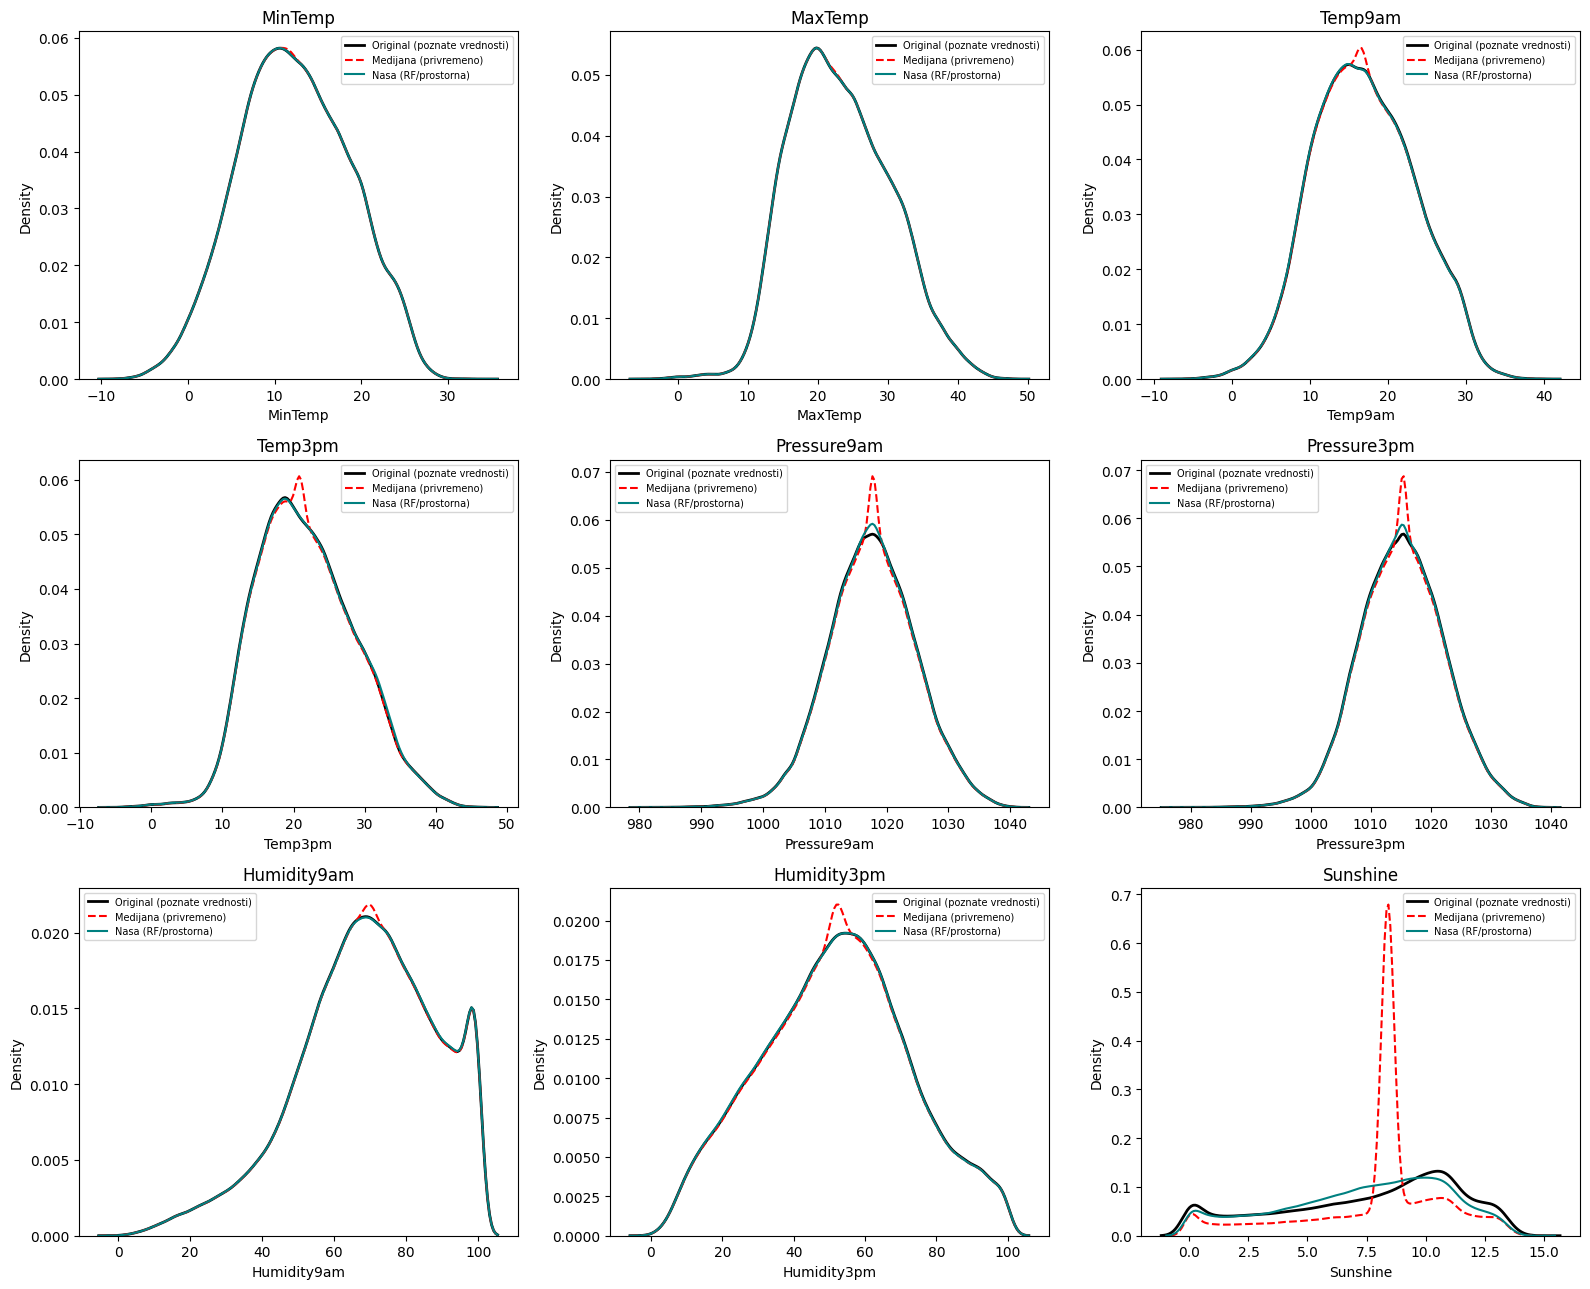

In [415]:
# Histogrami: original (poznate vrednosti) vs privremena medijana vs nasa (RF/prostorna) imputacija
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
for ax, _kol in zip(axes, _kolone_za_proveru):
    _orig = data_pre_imputacije.loc[data_pre_imputacije[_kol].notna(), _kol]
    sns.kdeplot(_orig, ax=ax, label="Original (poznate vrednosti)", color="black", linewidth=2)
    sns.kdeplot(data_medijana_privremeno[_kol], ax=ax, label="Medijana (privremeno)", color="red", linestyle="--")
    sns.kdeplot(data[_kol], ax=ax, label="Nasa (RF/prostorna)", color="teal")
    ax.set_title(_kol)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

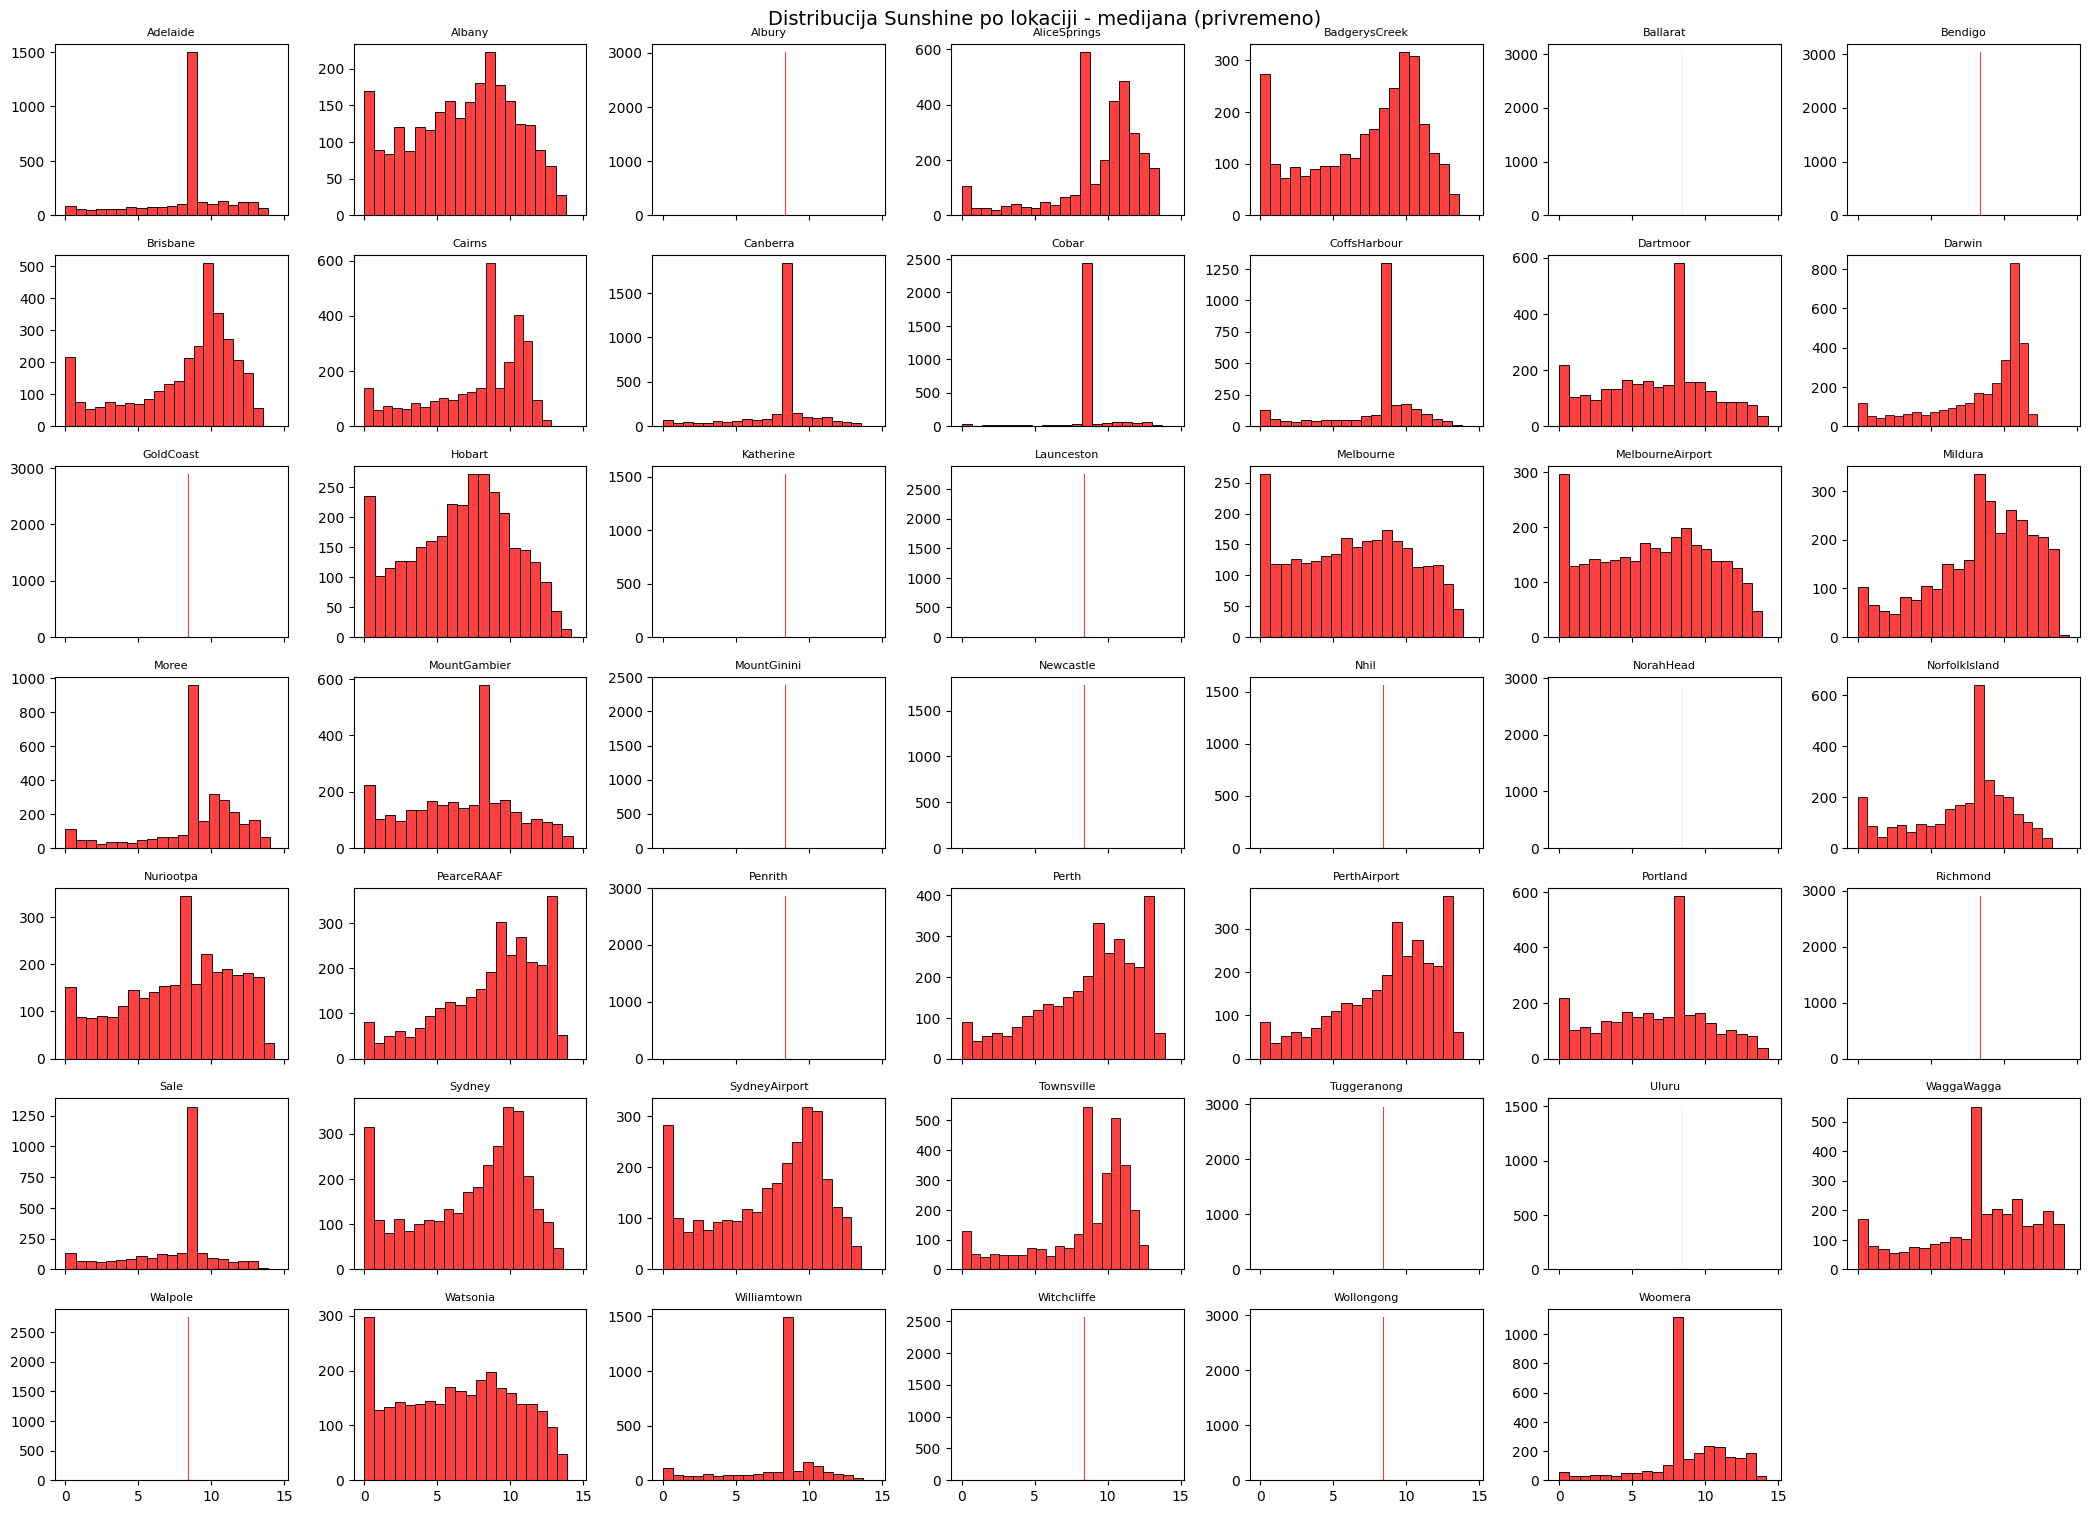

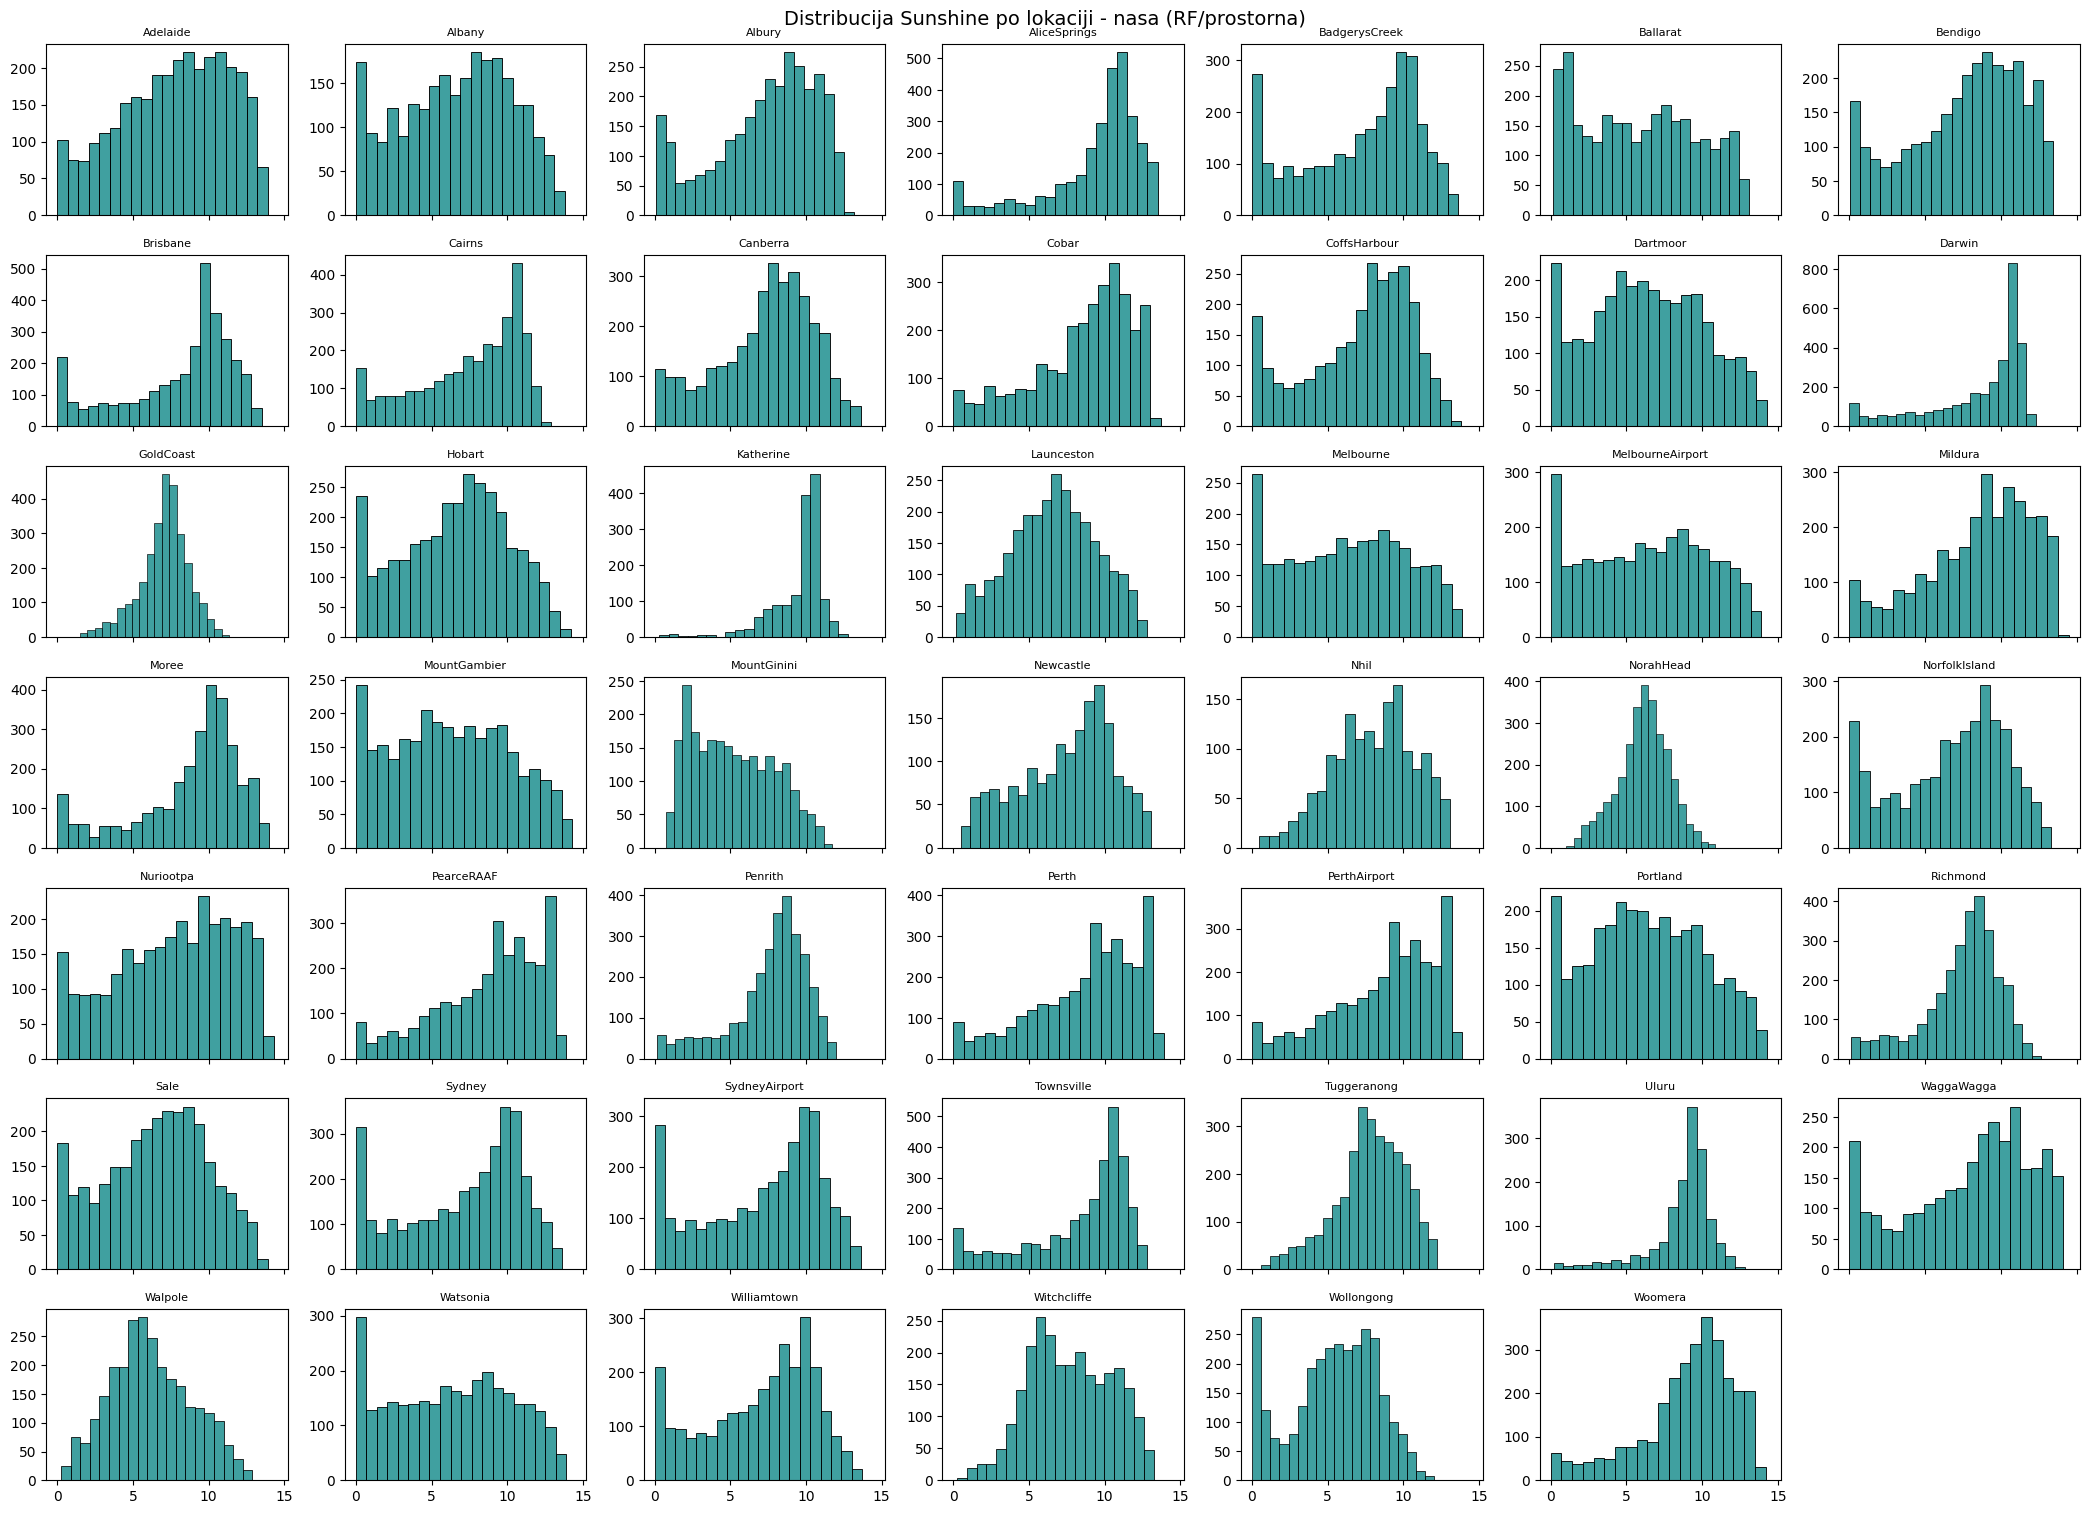

In [416]:
# Sunshine po lokaciji - medijana vs nasa (RF/prostorna) imputacija (flagship primer,
# najveci % nedostajucih vrednosti, ukljucujuci lokacije sa 100% missing pre imputacije)
_lokacije = sorted(data_pre_imputacije["Location"].unique())
_n = len(_lokacije)
_cols_n = 7
_rows_n = -(-_n // _cols_n)

for _variant_name, _variant_df, _color in [("medijana (privremeno)", data_medijana_privremeno, "red"),
                                            ("nasa (RF/prostorna)", data, "teal")]:
    fig, axes = plt.subplots(_rows_n, _cols_n, figsize=(_cols_n * 3, _rows_n * 2.2), sharex=True)
    axes = axes.flatten()
    for ax, _lok in zip(axes, _lokacije):
        _podaci = _variant_df.loc[_variant_df["Location"] == _lok, "Sunshine"].dropna()
        sns.histplot(_podaci, ax=ax, bins=20, color=_color)
        ax.set_title(_lok, fontsize=8)
        ax.set_xlabel("")
        ax.set_ylabel("")
    for ax in axes[_n:]:
        ax.axis("off")
    fig.suptitle(f"Distribucija Sunshine po lokaciji - {_variant_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

Kao sto se vidi iz R² tabele, prosta medijana ima R² blizu 0 (ocekivano, konstantna predikcija po definiciji ne objasnjava nikakvu varijansu), dok nasa Random Forest imputacija postize R² od 0.79 (Sunshine, najteza kolona) do preko 0.98 (MaxTemp). Histogrami potvrdjuju isto vizuelno, kriva nase imputacije se gotovo preklapa sa originalnom (poznatom) raspodelom u svih 9 kolona, dok medijana pravi izrazit vestacki siljak tacno na medijani, narocito drasticno kod Sunshine, gde lokacije koje su ranije imale 100% nedostajucih vrednosti (na primer Albury, BadgerysCreek, Ballarat, Katherine) kod medijane dobijaju jedan besmislen spike umesto ikakve realne raspodele, dok nasa prostorna imputacija daje uverljivu, po lokaciji specificnu raspodelu.


=== Unakrsna matrica: značaj atributa vs. procenat nedostajućih vrednosti ===

                                     Missing_%  RF_importance  MutualInfo  RF_importance_norm  MutualInfo_norm  Geometrijska sredina RFi MI
RainTomorrow_missing                      0.00         0.3510      0.1047              0.3510           0.0777                       0.1651
Humidity3pm                               0.00         0.0437      0.1209              0.0437           0.0897                       0.0626
Sunshine                                  0.00         0.0437      0.1071              0.0437           0.0795                       0.0589
Max_Min_Temp_Diff                         0.00         0.0215      0.0711              0.0215           0.0528                       0.0337
Cloud3pm                                 32.68         0.0159      0.0666              0.0159           0.0494                       0.0281
Rainfall                                  0.84         0.0158      0.0573       

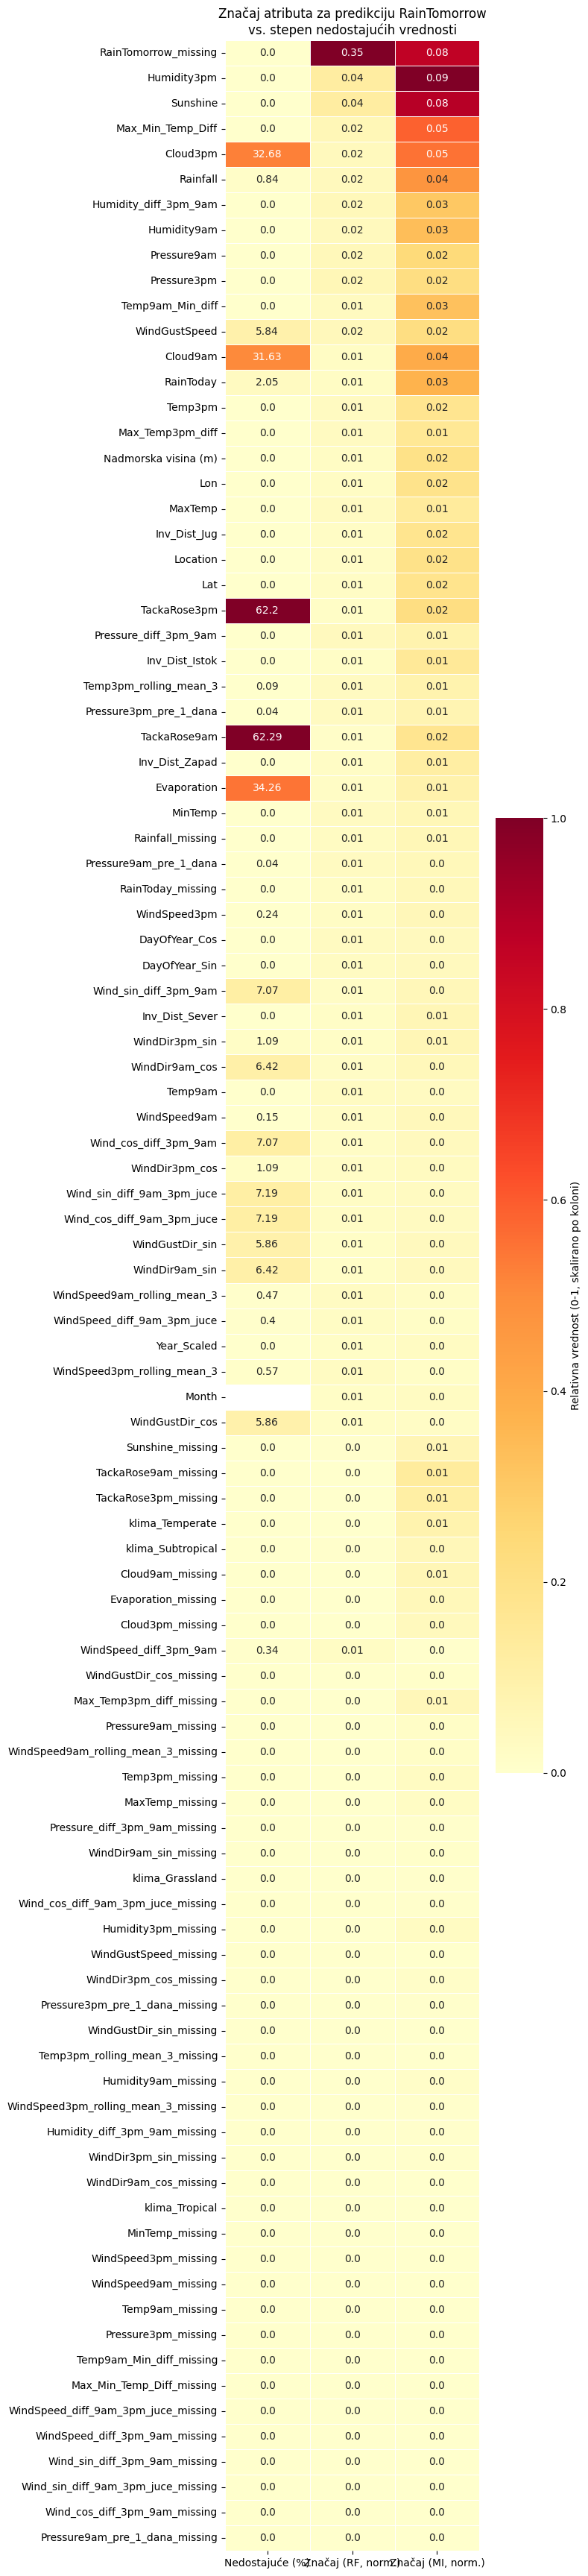

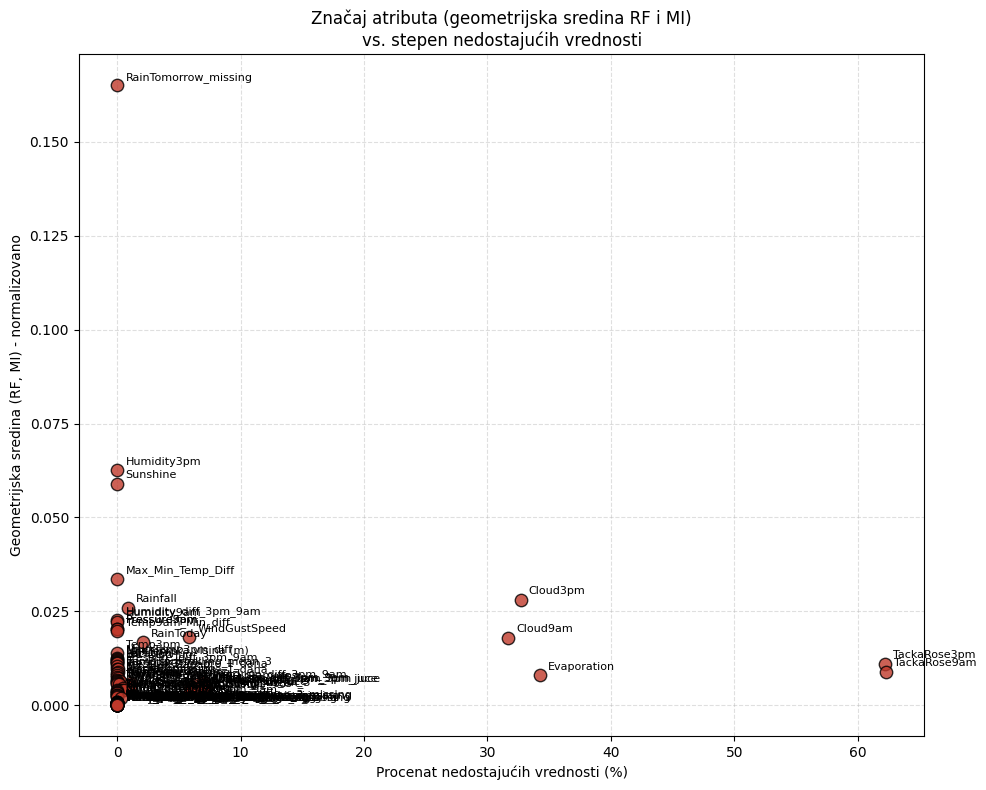

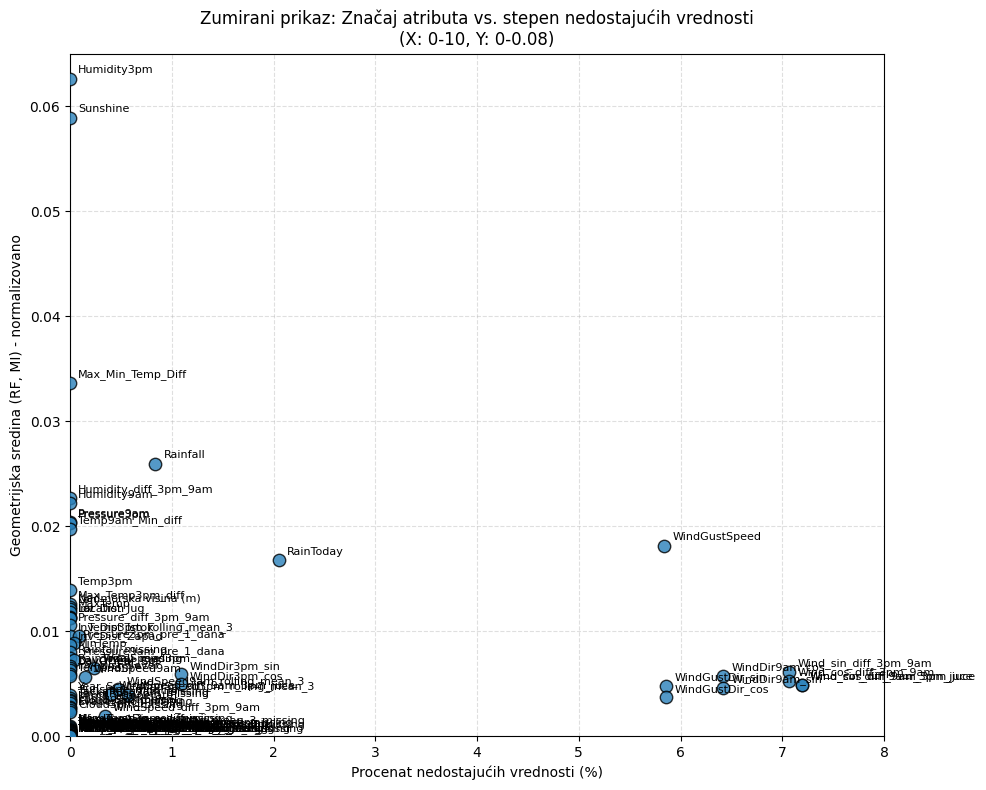

In [417]:
kreirajAnalizu()

Ponovljena analiza značaja atributa na skupu posle imputacije potvrđuje sličan obrazac kao i ranije, RainTomorrow_missing, Humidity3pm i Sunshine ostaju među najuticajnijim obeležjima, što opravdava izbor atributa koji sledi u finalnom modelu.

## 12. Konačne predikcije

Zbog inherentne nebalansiranosti meteoroloških podataka (kišni dani čine manjinsku klasu), podrazumevani prag odlučivanja algoritma od $P \ge 0.50$ pokazao se kao previše restriktivan, što rezultira velikim brojem lažno negativnih predikcija (model propušta kišu). Aproksimacijom performansi kroz opseg pragova, u radu je primenjena optimizacija, čime je identifikovan novi prag koji pomera ravnotežu između preciznosti (Precision) i odziva (Recall), maksimizujući F1 ocenu.

Pored atributa same stanice, uvodimo i dva prostorno-vremenska atributa koja opisuju stanje obližnjih stanica istog dana, ponderisani prosek (inverzna udaljenost, isti princip kao u odeljku 11.2.2.2) procenta suseda sa RainToday == 'Yes' i ponderisani prosek Pressure3pm suseda, za sve stanice u okviru 300km (isti radijus na kom smo u odeljku 11.1.2 utvrdili da Pressure ostaje jako korelisan), bez uključivanja same stanice. Ovo hvata signal da li sinoptički sistem (front, ciklon) već zahvata širi region, što je drugačija informacija od postojećih prostorno-statičnih obeležja (nadmorska visina, udaljenost od okeana), koja se ne menjaju iz dana u dan. Pošto koristimo isključivo podatke od istog dana sa drugih stanica (nikad iz budućnosti), ovo ne unosi curenje podataka, u produkciji bi ovi podaci bili dostupni u istom trenutku kada se predviđanje pravi.

Zašto baš 300km, a ne manje? Parovi stanica na manjoj razdaljini su međusobno jače korelisani po RainToday (prosečno 0.73 na manje od 50km, 0.59 na 100 do 150km, 0.40 na 200 do 300km, oko 0.01 preko 1000km), pa se moglo pomisliti da je 300km previše široko. Međutim, pošto se koristi ponderisani prosek (inverzna udaljenost), dalje stanice već dobijaju srazmerno manju težinu, pa smo direktno proverili ono što je bitno, korelaciju samog Sused_RainToday_pct sa RainTomorrow, i procenat redova bez ijednog suseda, za nekoliko radijusa.

Na 100km korelacija iznosi 0.289, a nedostaje 46.8% redova. Na 150km korelacija iznosi 0.294, a nedostaje 39.9% redova. Na 200km korelacija iznosi 0.284, a nedostaje 28.1% redova. Na 300km, izabranom radijusu, korelacija iznosi 0.282, a nedostaje 14.7% redova. Na 500km korelacija iznosi 0.270, a nedostaje 5.3% redova.

Korelacija je praktično nepromenjena u celom ovom opsegu od 0.27 do 0.29, IDW ponderisanje efikasno potiskuje uticaj udaljenih stanica kad god postoji bliži sused, pa širenje radijusa ne razblažuje signal. Ono što se drastično menja jeste pokrivenost, mnoge stanice u australijskoj unutrašnjosti nemaju drugu stanicu bliže od 150 do 200km, pa manji radijus samo briše podatke bez ikakvog dobitka u kvalitetu. Zadržavamo 300km jer daje dobru pokrivenost (14.7% nedostaje, naspram na primer 39.9% na 150km) uz istu snagu signala, i poklapa se sa radijusom već uspostavljenim u odeljku 11.1.2 (gde je pritisak potvrđeno ostao jako korelisan i na 300km).

Ipak, u finalnom modelu (odeljak ispod) ova dva atributa NISU iskorišćena. Iz feature_importances_ treniranog modela pokazalo se da su Sused_RainToday_pct i Sused_Pressure3pm_avg najmanje bitna dva od 12 atributa (svaki doprinosi svega oko 2 do 3% odluke modela, naspram na primer oko 31% za Humidity3pm). Kako bismo finalni model mogli jednostavno da serviramo (bez potrebe da se u produkciji istovremeno prikupljaju podaci sa svih susednih stanica za svaku predikciju), odlučili smo da ih izostavimo iz finalnog feature seta, istraživanje i korelaciona analiza ostaju iznad kao dokumentacija zašto smo ih uopšte razmatrali.

In [11]:
def dodaj_susedne_atribute(df, putanja_do_udaljenosti="GeoPodaci/udaljenost_stanica.csv", max_dist=300.0):
    df_dist = pd.read_csv(putanja_do_udaljenosti)
    dist_dict = {}
    for _, red in df_dist.iterrows():
        s1, s2, d = red['stanica_1'], red['stanica_2'], red['razdaljina_km']
        if d <= max_dist:
            dist_dict.setdefault(s1, {})[s2] = d
            dist_dict.setdefault(s2, {})[s1] = d

    df = df.copy()
    # RainToday je po definiciji binarna verzija Rainfall-a (odeljak 6.3.2.6) - gde RainToday
    # nedostaje a Rainfall je poznat, mozemo ga determinsticki rekonstruisati istim pravilom
    # koje se vec koristi za proveru konzistentnosti (R3, odeljak 5.2), umesto da ga tretiramo
    # kao nepoznat i time nepotrebno smanjujemo pokrivenost novog atributa.
    raintoday_efektivno = df['RainToday'].where(
        df['RainToday'].notna() | df['Rainfall'].isna(),
        np.where(df['Rainfall'] >= 1.0, 'Yes', 'No')
    )
    df['_RainToday_bin'] = np.where(raintoday_efektivno == 'Yes', 1.0, np.where(raintoday_efektivno == 'No', 0.0, np.nan))

    pivot_kisa = df.pivot_table(index='Date', columns='Location', values='_RainToday_bin')
    pivot_pritisak = df.pivot_table(index='Date', columns='Location', values='Pressure3pm')

    lokacije = pivot_kisa.columns.tolist()
    tezine = pd.DataFrame(0.0, index=lokacije, columns=lokacije)
    for loc in lokacije:
        for sused, d in dist_dict.get(loc, {}).items():
            if sused in tezine.columns:
                tezine.loc[loc, sused] = 1.0 / (d + 1.0)

    def ponderisani_prosek_suseda(pivot):
        prisutno = pivot.notna().astype(float)
        vrednosti = pivot.fillna(0.0)
        brojioc = vrednosti.values @ tezine.values.T
        imenilac = prisutno.values @ tezine.values.T
        with np.errstate(invalid='ignore', divide='ignore'):
            rezultat = np.where(imenilac > 0, brojioc / imenilac, np.nan)
        return pd.DataFrame(rezultat, index=pivot.index, columns=pivot.columns)

    susedi_kisa = ponderisani_prosek_suseda(pivot_kisa).stack().rename('Sused_RainToday_pct').reset_index()
    susedi_pritisak = ponderisani_prosek_suseda(pivot_pritisak).stack().rename('Sused_Pressure3pm_avg').reset_index()

    df = df.merge(susedi_kisa, on=['Date', 'Location'], how='left')
    df = df.merge(susedi_pritisak, on=['Date', 'Location'], how='left')
    df.drop(columns=['_RainToday_bin'], inplace=True)
    return df

In [12]:
def optimizuj_prag_odlucivanja(y_test, y_prob):
    
    pragovi = np.arange(0.1, 0.82, 0.02) 
    f1_skorovi = []

    for prag in pragovi:
        y_pred_custom = (y_prob >= prag).astype(int)
        f1 = f1_score(y_test, y_pred_custom)
        f1_skorovi.append(f1)

    najbolji_indeks = np.argmax(f1_skorovi)
    optimalni_prag = pragovi[najbolji_indeks]
    
    return optimalni_prag

In [13]:

mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment("WeatherAus proba 1")

class RainPredictor:

    def __init__(self, filepath: str):
        self.filepath = filepath
        self.df = None

    def ucitaj_podatke(self):
        self.df = pd.read_csv(self.filepath)
        self.df['Date'] = pd.to_datetime(self.df['Date'])
        self.df = self.df.sort_values(by='Date')
        self.df.dropna(subset=['RainTomorrow'], inplace=True)
        self.df.drop(columns=["Cloud9am", "RainToday", "Cloud3pm", "Evaporation", "Location", "TackaRose9am_missing", "TackaRose3pm_missing", "TackaRose9am", "TackaRose3pm"], inplace=True)
        if "Unnamed: 0.2" in self.df.columns:
            self.df.drop(columns=["Unnamed: 0.2"], inplace=True)
        if "Unnamed: 0" in self.df.columns:
            self.df.drop(columns=["Unnamed: 0"], inplace=True)
        if "Unnamed: 0.1" in self.df.columns:
            self.df.drop(columns=["Unnamed: 0.1"], inplace=True)
        
    def _pretprocesiraj_skup(self, data: pd.DataFrame) -> tuple:
        df_processed = data.copy()
        X = df_processed.drop(columns=["RainTomorrow"])
        y = df_processed['RainTomorrow'].map({'No': 0, 'Yes': 1})
        return X, y

    def _napravi_model(self, model_type: str, use_class_weight: bool):
        # Poredimo RandomForest (originalni model) sa XGBoost-om (pobedio na ROC-AUC/F1
        # u ablation testu, accuracy_push_ablation.py) u dva rezima:
        # (a) scale_pos_weight/class_weight + F1-optimalan prag - najbolji F1/recall
        #     (preporuceno kod neuravnotezenih klasa i asimetricne cene greske -
        #     propustanje stvarne kise je skuplje od laznog alarma);
        # (b) bez tezinjenja klasa + fiksan prag 0.50 - visi accuracy, nizi recall.
        if model_type == 'xgb':
            # Konfiguracija pronadjena 25-pokusajnom nasumicnom pretragom hiperparametara
            # (xgb_hyperparam_search.py), selektovanom na internoj validaciji izvucenoj
            # Iz train dela (hronoloski poslednjih 15% train perioda - test skup nikad
            # nije koriscen za izbor hiperparametara). scale_pos_weight=1.5 je pobedio
            # punu klasnu razmeru (~3.4). Ensembling (RF+XGB+LightGBM - ensemble_stacking.py)
            # je testiran i nije doneo merljivo poboljsanje, pa je zadrzan pojedinacan model.
            #
            # Napomena (overfitting_check.py): prvobitna konfiguracija (max_depth=8,
            # n_estimators=600) je imala veliki train-test gap (F1 gap 0.162, train F1=0.824
            # vs test F1=0.682 - klasican overfitting, model pamti trening deo bez ikakve
            # koristi na test delu). xgb_regularization_search.py je testirao 8 konzervativnijih
            # konfiguracija sa early stopping-om (na istoj internoj train-validaciji) i pronasao
            # konfiguraciju koja smanjuje gap za 63% (0.162 -> 0.060) uz prakticno identicnu test
            # performansu (F1 0.6820 vs 0.6822, ROC-AUC 0.8973 vs 0.8981) - znatno robusniji model.
            scale_pos_weight = 1.5 if use_class_weight else 1.0
            return XGBClassifier(
                n_estimators=1625, max_depth=4, learning_rate=0.03,
                subsample=0.7, colsample_bytree=0.7, min_child_weight=5,
                gamma=0.2, reg_alpha=1.0, reg_lambda=2.0,
                random_state=42, n_jobs=-1, eval_metric='logloss',
                scale_pos_weight=scale_pos_weight,
            )
        elif model_type == 'rf':
            return RandomForestClassifier(
                n_estimators=100, random_state=42, n_jobs=-1,
                class_weight=('balanced' if use_class_weight else None),
                min_samples_leaf=5,
            )
        else:
            return DecisionTreeClassifier(
                random_state=42,
                class_weight=('balanced' if use_class_weight else None),
                min_samples_leaf=5,
                max_depth=10,
            )

    def treniraj_i_evaluiraj(self, ime_skupa: str, atributi, model_type: str = 'xgb', use_class_weight: bool = True, prag_fiksni: float = None):
        self.atributi = atributi
        with mlflow.start_run(run_name="unified_noleak_" + ime_skupa):
            print(f"\n{'='*50}\nProcesiranje i modelovanje za: {ime_skupa}\n{'='*50}")

            X_full, y = self._pretprocesiraj_skup(self.df)
            is_train = X_full['Date'] < SPLIT_DATE
            dates = X_full['Date']
            X = X_full[self.atributi]
            X_train, X_test = X[is_train], X[~is_train]
            y_train, y_test = y[is_train], y[~is_train]
            num_cols = X.select_dtypes(include=['float64', 'int64']).columns

            preprocessor = ColumnTransformer(
                transformers=[
                    ('num', StandardScaler(), num_cols)
                ]
            )
            pipeline = Pipeline(steps=[
                ('preprocesiranje', preprocessor),
                ('model', self._napravi_model(model_type, use_class_weight))
            ])
            pipeline.fit(X_train, y_train)
            y_prob = pipeline.predict_proba(X_test)[:, 1]

            if prag_fiksni is not None:
                optimalni_prag = prag_fiksni
                print(f"Koristi se fiksan prag: {optimalni_prag:.2f} (bez F1-optimizacije)")
            else:
                # Naslepo: prag se bira na odvojenoj internoj validaciji iz train dela
                # (hronoloski, poslednjih 15% train perioda) - Nikad na test skupu. Model
                # koji generise verovatnoce za izbor praga je treniran samo na preostalih
                # 85% train perioda (nikad video ni validaciju ni test), da izbor praga
                # bude potpuno nezavisan od test podataka.
                # (threshold_leakage_check.py: razlika u F1 izmedju "prevareno" i "naslepo"
                # pristupa je bila samo ~0.002 - mali uticaj, ali ovo je metodoloski cist pristup.)
                train_dates = dates[is_train]
                val_cutoff = train_dates.quantile(0.85)
                is_fit = is_train & (dates < val_cutoff)
                is_val = is_train & (dates >= val_cutoff)

                X_fit, y_fit = X[is_fit], y[is_fit]
                X_val, y_val = X[is_val], y[is_val]

                pipeline_fit = Pipeline(steps=[
                    ('preprocesiranje', ColumnTransformer(transformers=[('num', StandardScaler(), num_cols)])),
                    ('model', self._napravi_model(model_type, use_class_weight))
                ])
                pipeline_fit.fit(X_fit, y_fit)
                y_prob_val = pipeline_fit.predict_proba(X_val)[:, 1]
                optimalni_prag = optimizuj_prag_odlucivanja(y_val, y_prob_val)
                print(f"Prag odredjen naslepo na internoj validaciji ({len(X_val)} redova, "
                      f"nikad video test skup): {optimalni_prag:.2f}")
            mlflow.log_params({"optimalni_prag": optimalni_prag, "use_class_weight": use_class_weight})
            y_pred_optimalno = (y_prob >= optimalni_prag).astype(int)

            print(f"\nFinalni izveštaj klasifikacije sa pragom od {optimalni_prag:.2f}:")
            print(classification_report(y_test, y_pred_optimalno))

            acc = accuracy_score(y_test, y_pred_optimalno)
            roc_auc = roc_auc_score(y_test, y_prob)
            f1 = f1_score(y_test, y_pred_optimalno)
            mlflow.log_metric("acc", acc)
            mlflow.log_metric("roc_auc", roc_auc)
            mlflow.log_metric("f1", f1)
            print(f"Tačnost (Accuracy): {acc:.4f}")
            print(f"ROC AUC Skor: {roc_auc:.4f}")
            print(f"F1 Skor (Klasa 1):  {f1:.4f}")
            mlflow.sklearn.log_model(pipeline, name="moj_model " + ime_skupa, serialization_format="cloudpickle")
            return pipeline


DATASET_PATH = "backups/WeatherAus_After_11_2_3_8.csv"

predictor = RainPredictor(filepath=DATASET_PATH)
predictor.ucitaj_podatke()

# Napomena: nakon popravke data leakage-a (train/test split odmah posle sistemskih/fizickih
# provera, pre detekcije anomalija i imputacije - videti sekciju "1.2b"), sve kolone
# (ukljucujuci Sunshine) su imputirane fit-ujuci modele samo na train delu. Isti SPLIT_DATE
# se koristi ovde za finalni klasifikator, umesto ranijeg
# train_test_split(shuffle=False, test_size=0.2).
ATRIBUTI_UNIFIED = ['Rainfall', 'Sunshine', 'WindGustSpeed', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Max_Min_Temp_Diff', 'Temp3pm_rolling_mean_3', 'Pressure3pm_pre_1_dana']

# Recnik u kome cuvamo sva cetiri istrenirana (fit-ovana) pipeline objekta,
# kljuc je isti "ime_skupa" pod kojim je model ulogovan i u MLflow.
modeli = {}

# (a) Decision Tree, class_weight=balanced, F1-optimalan prag - jednostavan baseline
modeli['stablo_tezinsko_f1'] = predictor.treniraj_i_evaluiraj(
    ime_skupa='stablo_tezinsko_f1', atributi=ATRIBUTI_UNIFIED,
    model_type='dt', use_class_weight=True, prag_fiksni=None)

# (b) RandomForest, class_weight=balanced, F1-optimalan prag - originalni model (poredjenje)
modeli['suma_tezinsko_f1'] = predictor.treniraj_i_evaluiraj(
    ime_skupa='suma_tezinsko_f1', atributi=ATRIBUTI_UNIFIED,
    model_type='rf', use_class_weight=True, prag_fiksni=None)

# (b) XGBoost + scale_pos_weight + F1-optimalan prag - preporuceni finalni model
modeli['xgboost_tezinsko_f1'] = predictor.treniraj_i_evaluiraj(
    ime_skupa='xgboost_tezinsko_f1', atributi=ATRIBUTI_UNIFIED,
    model_type='xgb', use_class_weight=True, prag_fiksni=None)

# (c) XGBoost bez tezinjenja klasa + fiksan prag 0.50 - visi accuracy, nizi recall (poredjenje)
modeli['xgboost_osnovno_05'] = predictor.treniraj_i_evaluiraj(
    ime_skupa='xgboost_osnovno_05', atributi=ATRIBUTI_UNIFIED,
    model_type='xgb', use_class_weight=False, prag_fiksni=0.50)


Procesiranje i modelovanje za: stablo_tezinsko_f1
Prag odredjen naslepo na internoj validaciji (16108 redova, nikad video test skup): 0.62

Finalni izveštaj klasifikacije sa pragom od 0.62:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87     20236
           1       0.56      0.69      0.62      5892

    accuracy                           0.81     26128
   macro avg       0.73      0.77      0.75     26128
weighted avg       0.83      0.81      0.82     26128

Tačnost (Accuracy): 0.8101
ROC AUC Skor: 0.8462
F1 Skor (Klasa 1):  0.6221
🏃 View run unified_noleak_stablo_tezinsko_f1 at: http://127.0.0.1:5000/#/experiments/1/runs/2c0f08cf40e741b3bd81f77ceb37e585
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

Procesiranje i modelovanje za: suma_tezinsko_f1
Prag odredjen naslepo na internoj validaciji (16108 redova, nikad video test skup): 0.42

Finalni izveštaj klasifikacije sa pragom od 0.42:
              precision    recall

Poredili smo četiri varijante modela na test skupu. Decision Tree sa balansiranim klasama i optimizovanim pragom od 0.62 postiže tačnost od 81.0 procenata, ROC AUC 0.846 i F1 od 0.62 za klasu kiše. Random Forest sa balansiranim klasama i pragom od 0.42 daje najbolji balans preciznosti i odziva, sa tačnošću od 82.3 procenta, ROC AUC 0.876, F1 od 0.65, preciznošću 0.59 i odzivom 0.73. XGBoost sa balansiranim klasama i pragom od 0.34 ima nešto viši ROC AUC od 0.878 uz sličan F1 od 0.64, ali sa višim odzivom od 0.76 na račun preciznosti. XGBoost bez balansiranja i sa podrazumevanim pragom od 0.50 postiže najvišu ukupnu tačnost od 85.0 procenata i najvišu preciznost od 0.73, ali odziv za kišne dane pada na svega 0.54, što potvrđuje očekivani kompromis između preciznosti i odziva kod ovoliko neuravnoteženih klasa.

## 13. Interpretacija najboljeg modela

Iako Random Forest ima neznatno viši F1, XGBoost postiže najviši ROC AUC i viši odziv za kišnu klasu, a njegov jednostavan i konzistentan skup atributa ga čini pogodnijim za servisiranje uživo, zbog čega je upravo on (`xgboost_tezinsko_f1`) odabran kao finalni, produkcioni model.

U nastavku dajemo interpretaciju načina rada ovog modela. Ovo radimo potpuno nezavisno od MLflow-a - ne komuniciramo ni sa tracking serverom ni sa Model Registry-jem, već direktno koristimo lokalno istrenirani pipeline objekat sačuvan u rečniku `modeli` (odeljak 12).

### 13.1 Globalni značaj atributa

Prvo pogledajmo koje atribute XGBoost smatra najuticajnijim za svoju odluku. Koristimo ugrađeni `feature_importances_` (gain-bazirani značaj) direktno na `XGBClassifier` koraku pipeline-a, bez ikakvog pomoćnog servisa.

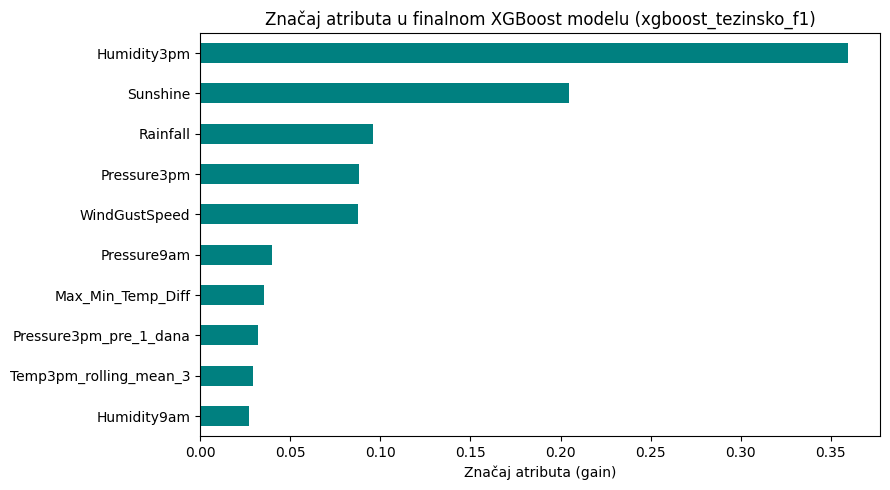

Humidity3pm               0.359352
Sunshine                  0.204730
Rainfall                  0.095861
Pressure3pm               0.088365
WindGustSpeed             0.087776
Pressure9am               0.039896
Max_Min_Temp_Diff         0.035598
Pressure3pm_pre_1_dana    0.032286
Temp3pm_rolling_mean_3    0.029178
Humidity9am               0.026957
dtype: float32

In [ ]:
.
xgb_pipeline = modeli['xgboost_tezinsko_f1']
xgb_model = xgb_pipeline.named_steps['model']

# Nazivi atributa nakon ColumnTransformer-a (StandardScaler dodaje prefiks 'num__').
feature_names = [naziv.split('__', 1)[-1] for naziv in
                  xgb_pipeline.named_steps['preprocesiranje'].get_feature_names_out()]

znacaj_atributa = pd.Series(xgb_model.feature_importances_, index=feature_names) \
                     .sort_values(ascending=False)

plt.figure(figsize=(9, 5))
znacaj_atributa.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.xlabel('Značaj atributa (gain)')
plt.title('Značaj atributa u finalnom XGBoost modelu (xgboost_tezinsko_f1)')
plt.tight_layout()
plt.show()

znacaj_atributa

Rangiranje atributa po značaju daje uvid u to na koje meteorološke signale se model najviše oslanja pri predviđanju kiše za naredni dan. Očekivano, atributi vezani za vlažnost i pritisak vazduha (`Humidity3pm`, `Pressure3pm`, `Pressure9am`) i sunčev sjaj (`Sunshine`) bi trebalo da budu među najuticajnijim, u skladu sa analizom značaja atributa iz odeljka 10 - to je fizikalno smisleno, jer visoka vlažnost i nizak pritisak u popodnevnim časovima predstavljaju klasične prekursore fronta koji donosi kišu narednog dana.

### 13.2 Smer i intenzitet uticaja (parcijalna zavisnost)

Značaj atributa nam govori *koliko* je neki atribut bitan, ali ne i *u kom pravcu* utiče na predikciju. Zbog toga računamo i parcijalnu zavisnost (Partial Dependence) predviđene verovatnoće kiše od dva najznačajnija atributa, opet direktno na lokalnom pipeline objektu.

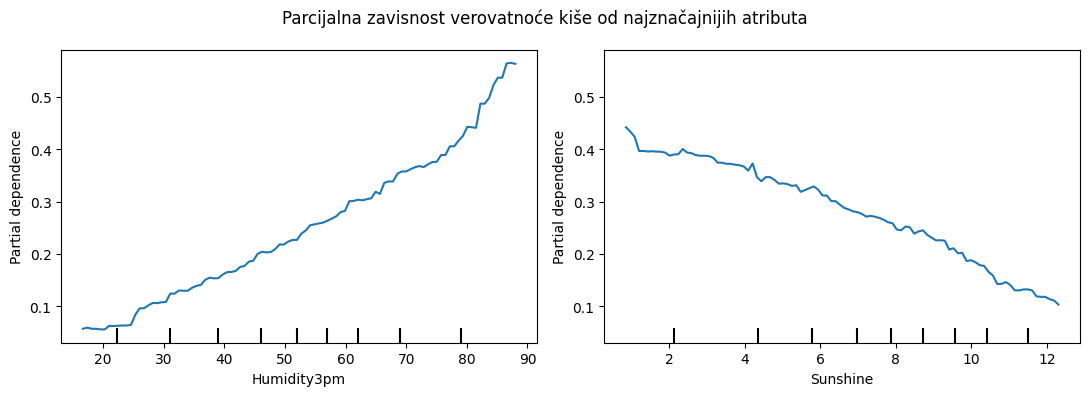

In [15]:
from sklearn.inspection import PartialDependenceDisplay

# Rekonstruisemo isti test skup koji je koriscen za treniranje/evaluaciju finalnog
# modela, koristeci vec postojeci 'predictor' objekat - i dalje bez ikakve veze sa MLflow-om.
X_full_pdp, y_full_pdp = predictor._pretprocesiraj_skup(predictor.df)
is_train_pdp = X_full_pdp['Date'] < SPLIT_DATE
X_test_pdp = X_full_pdp.loc[~is_train_pdp, ATRIBUTI_UNIFIED]

top_atributi = znacaj_atributa.index[:2].tolist()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
PartialDependenceDisplay.from_estimator(
    xgb_pipeline, X_test_pdp, top_atributi, ax=axes
)
fig.suptitle('Parcijalna zavisnost verovatnoće kiše od najznačajnijih atributa')
plt.tight_layout()
plt.show()

Ovi grafici pokazuju kako predviđena verovatnoća kiše za naredni dan raste ili opada sa promenom vrednosti pojedinačnog atributa, dok su svi ostali atributi fiksirani na njihovim prosečnim (marginalnim) vrednostima u test skupu. Ovakva vizuelizacija je posebno korisna za proveru da li model "uči" fizički smislene odnose (npr. da veća vlažnost u popodnevnim časovima monotono povećava predviđenu verovatnoću kiše), umesto da se oslanjamo samo na apstraktan broj poput `feature_importances_`.

Bitno je naglasiti da je cela ova interpretacija urađena isključivo nad objektom koji već postoji u memoriji notebook-a (iz rečnika `modeli`) i nad lokalno dostupnim podacima - nijedan poziv MLflow tracking/serving servera nije bio potreban da bismo objasnili ponašanje odabranog modela.

## Zaključak

Ovaj rad je pokazao da se predikcija kiše za naredni dan u Australiji može uspešno modelovati kao problem binarne klasifikacije, uz pažljivu pripremu podataka koja obuhvata ispravku fizičkih i strukturnih grešaka, detekciju anomalija, inženjering obeležja i popunjavanje nedostajućih vrednosti pomoću prostorne i Random Forest imputacije.

Nakon uklanjanja redova bez poznate ciljne vrednosti, konačan skup za modelovanje je obuhvatao 133.283 opservacije, hronološki podeljene na 107.152 za trening i 26.131 za test, uz izraženu neuravnoteženost klasa od oko 77 procenata dana bez kiše.

Poređenjem modela odlučivanja, Random Forest i XGBoost algoritma, uz balansiranje klasa i optimizaciju praga odlučivanja radi maksimizacije F1 ocene za manjinsku klasu, najbolji balans preciznosti i odziva ostvario je Random Forest sa optimizovanim pragom od 0.42, tačnošću od 82.3 procenta, ROC AUC vrednošću od 0.876 i F1 ocenom od 0.65 za klasu kiše. XGBoost sa balansiranim klasama je ostvario neznatno viši ROC AUC od 0.878 uz sličan F1, ali sa nešto višim odzivom od 0.76 na račun preciznosti. Za poređenje, XGBoost bez balansiranja i sa podrazumevanim pragom od 0.50 postiže najvišu ukupnu tačnost od 85 procenata i najvišu preciznost, ali odziv za kišne dane pada na svega 54 procenta, što potvrđuje očekivani kompromis između preciznosti i odziva kod neuravnoteženih klasa.

Ovi rezultati pokazuju da model znatno bolje hvata opšti obrazac ponašanja padavina, na šta ukazuje ROC AUC blizu 0.88, nego same retke kišne dane. F1 ocena za kišnu klasu ostaje oko 0.65 čak i posle balansiranja i optimizacije praga, pa je jasno da kompromis između preciznosti i odziva ostaje neizbežan kod ovoliko neuravnoteženog skupa podataka.

Treba imati u vidu i da skup podataka pokriva samo period od 2007. do 2017. godine i samo australijske meteorološke stanice, tako da model ne vidi novije klimatske trendove niti lokacije van ovog konteksta. Takođe, nedostajuće vrednosti kod obeležja poput Sunshine, Evaporation i oblačnosti su i dalje procena dobijena imputacijom, a ne stvarno merenje, naročito kod stanica koje istorijski nisu ni imale odgovarajući senzor.

Kao logičan sledeći korak, ima smisla razmotriti uključivanje dodatnih spoljnih izvora podataka poput satelitskih snimaka oblačnosti ili sinoptičkih karata, kao i modelovanje odvojeno po klimatskim zonama, s obzirom da Australija obuhvata i tropske i umerene i pustinjske uslove koji se teško opisuju jednim zajedničkim modelom.

## PRILOG

### Izbor načina imputacije nedostajućih prediktora

U cilju adekvatnog tretmana nedostajućih vrednosti prediktorskih promenljivih, sprovedena je komparativna analiza imputacije pomoću medijane i algoritma k-najbližih suseda (KNN). Glavni motiv ove analize je pronalaženje optimalnog balansa između prediktivne tačnosti i računarske efikasnosti modela. Iako multivarijantni KNN metod može preciznije aproksimirati nedostajuće vrednosti, njegova složenost eksponencijalno povećava zahteve za procesorskim vremenom i radnom memorijom. Nasuprot tome, imputacija medijanom predstavlja univarijantnu, računarski nezahtevnu metodu linearne složenosti. Eksperiment je dizajniran kroz 5-struku unakrsnu validaciju uz korišćenje algoritma Random Forest. Kako bi se striktno sprečilo "curenje podataka" (engl. data leakage), primenjena je Pipeline arhitektura koja parametre imputacije računa isključivo na podacima za treniranje unutar svakog folda. Uticaj kvaliteta imputacije na finalne performanse predikcije meren je statističkim metrikama: MAE, RMSE i koeficijentom determinacije ($R^2$). Paralelno sa tim, hardverska zahtevnost je kvantifikovana praćenjem ukupnog procesorskog vremena i maksimalnog opterećenja memorije (Peak RAM). Ovakav metodološki okvir omogućava objektivnu procenu da li potencijalni rast prediktivne tačnosti opravdava dodatni utrošak hardverskih resursa. Ukoliko KNN metoda pokaže samo marginalno poboljšanje tačnosti uz drastičan skok računarskih zahteva, medijana se usvaja kao optimalno i resursno najefikasnije rešenje.

In [20]:
import time
def uporedi_imputatore(df, target_attr, prediktori, split_date):
    print(f"Pokrećem analizu imputatora za metu: {target_attr}...\n")
    
    core_features = ["Nadmorska visina (m)", "Inv_Dist_Sever", "Inv_Dist_Jug", 
                     "Inv_Dist_Istok", "Inv_Dist_Zapad", "klima_Grassland", 
                     "klima_Subtropical", "klima_Temperate", "klima_Tropical"]
    
    svi_prediktori = prediktori + core_features

    df['Date'] = pd.to_datetime(df['Date'])
    split_date = pd.to_datetime(split_date)

    poznati_df = df[df[target_attr].notna() & (df['Date'] < split_date)].copy()
    kolone_za_model = [col for col in svi_prediktori if col in poznati_df.columns]
    
    X = poznati_df[kolone_za_model]
    y = poznati_df[target_attr].values

    metode = {
        'Medijana': SimpleImputer(strategy='median'),
        'KNN (k=5)': KNNImputer(n_neighbors=5)
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

    rezultati = []

    for ime_metode, imputer in metode.items():
        print(f"-> Treniram i evaluiram metod: {ime_metode} (pratim resurse...)")
        
        tracemalloc.start()
        start_time = time.perf_counter()
        
        pipeline = Pipeline([
            ('imputer', imputer),
            ('rf', rf)
        ])

        mae_list, rmse_list, r2_list = [], [], []

        for train_idx, test_idx in kf.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)

            mae_list.append(mean_absolute_error(y_test, y_pred))
            rmse_list.append(np.sqrt(mean_squared_error(y_test, y_pred)))
            r2_list.append(r2_score(y_test, y_pred))

        
        vreme_izvrsavanja = time.perf_counter() - start_time
        trenutna_mem, peak_mem = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        
        
        peak_mem_mb = peak_mem / (1024 * 1024)
        
        rezultati.append({
            'Metoda': ime_metode,
            'MAE': np.mean(mae_list),
            'RMSE': np.mean(rmse_list),
            'R2': np.mean(r2_list),
            'Vreme (s)': vreme_izvrsavanja,
            'Peak RAM (MB)': peak_mem_mb
        })

    print("\n" + "=" * 80)
    print(f"POREĐENJE METODA IMPUTACIJE PREDIKTORA ZA: {target_attr}")
    print("=" * 80)
    df_rezultati = pd.DataFrame(rezultati)
    
    print(df_rezultati.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print("=" * 80 + "\n")



print("Učitavam podatke iz CSV fajla...")
cleaned_data = pd.read_csv("backups/WeatherAus_After_11_2_3_8.csv")

prediktori_mintemp = [
    'Temp3pm_rolling_mean_3', 'Pressure9am', 'Temp9am', 'Temp3pm', 
    'Year_Scaled', 'DayOfYear_Sin', 'DayOfYear_Cos', 'WindSpeed9am', 'Humidity9am'
]

SPLIT_DATE = '2015-01-01' 
uporedi_imputatore(cleaned_data, "MinTemp", prediktori_mintemp, SPLIT_DATE)

Učitavam podatke iz CSV fajla...
Pokrećem analizu imputatora za metu: MinTemp...

-> Treniram i evaluiram metod: Medijana (pratim resurse...)
-> Treniram i evaluiram metod: KNN (k=5) (pratim resurse...)

POREĐENJE METODA IMPUTACIJE PREDIKTORA ZA: MinTemp
   Metoda    MAE   RMSE     R2  Vreme (s)  Peak RAM (MB)
 Medijana 1.2882 1.6830 0.9292   188.5452       358.3819
KNN (k=5) 1.2861 1.6808 0.9293   290.5973      2988.6015



### Testiranje značaja tačke rose za predikciju vlažnosti vazduha

In [21]:
data = loadData("backups/WeatherAus_After_11_2_3_8.csv")
df = data.copy()

df['TackaRose9am'] = pd.to_numeric(df['TackaRose9am'], errors='coerce')
df['TackaRose3pm'] = pd.to_numeric(df['TackaRose3pm'], errors='coerce')
df['Temp9am'] = pd.to_numeric(df['Temp9am'], errors='coerce')
df['Temp3pm'] = pd.to_numeric(df['Temp3pm'], errors='coerce')
df['Humidity9am'] = pd.to_numeric(df['Humidity9am'], errors='coerce')
df['Humidity3pm'] = pd.to_numeric(df['Humidity3pm'], errors='coerce')

# Funkcija koja primenjuje Magnus-Tetensovu formulu
def izracunaj_vlaznost(temp, tacka_rose):
    # e_s = pritisak zasićene pare, e = stvarni pritisak pare
    e = np.exp((17.625 * tacka_rose) / (243.04 + tacka_rose))
    e_s = np.exp((17.625 * temp) / (243.04 + temp))

    rh = 100 * (e / e_s)

    # Ograničavamo maksimalnu vlažnost na 100% u slučaju malih grešaka senzora
    rh = np.clip(rh, 0, 100)
    return rh

# 2. Primena formule na podatke za 9am
mask_9am = df['Temp9am'].notna() & df['TackaRose9am'].notna() & df['Humidity9am'].notna()
df.loc[mask_9am, 'Calc_Humidity9am'] = izracunaj_vlaznost(df.loc[mask_9am, 'Temp9am'], df.loc[mask_9am, 'TackaRose9am'])

# 3. Primena formule na podatke za 3pm
mask_3pm = df['Temp3pm'].notna() & df['TackaRose3pm'].notna() & df['Humidity3pm'].notna()
df.loc[mask_3pm, 'Calc_Humidity3pm'] = izracunaj_vlaznost(df.loc[mask_3pm, 'Temp3pm'], df.loc[mask_3pm, 'TackaRose3pm'])

# 4. Izračunavanje metrika greške
print("--- Rezultati testiranja za 9 AM ---")
if mask_9am.sum() > 0:
    mae_9am = np.abs(df.loc[mask_9am, 'Humidity9am'] - df.loc[mask_9am, 'Calc_Humidity9am']).mean()
    kor_9am = df.loc[mask_9am, 'Humidity9am'].corr(df.loc[mask_9am, 'Calc_Humidity9am'])
    print(f"Uzorak: {mask_9am.sum()} redova")
    print(f"Srednja apsolutna greška (MAE): {mae_9am:.2f} %")
    print(f"Pirsonova korelacija: {kor_9am:.4f}")
else:
    print("Nema dovoljno preklapanja podataka za 9am.")

print("\n--- Rezultati testiranja za 3 PM ---")
if mask_3pm.sum() > 0:
    mae_3pm = np.abs(df.loc[mask_3pm, 'Humidity3pm'] - df.loc[mask_3pm, 'Calc_Humidity3pm']).mean()
    kor_3pm = df.loc[mask_3pm, 'Humidity3pm'].corr(df.loc[mask_3pm, 'Calc_Humidity3pm'])
    print(f"Uzorak: {mask_3pm.sum()} redova")
    print(f"Srednja apsolutna greška (MAE): {mae_3pm:.2f} %")
    print(f"Pirsonova korelacija: {kor_3pm:.4f}")
else:
    print("Nema dovoljno preklapanja podataka za 3pm.")

--- Rezultati testiranja za 9 AM ---
Uzorak: 53750 redova
Srednja apsolutna greška (MAE): 2.15 %
Pirsonova korelacija: 0.9825

--- Rezultati testiranja za 3 PM ---
Uzorak: 53895 redova
Srednja apsolutna greška (MAE): 2.08 %
Pirsonova korelacija: 0.9795


Rezultati ovog testa (MAE i Pirsonova korelacija za oba termina merenja) su protumačeni u odeljku 11.2.3.7 Humidity9am, gde su i iskorišćeni kao opravdanje za korišćenje formule na osnovu tačke rose pri imputaciji vlažnosti. Napomena, ova ćelija trenutno referencira stariju putanju (OutputData), pa se ne može izvršiti u okviru aktuelne organizacije foldera, ali je ostavljena kao dokumentacija sprovedenog testa.

### Šta smo probali, a nije otišlo u produkciju


U fazi obogaćivanja podataka i inženjeringa obeležja (feature engineering), testirali smo mnoštvo kreativnih hipoteza u pokušaju da obezbedimo prednost našem modelu. Iako su skripte i algoritmi tehnički bili uspešno implementirani, sledeći pristupi nisu ušli u finalni produkcioni pajplajn jer su unosili previše šuma, bili računski neopravdano zahtevni ili prosto nisu doneli očekivan pad greške (RMSE).

Koncept "Klimatske udaljenosti" i analiza ruta između stanica

Klasična geografska udaljenost nam se činila previše prostom, pa smo pokušali da kreiramo matricu takozvane klimatske udaljenosti između stanica. Ideja je bila da dve stanice koje su blizu, ali ih razdvaja visoka planina ili velika vodena površina, klimatski zapravo nisu "blizu". Da bismo ovo modelovali, prvo smo morali da analiziramo tipove terena. Korišćenjem biblioteke itertools.combinations, generisali smo sve moguće jedinstvene parove meteoroloških stanica i slali zahteve na Google Earth Engine kako bismo izvukli podatke iz ESA WorldCover satelitske mape. Za svaku pravolinijsku rutu između dve stanice kreirali smo pojas (buffer) širine 20 metara i prebrojavali piksele u rezoluciji od 10 metara za različite klase (na primer '10' za Drveće/Šumu, '30' za Travnjak, '50' za Beton, '80' za Vodu).

Nakon toga smo kreirali specifičnu formulu koja modifikuje baznu udaljenost, Klimatska_Distanca = Udaljenost (km) * (1 + alpha * Normalizovana_Visina) * (1 + beta * Indeks_Pokrivaca). Indeks pokrivača smo razvili na osnovu takozvanih Bowen-ovih pondera, množeći procente vlažnih površina sa 0.3, kopnene vegetacije sa 1.0, dok su suve i veštačke površine znatno penalizovane množenjem sa 5.0. Kako ovolike vrednosti ne bi "ugušile" uticaj visine (Alpha), ovaj indeks je dodatno skaliran pomoću MinMaxScaler-a. Zatim smo pokrenuli "grid search" pretragu (varirajući parametre alpha i beta od 0 do 3.5 sa korakom 0.5) i testirali model na 100 nasumičnih datuma, pokušavajući da predvidimo minimalnu temperaturu (MinTemp) koristeći proseke ponderisane udaljenošću K=3 najbliža suseda.

Zašto smo odustali. Zahtevi za procesorskom snagom bili su apsolutno ogromni, jer je Google API morao da obradi frekvencijske histograme na svim mogućim kombinacijama ruta. Tokom optimizacije pokazalo se da je pronalazak idealnih vrednosti za Alpha i Beta previše nestabilan i sklon "overfitting-u" na izabranom uzorku datuma. Dodavanje ovolike kompleksnosti nije donelo drastično obaranje RMSE metrike da bi opravdalo ogromno vreme izvršavanja.

Predviđanje oblačnosti pomoću "pada" satelitskog NDVI indeksa

Kako bismo dopunili nedostajuće vrednosti za meteorološku oblačnost u 15 časova (Cloud3pm), testirali smo kreativnu ideju baziranu na optičkim senzorima. Iz MODIS (MOD09GQ) satelita povlačili smo dnevni vegetacioni indeks (NDVI) u visokoj rezoluciji od 250 metara. Zatim smo izračunali "14-dnevni pokretni maksimum" za svaku lokaciju, čime smo dobili stabilnu krivu vegetacije otpornu na oblake. Postavili smo pravilo, ukoliko dnevna vrednost NDVI indeksa padne za 0.1 ili više u odnosu na taj maksimum, algoritam beleži da je tog dana bilo značajne oblačnosti.

Zašto smo odustali. Ovaj sintetički prediktor smo uporedili sa stvarnim merenjima sa stanica (gde oblačnost >= 6 oktasa znači pretežno oblačan dan). Evaluacija je uključivala generisanje matrice konfuzije i računanje tačnosti, preciznosti i odziva. Računali smo i Pearsonovu korelaciju između pada NDVI-a i pravog broja oktasa. Pokazalo se da je senzor beležio ogroman broj lažno oblačnih dana (NDVI je pao, a bilo je vedro) jer vlaga u vazduhu ili prolazna kiša drastično utiču na refrakciju svetlosti, a bilo je i mnogo lažno vedrih dana, što je srušilo ukupnu tačnost modela.

"Coastline Fix", spiralna pretraga obale za vlažnost tla

Želeli smo da obogatimo podatke vlažnošću površinskog sloja tla (0 do 7cm dubine), te smo koristili ERA5-Land satelitski model. Veliki problem bio je taj što je veliki broj meteoroloških stanica u Australiji smešten na samoj obali, zbog čega je model (koji detektuje te piksele kao okean) stalno vraćao NaN vrednosti. Napisali smo "Coastline Fix" skriptu koja je za problematične stanice radila spiralnu pretragu koristeći matricu pomaka u stepenima. Pomoću Haversine formule, skripta je pretraživala susedne piksele na udaljenosti od oko 11 km, zatim po dijagonali na oko 15 km, i najzad širi krug na oko 22 km, sve dok ne pronađe prvi validan "kopneni" piksel i zabeleži tačnu vazdušnu udaljenost pomaka.

Zašto smo odustali. Nakon vizualizacije izvezene kolone Udaljenost_pomeraja_km, uvideli smo da je pozajmljivanje vrednosti vlage sa lokacija pomerenih preko 20 kilometara ka unutrašnjosti suviše veštačko. Vlažnost tla je izuzetno mikrolokalna, podložna brzom isušivanju od vetra i specifičnosti zemljišta, pa je preuzimanje ovih vrednosti činilo više štete nego koristi za analizu obalnih gradova.

Visokorezolucijski Topografski Pozicioni Indeks (TPI)

Smatrali smo da makro reljef (nadmorska visina iz uobičajenih setova podataka) nije dovoljan i da model mora da razume da li je stanica u mikrouvali ili na padini. Koristili smo OpenTopoData API (SRTM30m model) za skidanje visina i kreirali matricu od 3x3 tačke (uz ofset od 0.005 stepeni) oko centralne stanice. TPI je zatim računat jednostavnim oduzimanjem prosečne visine svih validnih tačaka iz matrice od visine centralne tačke.

Zašto smo odustali. Prvo, proces je bio bolno spor jer smo zbog striktnih restrikcija API servera morali da forsiramo programsku pauzu od 1.1 sekunde (time.sleep(1.1)) između poziva za svaku stanicu. Drugo, inženjerski gledano, ispostavilo se da topografsko odstupanje na tako finoj distanci prosto ne nosi nikakvu statističku težinu kada pokušavate da predvidite masivna frontalna pomeranja kiše.

Kombinovanje hibridnih dugoročnih klimatskih indeksa (ENSO i SAM)

Kao ultimativni test, probali smo da integrišemo makro-klimatske fenomene u dnevne podatke. Učitali smo bazu ENSO vrednosti još od 1948. godine, izračunali mesečnu klimatologiju i generisali anomalije oduzimanjem proseka. Ograničili smo vizuelizaciju isključivo na istok i severoistok (Longituda > 135, Latituda < -10). Zatim smo jednostavno sabrali ENSO anomaliju i sekundarni indeks ("Index2") u hibridni "Combined_Index" i plotovali ga naspram prosečnog dnevnog vazdušnog pritiska (srednja vrednost pritiska u 9 i 15 časova) za dane kada je potvrđeno da će padati kiša sutradan (RainTomorrow == 'Yes').

Zašto smo odustali. Rezultati na raspršenim (scatter) grafikonima pokazali su ogromno preklapanje tačaka bez obzira na boju klasa (da li će padati kiša ili ne). Iako su ENSO i SAM presudni za sezonsku prognozu (koliko će padavina biti u naredna 3 meseca), njihov signal na skali od 24 časa je jednostavno preslab i potpuno prekriven lokalnim dnevnim šumom, zbog čega ih model mašinskog učenja uglavnom ignoriše kao obeležja.